## Survey analyses

In [2]:
# Importing packages for:
# Importing and analysis
# Import requests
import pandas as pd 
import numpy as np
from collections import Counter
import re
import unicodedata
import math

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import MaxNLocator
from matplotlib.patches import Patch
from matplotlib.colors import to_hex

# Make DataFrames print fully, no scrollbars -for printscreening
from IPython.display import HTML, display


css = """
/* Classic Jupyter Notebook */
div.output_scroll {height: auto !important; overflow: visible !important;}
div.output_area {max-height: none !important;}
div.output_subarea {max-height: none !important; overflow: visible !important;}
div.text_cell_render, div.rendered_html {overflow: visible !important;}
div.output_wrapper {overflow: visible !important;}

/* JupyterLab */
.jp-OutputArea-output {max-height: none !important; overflow: visible !important;}
.jp-RenderedHTMLCommon {overflow: visible !important;}
.jp-Cell-outputWrapper {overflow: visible !important;}

/* VS Code Notebooks (webview) */
.output pre, .output .rendered_html, .output .rendered_html table {max-height: none !important; overflow: visible !important;}
.cell-output-stdout, .cell-output-display {max-height: none !important; overflow: visible !important;}

/* Google Colab */
.output-result, .output-scroll {max-height: none !important; overflow: visible !important;}
"""
display(HTML(f"<style>{css}</style>"))

pd.set_option("display.max_rows", None)          # show all rows
pd.set_option("display.max_columns", None)       # show all columns
pd.set_option("display.expand_frame_repr", True) # do not wrap DataFrames
pd.set_option("display.width", 2000)             # very wide display
pd.set_option("display.max_colwidth", None)      # show full cell contents

# Jupyter: disable scroll-boxing on DataFrames -
from IPython.display import display, HTML
HTML("<style>.dataframe {width:100% !important;} .output_scroll {height:auto !important;}</style>")

## Load dataset

In [4]:
# Load dataset- loading most upto date file- clean data attempted to remove wong, mistyped and nonsense answers
Survey =pd.read_excel("Survey_results_359_19122025.xlsx", sheet_name='cleaned_data')

In [5]:
Survey.shape
# 359 respondents, responses

(359, 88)

## Custom reusable function

In [7]:
# Majority of graphs- barh, barv and pie, labelling and colours

# Colors 
DEFAULT_BASE_COLOR = "#5c71d1"  # blue

# Value helpers 
def _std_str(x):
    if pd.isna(x): return ""
    return str(x).strip()

def extract_numbers_from_text(text, pattern=r'[-+]?\d*\.?\d+'):
    s = _std_str(text)
    nums = re.findall(pattern, s)
    try:
        return [float(z) for z in nums]
    except Exception:
        return []

def pick_number(nums, how="first"):
    if not nums: return None
    if how == "min": return min(nums)
    if how == "max": return max(nums)
    if how == "mean": return float(np.mean(nums))
    return nums[0]

def build_three_year_bin_label(v):
    if v is None or not np.isfinite(v): return None
    if v < 0: return "<0"
    lo = int(3 * (v // 3)); hi = lo + 3
    return f"{lo}-{hi}"

# label normalizer
def _to_ascii_digits(s: str) -> str:
    """
    Replace any Unicode digits with their ASCII equivalents '0'-'9'.
    Handles Arabic-Indic, Extended Arabic-Indic, Devanagari, etc.
    """
    out_chars = []
    for ch in s:
        try:
            # unicodedata.digit() returns the integer value of a numeric character
            d = unicodedata.digit(ch)
            out_chars.append(str(d))
        except (TypeError, ValueError):
            out_chars.append(ch)
    return "".join(out_chars)

def _norm_age_label_for_colors(s: str) -> str:
    """
    Normalize age-bin labels for color lookup:
    - Strip leading/trailing spaces
    - Unicode NFKC normalization (e.g., fullwidth -> ASCII)
    - Convert ANY Unicode digit to ASCII '0'-'9'
    - Convert ANY dash-like character (hyphen, minus, en/em/figure dash) to en dash (U+2013)
    - Collapse exotic spaces to regular space, then collapse to single spaces
    - Remove spaces around the en dash
    """
    # NFKC normalization and strip
    t = unicodedata.normalize("NFKC", str(s)).strip()

    # Convert all Unicode digits to ASCII
    t = _to_ascii_digits(t)

    # Normalize dash-like characters to en dash
    #    Hyphen-minus '-', hyphen U+2010, non-breaking hyphen U+2011,
    #    figure dash U+2012, en dash U+2013, em dash U+2014, horizontal bar U+2015,
    #    minus sign U+2212
    t = re.sub(r"[\u2010\u2011\u2012\u2013\u2014\u2015\u2212\-]", "–", t)

    # Normalize and collapse whitespace (incl. NBSP, thin space, zero-width space)
    t = re.sub(r"[\u00A0\u2000-\u200B\u202F\u205F]", " ", t)  # convert exotic spaces to normal space
    t = re.sub(r"\s+", " ", t)  # collapse multiple spaces

    # Remove spaces around the dash
    t = re.sub(r"\s*–\s*", "–", t)

    return t


def get_sequential_colors(n, cmap_name="coolwarm", reverse=False):
    """
    Return n distinct colors sampled evenly from a sequential/diverging colormap.

    Parameters
    ----------
    n : int
        Number of colors to return.
    cmap_name : str
        Name of the matplotlib colormap (e.g., 'coolwarm', 'RdYlBu_r', 'plasma', 'viridis', 'cividis').
    reverse : bool
        If True, reverse the gradient (hot->cold).

    Returns
    -------
    list[str]
        Hex color codes.
    """
    cmap = plt.get_cmap(cmap_name)
    # sample evenly from 0..1; avoid extremes a bit for nicer contrast if desired
    xs = np.linspace(0.05, 0.95, n) if n > 1 else np.array([0.5])
    if reverse:
        xs = xs[::-1]
    return [to_hex(cmap(x)) for x in xs]


def get_coolwarm_distinct(n, reverse=False,
                          blue=0.06, red=0.94,
                          mid_start=0.18, mid_end=0.82):
    """
    Return 'n' distinct colors sampled from 'coolwarm', starting at blue and ending at red,
    with mid positions spread across mid_start..mid_end for stronger separation.

    - n=1: midpoint (0.5)
    - n=2: [blue, red]
    - n>=3: [blue, linspace(mid_start, mid_end, n-2), red]
    """
    cmap = plt.get_cmap("coolwarm")
    if n <= 0:
        return []
    if n == 1:
        xs = np.array([0.5])
    elif n == 2:
        xs = np.array([blue, red])
    else:
        mids = np.linspace(mid_start, mid_end, n - 2)
        xs = np.concatenate(([blue], mids, [red]))
    if reverse:
        xs = xs[::-1]
    return [to_hex(cmap(x)) for x in xs]


# Main function (bars + pie; multi-label aware) 
def plot_single_question(
    df,
    question_col,

    # Category handling
    category_order=None,             # explicit category order (list)
    sort_by="count_desc",            # "count_desc", "alpha", or None
    remove_values=("unsure","maybe","none","",np.nan),
    na_to_category=None,
    rescale_to_100=True,             # bar lengths use % of respondents (multi-label) or % of total (single)
    include_other=False,
    allowed_answers=None,            # if provided, restrict to these; others -> "Other" (if include_other)
    map_dict=None,                   # casefold mapping (e.g., {"yes":"Yes","no":"No"})
    category_func=None,              # optional mapper; if multi_label=True can return list
    multi_label=False,               # explode multiple labels per response

    # Numeric options
    numeric=False,
    number_extract="first",
    number_pattern=r'[-+]?\d*\.?\d+',
    numeric_range=(None, None),
    numeric_bins=None,               # list of bin edges OR [(lo,hi,label),...]
    use_three_year_bins=False,

    # Plot options
    chart="barh",                    # "barh" | "barv" | "pie"   
    fig_title=None,
    axis_label=None,                 # x-axis label for barh or y-axis label for barv when % scale
    y_label=None,                    # y-axis label (e.g., "Condition")
    figsize=(7,3),                   # original size (in previous versions) was (9,6)

    # Colours
    base_color=DEFAULT_BASE_COLOR,
    alpha=0.95,


    # PIE-specific color controls 
    pie_cmap="coolwarm",         # colormap controlling cold->hot gradient
    pie_cmap_reverse=False,      # flip gradient if desired
    pie_use_base_color=False,    # use single-color shades instead of multi-color palette
    pie_distinct_subset=False, 
    pie_colors=None,             # dict mapping category with color overrides cmap
 
    # Subplot control
    ax=None,                         # draw into this axes if provided; else create new
    suppress_xlabel=False,           # suppress x-axis label (for right subplot)
    suppress_yticklabels=False,      # hide y tick labels (for right subplot)
    use_full_category_order=False,   # when category_order is provided, use it as-is for plot_cats

    # Return / display
    return_data=False,               # if True, return dict with results table, counts, fig/ax
    display=True,
):
    """
    Plots a single survey question (bar or pie). Multi-label aware.

    - If multi_label=True, percentages are computed over number of respondents (not mentions) for bars.
    - For pie charts, slice sizes use counts to avoid misleading % when categories co-occur;
      the legend shows % of respondents for clarity.

    Returns:
      (fig, ax) by default; or a dict if return_data=True:
        {
          'fig': fig, 'ax': ax,
          'counts': pd.Series,
          'percent_of_respondents': pd.Series,
          'base_n': int,
          'results_formatted': pd.DataFrame  # Category | Count | % of respondents
        }
    """
    if question_col not in df.columns:
        raise KeyError(f"Column not found: {question_col}")

    d0 = df.copy()

    # Handle NA → category 
    if na_to_category is not None:
        ser = d0[question_col]
        d0[question_col] = ser.where(~ser.isna(), other=na_to_category)
        d0[question_col] = d0[question_col].apply(
            lambda x: na_to_category if str(x).strip()=="" else x
        )

    # Removal set 
    remove_set = set()
    if remove_values is not None:
        for v in remove_values:
            if isinstance(v, float) and np.isnan(v):
                remove_set.add(np.nan)
            else:
                remove_set.add(_std_str(v).casefold())

    if na_to_category is not None:
        remove_set.discard(_std_str(na_to_category).casefold())

    # Mapping helpers 
    map_norm = {str(k).strip().casefold(): v for k, v in (map_dict or {}).items()}
    allowed_norm = (
        set([_std_str(x).casefold() for x in (allowed_answers or [])])
        if allowed_answers else None
    )

    # Category assignment 
    def assign_category(raw):
        s = _std_str(raw)
        s_norm = s.casefold()

        # If explicitly mapped NA category
        if na_to_category is not None and s == na_to_category:
            return na_to_category if not multi_label else [na_to_category]

        # Remove undefined values (unless NA->category)
        if (s == "" and "" in remove_set) or (s_norm in remove_set):
            return None

        # Numeric mode
        if numeric:
            nums = extract_numbers_from_text(s, pattern=number_pattern)
            val = pick_number(nums, number_extract)
            lo, hi = numeric_range
            if val is None:
                return None
            if (lo is not None and val < lo) or (hi is not None and val > hi):
                return None
            if use_three_year_bins:
                lab = build_three_year_bin_label(val)
                return [lab] if multi_label and lab is not None else lab
            if numeric_bins is not None:
                # numeric_bins can be list of edges OR list of (lo,hi,label)
                if len(numeric_bins) > 0 and all(isinstance(x, (int,float)) for x in numeric_bins):
                    bins = numeric_bins
                    labels = [f"{bins[i]}-{bins[i+1]}" for i in range(len(bins)-1)]
                    cat = pd.cut(pd.Series([val]), bins=bins, labels=labels, include_lowest=True)[0]
                    cat = None if pd.isna(cat) else str(cat)
                    return [cat] if multi_label and cat is not None else cat
                else:
                    for (blo, bhi, lab) in numeric_bins:
                        if val >= blo and val <= bhi:
                            return [str(lab)] if multi_label else str(lab)
                    return None
            return [str(val)] if multi_label else str(val)

        # Multi-label mappers return list
        if multi_label:
            if category_func:
                lst = category_func(s)
                return lst if lst is not None else None
            return None

        # Single-label mapping
        if category_func is not None:
            return category_func(s)

        if map_norm and s_norm in map_norm:
            return map_norm[s_norm]

        if allowed_norm is not None:
            if s_norm in allowed_norm:
                for a in allowed_answers:
                    if _std_str(a).casefold() == s_norm:
                        return _std_str(a)
                return s
            return "Other" if include_other else None

        return s if s != "" else None

    #  Multi-label vs Single-label 
    if multi_label:
        d0["_cat_list"] = d0[question_col].apply(assign_category)
        # Count respondent base as those with at least one category assigned (including "None")
        has_any = d0["_cat_list"].apply(lambda lst: (isinstance(lst, list) and len([x for x in lst if x is not None]) > 0))
        base_n = int(has_any.sum())
        exploded = d0.loc[has_any].explode("_cat_list")
        d1 = exploded[~exploded["_cat_list"].isna()].copy()
        d1["_cat"] = d1["_cat_list"]
    else:
        d0["_cat"] = d0[question_col].apply(assign_category)
        d1 = d0[~d0["_cat"].isna()].copy()
        base_n = int(d1.shape[0])  # in single-label, base = # categorized responses

    # -Present categories 
    cats_present = d1["_cat"].dropna().unique().tolist()

    # Manual order first, then leftovers (or default sort)
    if category_order:
        if use_full_category_order:
            plot_cats = list(category_order)  # use provided order as-is (even if absent in this df)
        else:
            ordered = [c for c in category_order if c in cats_present]
            leftovers = [c for c in cats_present if c not in ordered]
            plot_cats = ordered + leftovers
    else:
        plot_cats = cats_present.copy()

    # Counts + optional sort 
    counts = d1.groupby("_cat").size()

    # IMPORTANT: reindex to plot_cats so absent categories show as 0
    counts = counts.reindex(plot_cats, fill_value=0)

    if (category_order is None) and sort_by:
        if sort_by == "count_desc":
            counts = counts.sort_values(ascending=False)  # DESC
        elif sort_by == "alpha":
            counts = counts.sort_index()
        elif sort_by is None:
            pass
        else:
            raise ValueError("sort_by must be 'count_desc', 'alpha', or None.")
        plot_cats = counts.index.tolist()

    # Percent of respondents (robust for both modes)
    base_n = max(int(base_n), 1)
    perc_resp = (counts / base_n) * 100.0

    # Axes: draw into provided ax or create new 
    created_fig = None
    if ax is None:
        created_fig, ax = plt.subplots(figsize=figsize)

    # Plot types 
    if chart not in ("barh", "barv", "pie"):  
        raise ValueError("chart must be one of: 'barh', 'barv', 'pie'")  

    if chart == "barh":
        y = np.arange(len(plot_cats))
        vals = perc_resp if rescale_to_100 else counts.values

        # All bars same color
        colors = [base_color] * len(plot_cats)
        bars = ax.barh(y, vals, color=colors, alpha=alpha)

        # Clean styling
        ax.grid(False)
        ax.set_yticks(y)
        ax.set_yticklabels(plot_cats)

        # Largest (first in sorted list) at the TOP
        ax.invert_yaxis()

        if rescale_to_100:
            if not suppress_xlabel:
                ax.set_xlabel(axis_label or "Percentage of respondents (%)")
            ax.set_xlim(0, 100)
            ax.set_xticks(np.arange(0, 101, 10))
        else:
            if not suppress_xlabel:
                ax.set_xlabel(axis_label or "Number of respondents")

        if y_label:
            ax.set_ylabel(y_label)

        if suppress_yticklabels:
            ax.set_yticklabels([])

        # Annotate "count (xx.x%) of respondents"
        for i, bar in enumerate(bars):
            w = bar.get_width()
            label = f"{int(counts.iloc[i])} ({perc_resp.iloc[i]:.1f}%)"
            if w > 0:
                ax.text(w + (max(vals)*0.01 if (len(vals)>0 and (np.max(vals)>0)) else 0.5),
                        bar.get_y() + bar.get_height()/2,
                        label, va="center", ha="left", color=base_color)

    elif chart == "barv":
        x = np.arange(len(plot_cats))
        vals = perc_resp if rescale_to_100 else counts.values

        colors = [base_color] * len(plot_cats)
        bars = ax.bar(x, vals, color=colors, alpha=alpha)

        ax.grid(False)
        ax.set_xticks(x)
        ax.set_xticklabels(plot_cats, rotation=0)

        if rescale_to_100:
            if not suppress_xlabel:
                ax.set_ylabel(axis_label or "Percentage of respondents (%)")
            ax.set_ylim(0, 100)
            ax.set_yticks(np.arange(0, 101, 10))
        else:
            if not suppress_xlabel:
                ax.set_ylabel(axis_label or "Count")
        if y_label:
            ax.set_xlabel(y_label)

        if suppress_yticklabels:
            ax.set_yticklabels([])

        # Annotate "count (xx.x%) of respondents"
        for i, bar in enumerate(bars):
            h = bar.get_height()
            label = f"{int(counts.iloc[i])} ({perc_resp.iloc[i]:.1f}%)"
            ax.text(bar.get_x() + bar.get_width()/2,
                    h + (max(vals)*0.01 if (len(vals)>0 and (np.max(vals)>0)) else 0.5),
                    label, va="bottom", ha="center", color=base_color)

    else:   #chart == "pie"   # pie chart branch
        # Use counts for slice sizes to avoid misleading % when multi-label
        sizes = counts.values
   
        # Colors: priority = subset-distinct > dict palette > list palette > base-color shades > gradient 
        colors = None

        # Subset-distinct coolwarm (force blue->red across just these slices)
        if pie_distinct_subset:
            colors = get_coolwarm_distinct(
                n=len(sizes),
                reverse=pie_cmap_reverse,   # keep your existing 'reverse' semantics 
            )
         # use dict palette (global mapping), if provided and not in subset-distinct mode
        elif isinstance(pie_colors, dict) and len(pie_colors) > 0:
          # Canonicalize palette keys once
            pie_colors_canon = { _norm_age_label_for_colors(k): v for k, v in pie_colors.items()
         }                       
         
            missing_keys = []
            colors = []
            for cat in counts.index:
                key_norm = _norm_age_label_for_colors(cat)
                col = pie_colors_canon.get(key_norm)
                if col is None:
                    missing_keys.append(cat)
                    col = "#cccccc"
                colors.append(col)
            if missing_keys:
                print("⚠️ Missing color mappings (normalized):", missing_keys)


         # List/tuple palette (explicitly ordered)
        elif isinstance(pie_colors, (list, tuple)) and len(pie_colors) > 0:
            colors = list(pie_colors)
     
        # Single-base-color shades
        elif pie_use_base_color:
            cmap = plt.get_cmap("Blues")
            n = len(sizes)
            xs = np.linspace(0.25, 0.85, n) if n > 1 else np.array([0.55])
            colors = [to_hex(cmap(x)) for x in xs]

        # Generic gradient fallback
        else:
            colors = get_sequential_colors(
                n=len(sizes),
                cmap_name=pie_cmap,
                reverse=pie_cmap_reverse
            )


        # Draw pie (no per-wedge % labels; legend will show % of respondents)
        wedges, texts = ax.pie(
            sizes,
            labels=None,                 # keep legend labels for readability
            colors=colors,               # <-- ordered list (not a dict)
            startangle=90,
            counterclock=False
        )
     
        # Title
        if fig_title:
            ax.set_title(fig_title)

        # Legend showing bin labels with counts and % of respondents
        legend_labels = [
            f"{lab}: {int(cnt)} ({pr:.1f}%)"
            for lab, cnt, pr in zip(counts.index.tolist(), sizes, perc_resp.values)
        ]
        ax.legend(
            wedges,
            legend_labels,
            title=(y_label if y_label is not None else None),
            loc="center left",
            bbox_to_anchor=(1.0, 0.5)
        )

        # Annotate center with base N (total count) and add white background for clarity
        ax.text(
            0, 0, 
            f"n = {base_n}",
            ha="center",
            va="center",
            fontsize=10,
            color="#333",
            bbox=dict(
                facecolor="white",   # background color
                edgecolor="none",    # no border
                boxstyle="round,pad=0.3",  # rounded box with padding
                alpha=0.8            # slight transparency
            )
        )  
       
    # Remove spines for clean look (bars only; for pie, axes typically have no spines)
    if chart in ("barh", "barv"):
        for spine in ax.spines.values():
            spine.set_visible(False)

    if fig_title and chart in ("barh", "barv"):
        ax.set_title(fig_title)

    # Show only if we created the fig here
    if created_fig is not None:
        plt.tight_layout()
        if display:
            plt.show()

    if return_data:
        results_formatted = (
            pd.DataFrame({
                "Category": counts.index.tolist(),
                "Count": counts.values.astype(int),
                "% of respondents": np.round(perc_resp.values, 1)
            })
        )
        return {
            "fig": created_fig if created_fig is not None else ax.figure,
            "ax": ax,
            "counts": counts,
            "percent_of_respondents": perc_resp,
            "base_n": int(base_n),
            "results_formatted": results_formatted
        }

    return (created_fig if created_fig is not None else ax.figure), ax


In [8]:
# Common palette for age comparisons - renders same colours for same age categories throughout

# Subset labels 0–48 (use en dash for canonical list)
AGE_0_48_EN = ["0–3","4–6","7–9","10–12","13–15","16–18","19–21","22–24","25–27","28–30","31–33","34–36","37-39","40-42","43-45","46-48"]

# Generate distinct coolwarm colors across these bins
SUBSET_COLORS_0_48 = get_coolwarm_distinct(len(AGE_0_48_EN), reverse=False)


# Robust shared palette keyed by normalized labels (en dash, hyphen, spaced variants)
PALETTE_0_48 = {}
for lab_en, col in zip(AGE_0_48_EN, SUBSET_COLORS_0_48):
    for variant in (lab_en, lab_en.replace("–","-"), lab_en.replace("–"," – "), lab_en.replace("–"," - ")):
        PALETTE_0_48[_norm_age_label_for_colors(variant)] = col


## here i need to get rid of the stats...

In [10]:
# Correlations- statistics and graphs
# -----------------------
# Helper: ensure lists
# -----------------------
def _ensure_list(val, multi_label):
    if multi_label:
        if val is None or (isinstance(val, float) and np.isnan(val)):
            return []
        if isinstance(val, (list, tuple, set)):
            seen, out = set(), []
            for x in val:
                if pd.isna(x):
                    continue
                if x not in seen:
                    seen.add(x)
                    out.append(x)
            return out
        return [val]
    else:
        if val is None or (isinstance(val, float) and np.isnan(val)):
            return []
        return [val]


# ============================================================
# MAIN FUNCTION — FISHER-BASED
# ============================================================
def two_way_assoc_with_heatmaps(
    df,
    left_col,
    right_col,
    left_map_func=None,
    right_map_func=None,
    left_short_map=None,
    right_short_map=None,
    row_order=None,
    col_order=None,
    title_prefix=None,
    left_axis_label=None,
    right_axis_label=None,
    percent_cmap="Blues",
    or_cmap="coolwarm",
    alpha=0.05,
    show_plots=True,
    multi_label_left=False,
    multi_label_right=False,
    rows_from="left",
    percent_figsize=(10.5, 6),
    percent_dpi=None,

):


    # -----------------------
    # Titles / labels
    # -----------------------
    if title_prefix is None:
        title_prefix = f"{left_col} vs {right_col}"
    if left_axis_label is None:
        left_axis_label = left_col
    if right_axis_label is None:
        right_axis_label = right_col

    work = df.copy()

    mapped_left_raw  = work[left_col].apply(left_map_func)  if left_map_func  else work[left_col]
    mapped_right_raw = work[right_col].apply(right_map_func) if right_map_func else work[right_col]

    work["_left_list"]  = mapped_left_raw.apply(lambda v: _ensure_list(v, multi_label_left))
    work["_right_list"] = mapped_right_raw.apply(lambda v: _ensure_list(v, multi_label_right))

    def _apply_short_map_list(lst, short_map):
        if short_map is None:
            return lst
        out = [short_map.get(x, x) for x in lst if not pd.isna(x)]
        seen, uniq = set(), []
        for x in out:
            if x not in seen:
                seen.add(x)
                uniq.append(x)
        return uniq

    work["_left_list"]  = work["_left_list"].apply(lambda lst: _apply_short_map_list(lst, left_short_map))
    work["_right_list"] = work["_right_list"].apply(lambda lst: _apply_short_map_list(lst, right_short_map))

    # Remove "None" when mixed with real conditions
    def clean_none(lst):
        if isinstance(lst, list) and "None" in lst and len(lst) > 1:
            return [c for c in lst if c != "None"]
        return lst

    work["_left_list"] = work["_left_list"].apply(clean_none)
    work["_right_list"] = work["_right_list"].apply(clean_none)


    # -----------------------
    # Contingency table
    # -----------------------
    all_left_cats = sorted({c for lst in work["_left_list"] for c in lst})
    all_right_cats = sorted({c for lst in work["_right_list"] for c in lst})

    left_matrix = work["_left_list"].apply(
        lambda lst: pd.Series({c: c in lst for c in all_left_cats})
    )
    right_matrix = work["_right_list"].apply(
        lambda lst: pd.Series({c: c in lst for c in all_right_cats})
    )

    ct = pd.DataFrame(0, index=all_left_cats, columns=all_right_cats)

    for L in all_left_cats:
        for R in all_right_cats:
            ct.loc[L, R] = sum(
                (L in l) and (R in r)
                for l, r in zip(work["_left_list"], work["_right_list"])
            )
    
    if rows_from == "right":
        ct = ct.T
        row_order, col_order = col_order, row_order
        left_axis_label, right_axis_label = right_axis_label, left_axis_label

    if row_order is not None:
        ct = ct.reindex(row_order, fill_value=0)
    if col_order is not None:
        ct = ct.reindex(columns=col_order, fill_value=0)

    print("Contingency table (counts):")
    print(ct.to_string())

    n = ct.values.sum()

    # -----------------------
    # Counts heatmap
    # -----------------------
    if show_plots:
        plt.figure(figsize=percent_figsize, dpi=percent_dpi)
        sns.heatmap(ct, annot=True, fmt="d",
                    cmap=percent_cmap,
                    cbar_kws={"label": "Count"})
        plt.title(f"{title_prefix} (Counts)")
        plt.xlabel(right_axis_label)
        plt.ylabel(left_axis_label)
        plt.tight_layout()
        plt.show()


## General questions- where are they from?

In [12]:
# What country are you from?

In [13]:
Survey["What country are you from?"].apply(type).value_counts() # 137 responses only (new question)

What country are you from?
<class 'float'>    222
<class 'str'>      137
Name: count, dtype: int64

In [14]:
Survey["What country are you from?"].count()

137

In [15]:
Survey["What country are you from?"].isna().sum()

222

In [16]:
# Check responses
common_items = (
    Survey['What country are you from?']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)
print(common_items[common_items > 0].head(50))

What country are you from?
ireland    131
england      1
italy        1
brazil       1
canada       1
india        1
france       1
Name: count, dtype: int64


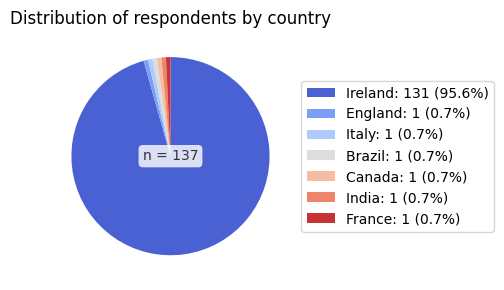

In [17]:
QUESTION_COL = "What country are you from?"

# Sort legend in frequency order for readability
cat_order = (
    Survey[QUESTION_COL].dropna().value_counts().index.tolist()
)

out = plot_single_question(
    df=Survey,
    question_col=QUESTION_COL,
    multi_label=False,

    # Let the function generate colors from the palette
    pie_colors=None,            # ← important
    pie_cmap="coolwarm",        # ← your palette
    pie_cmap_reverse=False,     # set True to flip red↔blue
    pie_use_base_color=False,   # ensure multi-color palette (not single shade)
    category_order=cat_order,   # optional but helps with consistent legends
    sort_by=None,               # already sorted via cat_order
    chart="pie",
    fig_title="Distribution of respondents by country",
    y_label=None,
    return_data=True,
    display=True
)

## Age

In [19]:
# What age are you?

In [20]:
Survey["What age are you?"].apply(type).value_counts() # total 359 rows, but including NaN

What age are you?
<class 'float'>    359
Name: count, dtype: int64

In [21]:
Survey["What age are you?"].count() # 144 non NaN responses, floats (full numbers)

144

In [22]:
Survey["What age are you?"].isna().sum()

215

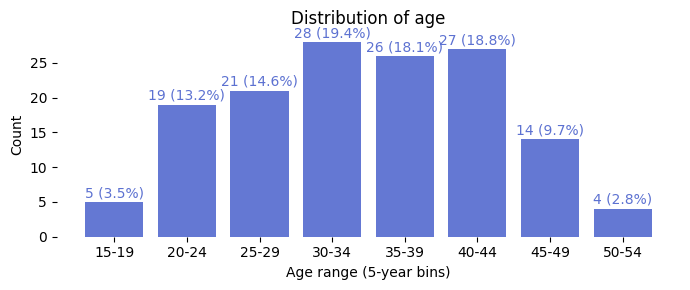

In [23]:
QUESTION_COL = "What age are you?"

# Clean age values 
age_series = pd.to_numeric(Survey[QUESTION_COL], errors="coerce")
age_series = age_series[(age_series > 0) & (age_series < 130)]

if age_series.empty:
    raise ValueError(f"No valid ages found in column '{col}' after cleaning.")

# Build 5-year age bins
min_age = int(np.floor(age_series.min()))
max_age = int(np.floor(age_series.max()))

start_bin = (min_age // 5) * 5
end_bin = ((max_age + 4) // 5) * 5
if end_bin <= start_bin:
    end_bin = start_bin + 5

bins = list(range(start_bin, end_bin + 5, 5))
labels = [f"{bins[i]}-{bins[i+1]-1}" for i in range(len(bins)-1)]

# Assign age groups 
age_groups = pd.cut(
    age_series,
    bins=bins,
    right=False,
    labels=labels,
    include_lowest=True
)

# Make a temporary working column in the dataframe
Survey["_age_group"] = age_groups.astype(str)

# Plot using your unified function 
out = plot_single_question(
    df=Survey,
    question_col="_age_group",
    multi_label=False,
    allowed_answers=labels,        # order the bins correctly
    map_dict={lab: lab for lab in labels},
    category_order=labels,
    include_other=False,
    chart="barv",                 # <<< vertical bars
    rescale_to_100=False,          # <<< use counts instead of % on y-axis
    axis_label="Count", 
    y_label="Age range (5-year bins)",
    fig_title="Distribution of age",
    return_data=True,
    display=True
)

# Remove temporary column
Survey.drop(columns=["_age_group"], inplace=True)

## Diagnosis of endometriosis and other gyneacological conditions

In [25]:
# Have you been diagnosed with endometriosis?

In [26]:
Survey["Have you been diagnosed with endometriosis?"].apply(type).value_counts()

Have you been diagnosed with endometriosis?
<class 'str'>    359
Name: count, dtype: int64

In [27]:
Survey["Have you been diagnosed with endometriosis?"].count() 

359

In [28]:
Survey["Have you been diagnosed with endometriosis?"].isna().sum()

0

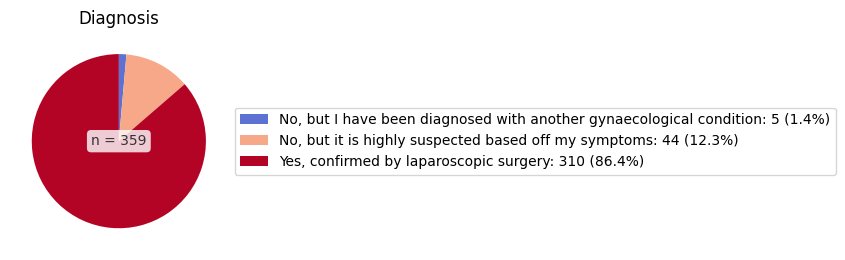

In [29]:
QUESTION_COL = "Have you been diagnosed with endometriosis?"

# Define categories + color
CATEGORIES = [
    ("No, I do not suffer from any gynaecological conditions", "#34A853"),  # green
    ("No, but I have been diagnosed with another gynaecological condition", "#5c71d1"),  # blue
    ("No, but it is highly suspected based off my symptoms", "#f7a889"),  # orange
    ("Yes, confirmed by laparoscopic surgery", "#b40426"),  # red
]

cat_order  = [label for label, _ in CATEGORIES]
map_dict   = {label: label for label, _ in CATEGORIES}  # identity map (normalize only to these)
pie_colors = dict(CATEGORIES)

# Plot
out = plot_single_question(
    df=Survey,
    question_col=QUESTION_COL,
    multi_label=False,
    allowed_answers=cat_order,
    map_dict=map_dict,
    include_other=False,
    sort_by=None,
    category_order=cat_order,
    chart="pie",
    fig_title="Diagnosis",
    y_label=None,
    pie_colors=pie_colors,
    return_data=True,
    display=True
)


In [30]:
# We have mainly patients but also some controls, this is important to take in account

## Select only laparoscopy confirmed patients

In [32]:
# Create dataframe with only endo patients
Survey_endo_only = Survey[Survey['Have you been diagnosed with endometriosis?'] == 'Yes, confirmed by laparoscopic surgery']

In [33]:
# Export to excel
Survey_endo_only.to_excel("Survey_endo_only.xlsx", index=False)

In [34]:
Survey_endo_only.shape # 310 respondents have endometriosis laparoscopy confirmed

(310, 88)

## Other gyneacological conditions

In [36]:
# Please list any other gynaecological conditions you have been diagnosed with 

In [37]:
Survey["Please list any other gynaecological conditions you have been diagnosed with "].apply(type).value_counts()

Please list any other gynaecological conditions you have been diagnosed with 
<class 'float'>    215
<class 'str'>      144
Name: count, dtype: int64

In [38]:
Survey_endo_only["Please list any other gynaecological conditions you have been diagnosed with "].apply(type).value_counts()

Please list any other gynaecological conditions you have been diagnosed with 
<class 'float'>    193
<class 'str'>      117
Name: count, dtype: int64

In [39]:
Survey_endo_only["Please list any other gynaecological conditions you have been diagnosed with "].count()

117

In [40]:
Survey["Please list any other gynaecological conditions you have been diagnosed with "].isna().sum()

215

In [41]:
Survey_endo_only["Please list any other gynaecological conditions you have been diagnosed with "].isna().sum()

193

In [42]:
# Check for any other itemas I may include 
common_items = (
    Survey['Please list any other gynaecological conditions you have been diagnosed with ']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 1].head(50))

Please list any other gynaecological conditions you have been diagnosed with 
adenomyosis                          53
pcos (polycystic ovary syndrome)     52
fibroids                              9
pid (pelvic inflammatory disease)     6
ovarian cysts                         3
uterine fibroids                      3
pelvic congestion syndrome            3
endosalpingiosis                      2
vaginismus                            2
cervical cancer                       2
Name: count, dtype: int64


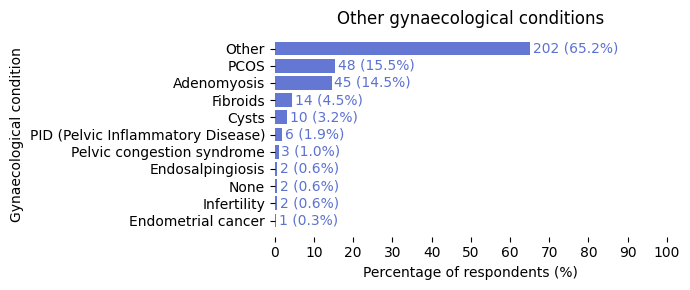

In [43]:
QUESTION_COL = "Please list any other gynaecological conditions you have been diagnosed with "

# Custom category mapper with priority logic (PCOS > Cysts) ---
def map_gyn_other_multilabel(raw: str):
    if raw is None:
        return ["None"]

    s = str(raw).strip()
    sn = s.casefold()

    # Detect 'None' meanings 
    none_patterns = [
        r'\bnone\b', r'\bno other\b', r'\bno\b', 
        r'\bn/?a\b', r'\bnil\b'
    ]
    if any(re.search(p, sn) for p in none_patterns):
        return ["None"]

    categories_found = []

    # PCOS (separate because it contains "cyst" textually) 
    has_pcos = bool(re.search(r'\bpcos\b', sn))

    if has_pcos:
        categories_found.append("PCOS")

    # Cysts (only if PCOS not present) 
    has_cyst = bool(re.search(r'\bcyst(s)?\b', sn))
    if has_cyst and not has_pcos:
        categories_found.append("Cysts")

    # Other categories (can all co-occur)
    patterns = {
        "PID (Pelvic Inflammatory Disease)": [r'\bpid\b', r'pelvic inflammatory disease'],
        "Cervical cancer": [r'cervical cancer'],
        "Endometrial cancer": [r'endometrial cancer'],
        "Adenomyosis": [r'\badenomyosis\b'],
        "Fibroids": [r'\bfibroid(s)?\b'],
        "Endosalpingiosis": [r'endosalpingiosis'],
        "Pelvic congestion syndrome": [r'pelvic congestion syndrome'],
        "Infertility": [r'\binfertilit(y|ies)\b', r'\bsubfertilit(y|ies)\b']
    }

    for label, patterns_list in patterns.items():
        for p in patterns_list:
            if re.search(p, sn):
                categories_found.append(label)
                break  # avoid duplicate insertion

    # If nothing matched yet → assign "Other" 
    if len(categories_found) == 0:
        return ["Other"]

    return categories_found

# Plot
out = plot_single_question(
    df=Survey_endo_only,
    question_col=QUESTION_COL,
    category_func=map_gyn_other_multilabel,
    multi_label=True,
    na_to_category=None,            # mapper already returns ["None"] for NA/none-like
    remove_values=(),               # count everyone
    rescale_to_100=True,           # bar length = counts; labels include % of respondents
    sort_by="count_desc",             
    chart="barh",
    y_label="Gynaecological condition",
    fig_title="Other gynaecological conditions",
    return_data=True,
    display=True
)

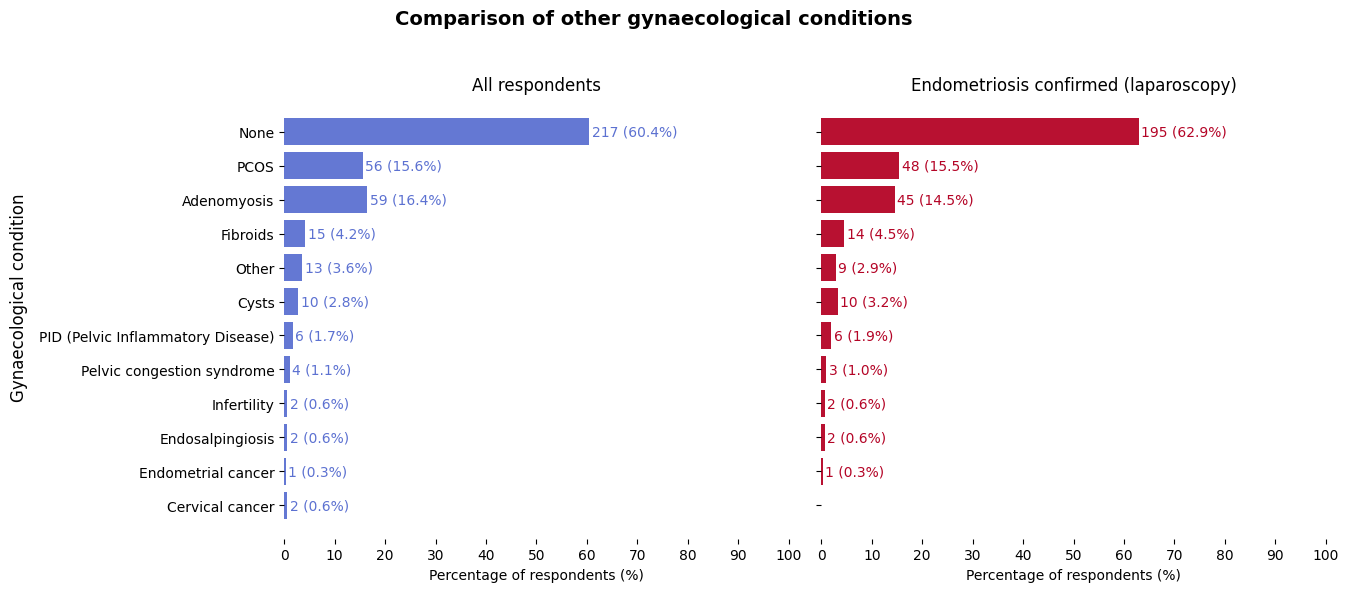

In [44]:
# Other gyneacological conditions- map all patients vs only confirmed patients together

QUESTION_COL = "Please list any other gynaecological conditions you have been diagnosed with "

# Multi-label mapper
import re

def map_gyn_other_multilabel(raw: str):
    if raw is None:
        return ["None"]

    s = str(raw).strip()
    sn = s.casefold()

    # Detect 'None' meanings 
    none_patterns = [
        r'\bnone\b', r'\bno other\b', r'\bno\b',
        r'\bn/?a\b', r'\bnil\b'
    ]
    if any(re.search(p, sn) for p in none_patterns):
        return ["None"]

    categories_found = []

    # PCOS (priority over cysts) 
    has_pcos = bool(re.search(r'\bpcos\b', sn))
    if has_pcos:
        categories_found.append("PCOS")

    # Cysts (only if PCOS not present) 
    has_cyst = bool(re.search(r'\bcyst(s)?\b', sn))
    if has_cyst and not has_pcos:
        categories_found.append("Cysts")

    # Other categories 
    patterns = {
        "PID (Pelvic Inflammatory Disease)": [r'\bpid\b', r'pelvic inflammatory disease'],
        "Cervical cancer": [r'cervical cancer'],
        "Endometrial cancer": [r'endometrial cancer'],
        "Adenomyosis": [r'\badenomyosis\b'],
        "Fibroids": [r'\bfibroid(s)?\b'],
        "Endosalpingiosis": [r'endosalpingiosis'],
        "Pelvic congestion syndrome": [r'pelvic congestion syndrome'],
        "Infertility": [r'\binfertilit(y|ies)\b', r'\bsubfertilit(y|ies)\b']
    }
    for label, patterns_list in patterns.items():
        for p in patterns_list:
            if re.search(p, sn):
                categories_found.append(label)
                break  # avoid duplicate insertion

    if len(categories_found) == 0:
        return ["Other"]

    return categories_found

# Safety: ensure no missing values
Survey_endo_only = Survey[Survey['Have you been diagnosed with endometriosis?'] == 'Yes, confirmed by laparoscopic surgery'].copy()
Survey[QUESTION_COL] = Survey[QUESTION_COL].fillna("None")
Survey_endo_only[QUESTION_COL] = Survey_endo_only[QUESTION_COL].fillna("None")

def compute_counts_via_mapper(df, question_col, mapper):
    """
    Multi-label counting:
      - Applies mapper to each response (returns a list).
      - Increments each mentioned category ONCE per respondent.
      - Returns a pandas Series of counts per category.
    """
    mapped = df[question_col].apply(mapper)
    ctr = Counter()
    for lst in mapped:
        if not isinstance(lst, list):
            continue
        unique_cats = set([x for x in lst if x is not None])
        for cat in unique_cats:
            ctr[cat] += 1
    return pd.Series(ctr, dtype=int).sort_index() if len(ctr) else pd.Series(dtype=int)

# Compute counts using the mapper
counts_all  = compute_counts_via_mapper(Survey, QUESTION_COL, map_gyn_other_multilabel)
counts_endo = compute_counts_via_mapper(Survey_endo_only, QUESTION_COL, map_gyn_other_multilabel)

# Build a combined order (All + Endo):
# Sort ASCENDING here so that invert_yaxis() puts the largest at the TOP 
cats_union = sorted(set(counts_all.index).union(set(counts_endo.index)))
combined = counts_all.reindex(cats_union, fill_value=0) + counts_endo.reindex(cats_union, fill_value=0)
order = combined.sort_values(ascending=True).index  # ascending → invert_yaxis will place largest at top

# Align both to the same order
counts_all = counts_all.reindex(order, fill_value=0)
counts_endo = counts_endo.reindex(order, fill_value=0)

# Compute % of respondents (bar lengths will use these)
total_all = len(Survey)
total_endo = len(Survey_endo_only)
perc_all = (counts_all / total_all * 100.0) if total_all > 0 else counts_all * 0.0
perc_endo = (counts_endo / total_endo * 100.0) if total_endo > 0 else counts_endo * 0.0

# Plot side-by-side (percent bars) 
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Colors
color_all = "#5c71d1"   # Blue
color_endo = "#b40426"  # Red

# LEFT: All respondents (bars = % of respondents)
bars_all = axes[0].barh(perc_all.index, perc_all.values, color=color_all, alpha=0.95)
axes[0].set_title("All respondents")
axes[0].set_xlabel("Percentage of respondents (%)")
axes[0].set_xlim(0, 100)
axes[0].set_xticks(np.arange(0, 101, 10))
axes[0].grid(False)
for spine in axes[0].spines.values():
    spine.set_visible(False)

# Annotate with "count (p%)"
for i, bar in enumerate(bars_all):
    w = bar.get_width()
    cnt = int(counts_all.iloc[i])
    pct = perc_all.iloc[i]
    if w > 0:
        axes[0].text(w + 0.5, bar.get_y() + bar.get_height()/2,
                     f'{cnt} ({pct:.1f}%)', va='center', ha='left', color=color_all)

# Put MOST ABUNDANT at TOP (same trick as your original: invert after sorting ascending)
axes[0].invert_yaxis()

# RIGHT: Endometriosis Confirmed (bars = % of respondents)
bars_endo_plot = axes[1].barh(perc_endo.index, perc_endo.values, color=color_endo, alpha=0.95)
axes[1].set_title("Endometriosis confirmed (laparoscopy)")
axes[1].set_xlabel("Percentage of respondents (%)")  
axes[1].set_xlim(0, 100)
axes[1].set_xticks(np.arange(0, 101, 10))
axes[1].grid(False)
for spine in axes[1].spines.values():
    spine.set_visible(False)

for i, bar in enumerate(bars_endo_plot):
    w = bar.get_width()
    cnt = int(counts_endo.iloc[i])
    pct = perc_endo.iloc[i]
    if w > 0:
        axes[1].text(w + 0.5, bar.get_y() + bar.get_height()/2,
                     f'{cnt} ({pct:.1f}%)', va='center', ha='left', color=color_endo)

# Put MOST ABUNDANT at TOP
axes[1].invert_yaxis()

# Show category tick labels ONLY on the left
axes[1].tick_params(labelleft=False)

# Common y-axis label on the figure
fig.text(0.04, 0.5, 'Gynaecological condition', va='center', rotation='vertical', fontsize=12)

# Shared figure title
fig.suptitle("Comparison of other gynaecological conditions", fontsize=14, fontweight='bold')

plt.tight_layout(rect=[0.05, 0.0, 1.0, 0.95])
plt.show()

## Do the remaining questions only on laparoscopy confirmed endometriosis patients

## Symptoms

In [47]:
# What were the first 3 symptoms you noticed?

In [48]:
Survey_endo_only["What were the first 3 symptoms you noticed?"].apply(type).value_counts()

What were the first 3 symptoms you noticed?
<class 'str'>    310
Name: count, dtype: int64

In [49]:
Survey_endo_only["What were the first 3 symptoms you noticed?"].count()

310

In [50]:
Survey_endo_only["What were the first 3 symptoms you noticed?"].isna().sum()

0

In [51]:
# Check for any other itemas I may include 
common_items = (
    Survey_endo_only['What were the first 3 symptoms you noticed?']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 1].head(50))

What were the first 3 symptoms you noticed?
painful periods (dysmenorrhea)                         256
heavy or prolonged menstrual bleeding (menorrhagia)    178
pelvic pain                                            156
pain in the lower back                                 113
legs                                                   113
painful bowel movements                                104
fatigue                                                 93
bloating                                                86
nausea                                                  66
headaches/migraines                                     57
infertility                                             21
fainting                                                 3
painful sex                                              3
painful intercourse                                      3
vomiting                                                 2
pain during intercourse                                  2
Name: count,

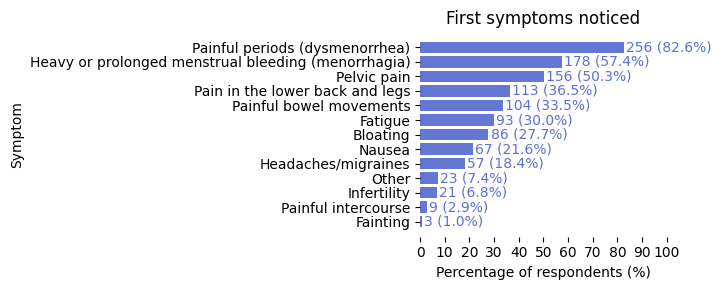

In [52]:
QUESTION_COL = "What were the first 3 symptoms you noticed?"

def map_symptoms_multilabel(raw: str):
    """
    Multilabel mapper for the free-text symptom question.

    Categories detected (co-occur allowed):
    - Pelvic pain
    - Painful periods (dysmenorrhea)
    - Heavy or prolonged menstrual bleeding (menorrhagia)
    - Painful bowel movements
    - Fatigue
    - Infertility
    - Bloating
    - Nausea  [includes vomiting/retching/throwing up]
    - Pain in the lower back and legs
    - Headaches/migraines
    - Painful intercourse
    - Fainting  [syncope / passed out / blacked out]

    'Other' is added if unknown symptoms are present (e.g., heavy legs, kidney infections,
    bleeding when running/exercising, dizziness/lightheadedness, spotting, constipation, etc.)
    or if list heuristics imply unrecognized items.
    """
    if raw is None:
        return ["None"]

    s = str(raw).strip()
    sn = s.casefold()

    # Detect 'None' meanings (strict to avoid false positives) 
    none_patterns = [
        r'^\s*none\s*$', r'^\s*no other\s*$', r'^\s*no\s*$', r'^\s*n/?a\s*$',
        r'^\s*nil\s*$'
    ]
    if any(re.search(p, sn) for p in none_patterns):
        return ["None"]

    categories_found = []

    #  Symptom patterns (co-occur allowed) 
    patterns = {
        "Pelvic pain": [
            r"\bpelvic pain\b", r"\bpelvic ache\b", r"\bpain in the pelvis\b"
        ],
        "Painful periods (dysmenorrhea)": [
            r"\bpainful periods?\b", r"\bdysmenorrhea\b", r"\bperiod cramps?\b",
            r"\bsevere cramps?\b", r"\bmenstrual cramps?\b"
        ],
        "Heavy or prolonged menstrual bleeding (menorrhagia)": [
            r"\bheavy (or )?prolonged menstrual bleeding\b", r"\bmenorrhagia\b",
            r"\bheavy bleed(ing)?\b", r"\blong(er)? periods?\b",
            # Colloquial heavy-flow terms
            r"\bflooding\b",
            r"\b(pass(ing)? )?clots?\b",
            # Tissue described during periods
            r"\btissue (coming|came) out\b",
            r"\btissue (during|with) (my )?period(s)?\b",
            r"\btissue\b.*\bperiod(s)?\b",
        ],
        "Painful bowel movements": [
            r"\bpainful bowel movements?\b", r"\bpain when (having )?bowel movements?\b"
        ],
        "Fatigue": [
            r"\bfatigue\b", r"\btired(ness)?\b", r"\bexhaust(ion|ed)\b"
        ],
        "Infertility": [
            r"\binfertility\b", r"\bdifficulty (getting|becoming) pregnant\b"
        ],
        "Bloating": [
            r"\bbloating\b", r"\bbloated\b", r"\babdominal distension\b"
        ],
        "Nausea": [
            r"\bnausea\b", r"\bnauseous\b", r"\bqueasy\b",
            # Map vomiting under Nausea
            r"\bvomit(ing)?\b", r"\bretch(ing)?\b", r"\bthrow(ing)? up\b"
        ],
        "Pain in the lower back and legs": [
            r"\bpain in the lower back( and legs)?\b", r"\blower back pain\b",
            r"\bpain in (my|the) legs\b", r"\bleg pain\b"
        ],
        "Headaches/migraines": [
            r"\bheadaches?\b", r"\bmigraines?\b", r"\bmigraine\b"
        ],
        "Painful intercourse": [
            r"\bpainful sex\b", r"\bpainful intercourse\b",
            r"\bpain during intercourse\b", r"\bdyspareunia\b",
            r"\bpain with penetration\b"
        ],
        "Fainting": [
            r"\bfaint(ing)?\b",
            r"\bsyncope\b",
            r"\bpassed out\b", r"\bpass(ing)? out\b",
            r"\bblack(ed)? out\b"
        ],
    }

    #'Other' symptom hints (expanded for your cases) 
    other_hints = [
        # Pool these to Other as requested
        r"\bheavy legs?\b",
        r"\bpain (and )?bleeding when running\b",
        r"\bbleeding (when|while) (running|exercis(e|ing))\b",
        r"\breocc?urr?ing kidney infections?\b",
        r"\bkidney infections?\b",

        # General "Other" cues (excluding Fainting & Vomiting which are covered above)
        r"\blight[-\s]?headed(ness)?\b",
        r"\bdizz(y|iness)\b",
        r"\bspotting\b",
        r"\bconstipation\b",
        r"\bdiarrh(oea|hea)\b",
        r"\babdominal pain\b",            # if not captured by pelvic pain wording
        r"\bshoulder pain\b",             # referred pain often mentioned
        r"\bpain (during|with) urination\b", r"\bdysuria\b",
        r"\burinary (frequency|urgency)\b",
    ]

    # Match categories 
    for label, patterns_list in patterns.items():
        for p in patterns_list:
            if re.search(p, sn):
                categories_found.append(label)
                break  # avoid duplicate insertion per label

    # If nothing matched at all -> pure Other or None 
    if len(categories_found) == 0:
        if re.search(r"[a-z]", sn):
            return ["Other"]
        else:
            return ["None"]

    #  Add 'Other' if non-catalogued symptom cues are present
    other_flag = any(re.search(p, sn) for p in other_hints)

    # Heuristic: "and other", "etc.", "and more"
    if not other_flag and re.search(r"\band other\b|\betc\.?\b|\band more\b", sn):
        other_flag = True

    # Conservative list heuristic:
    # If the text looks like a list but we matched fewer than likely items, add Other.
    if not other_flag:
        if (("," in sn) or ("/" in sn) or (";" in sn)) and len(categories_found) < 3:
            other_flag = True

    if other_flag and "Other" not in categories_found:
        categories_found.append("Other")

    return categories_found


out = plot_single_question(
    df=Survey_endo_only,
    question_col=QUESTION_COL,
    category_func=map_symptoms_multilabel,
    multi_label=True,
    na_to_category=None,     # mapper handles "None"
    remove_values=(),        # count everyone
    rescale_to_100=True,     # bars are % of respondents (0–100)
    sort_by="count_desc",
    chart="barh",
    y_label="Symptom",
    fig_title="First symptoms noticed",
    return_data=True,
    display=True
)

## Age of symptoms

In [54]:
# At what age roughly did you notice your symptoms begin?

In [55]:
Survey_endo_only["At what age roughly did you notice your symptoms begin?"].apply(type).value_counts() # answers are mixed numbers and words

At what age roughly did you notice your symptoms begin?
<class 'int'>      281
<class 'str'>       25
<class 'float'>      4
Name: count, dtype: int64

In [56]:
Survey_endo_only["At what age roughly did you notice your symptoms begin?"].count()

306

In [57]:
Survey_endo_only["At what age roughly did you notice your symptoms begin?"].isna().sum()

4

In [58]:
# Check for responses
common_items = (
    Survey_endo_only['At what age roughly did you notice your symptoms begin?']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 1].head(50))

At what age roughly did you notice your symptoms begin?
nan           281
early 20s       2
14/15           2
late teens      2
Name: count, dtype: int64


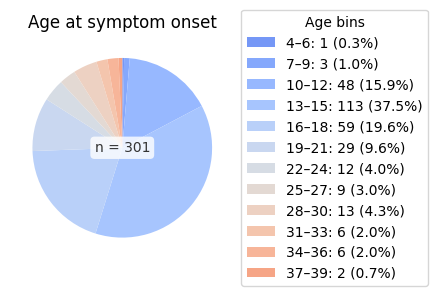

In [59]:
QUESTION_COL = "At what age roughly did you notice your symptoms begin?"

bin_tuples = [(0, 3, "0–3")] + [(a, a+2, f"{a}–{a+2}") for a in range(4, 100, 3)]
cat_order_asc = [lab for (_, _, lab) in bin_tuples]

out_age_numeric = plot_single_question(
    df=Survey_endo_only,
    question_col=QUESTION_COL,
    numeric=True,
    number_pattern=r"\d+",
    number_extract="first",
    numeric_range=(1, 129),
    numeric_bins=bin_tuples,
    rescale_to_100=True,
    remove_values=(),
    sort_by=None,
    category_order=cat_order_asc,
    chart="pie",
    fig_title="Age at symptom onset",
    y_label="Age bins",
    pie_colors=PALETTE_0_48,
    pie_use_base_color=False,
    pie_cmap="coolwarm",
    pie_cmap_reverse=False,
    pie_distinct_subset=False,
    return_data=True,
    display=True
)

## Pain

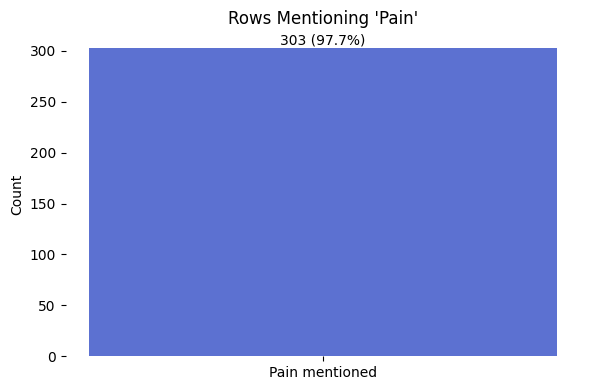

In [61]:
# Pain-see how many answers included pain

# Column name
col = 'What were the first 3 symptoms you noticed?'

# Drop NaN values
symptom_data = Survey_endo_only[col].dropna()

# Create mask for rows containing 'pain' (case-insensitive)
pain_mask = symptom_data.str.contains('pain', case=False, na=False)

# Count rows with 'pain'
pain_count = pain_mask.sum()
total = len(symptom_data)

# Plot bar chart
plt.figure(figsize=(6, 4))
bars = plt.bar(['Pain mentioned'], [pain_count], color="#5c71d1")

# Add count and percentage
percent = (pain_count / total) * 100
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.1,
             f'{int(height)} ({percent:.1f}%)', ha='center', va='bottom')

# Remove frame
for spine in plt.gca().spines.values():
    spine.set_visible(False)

# Labels and title
plt.ylabel("Count")
plt.title("Rows Mentioning 'Pain'")
plt.tight_layout()
plt.show()

In [62]:
# Filter rows where 'pain' is NOT present in the specified column (case-insensitive)
no_pain_df = Survey_endo_only[~Survey_endo_only['What were the first 3 symptoms you noticed?']
                     .str.contains('pain', case=False, na=False)]

# Show the number of such responses
print(f"Number of responses without 'pain': {len(no_pain_df)}")

# Display the first few rows for review
print(no_pain_df[['What were the first 3 symptoms you noticed?']].head(20))

Number of responses without 'pain': 7
                                           What were the first 3 symptoms you noticed?
44              Heavy or prolonged menstrual bleeding (Menorrhagia), Fatigue, Bloating
76                         Heavy or prolonged menstrual bleeding (Menorrhagia), Nausea
138  Heavy or prolonged menstrual bleeding (Menorrhagia), Fatigue, Headaches/migraines
139                                                                        Infertility
176                                               Fatigue, Bloating, Rapid weight gain
292                                                            Infertility, Diahorrea 
348   Heavy or prolonged menstrual bleeding (Menorrhagia), Nausea, Headaches/migraines


In [63]:
# Did you have any unexplained pain in your tummy as a child?

In [64]:
Survey_endo_only["Did you have any unexplained pain in your tummy as a child?"].apply(type).value_counts()

Did you have any unexplained pain in your tummy as a child?
<class 'str'>      308
<class 'float'>      2
Name: count, dtype: int64

In [65]:
Survey_endo_only["Did you have any unexplained pain in your tummy as a child?"].count()

308

In [66]:
Survey_endo_only["Did you have any unexplained pain in your tummy as a child?"].isna().sum()

2

In [67]:
# Check responses
common_items = (
    Survey_endo_only['Did you have any unexplained pain in your tummy as a child?']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 1].head(50))

Did you have any unexplained pain in your tummy as a child?
yes      130
no       114
maybe     64
Name: count, dtype: int64


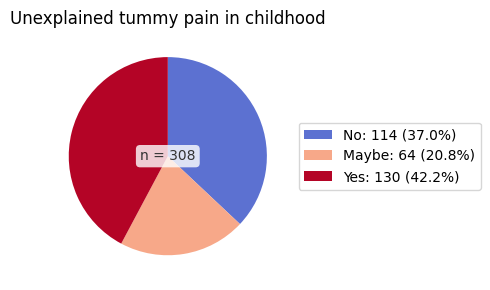

In [68]:
QUESTION_COL = "Did you have any unexplained pain in your tummy as a child?"

# Define once: label + color
CATEGORIES = [
    ("No", "#5c71d1"),  # blue
    ("Maybe", "#f7a889"),  # orange
    ("Yes", "#b40426")  # red
]

cat_order  = [label for label, _ in CATEGORIES]
map_dict   = {label: label for label, _ in CATEGORIES}  # identity map (normalize only to these)
pie_colors = dict(CATEGORIES)

# Plot
out = plot_single_question(
    df=Survey_endo_only,
    question_col=QUESTION_COL,
    multi_label=False,
    allowed_answers=cat_order,
    map_dict=map_dict,
    include_other=False,
    remove_values=("unsure", "none", "", np.nan),  # or remove_values=()
    sort_by=None,
    category_order=cat_order,
    chart="pie",
    fig_title="Unexplained tummy pain in childhood",
    y_label=None,
    pie_colors=pie_colors,
    return_data=True,
    display=True
)

## Timing of tummy pain

In [70]:
# If yes, at what age did this pain begin?

In [71]:
Survey_endo_only["If yes, at what age did this pain begin?"].apply(type).value_counts()

If yes, at what age did this pain begin?
<class 'float'>    246
<class 'str'>       64
Name: count, dtype: int64

In [72]:
Survey_endo_only["If yes, at what age did this pain begin?"].count()

64

In [73]:
Survey_endo_only["If yes, at what age did this pain begin?"].isna().sum()

246

In [74]:
# Check responses
common_items = (
    Survey_endo_only['If yes, at what age did this pain begin?']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)
print(common_items[common_items > 1].head(50))

If yes, at what age did this pain begin?
7-9      24
10-12    20
13-15    10
4-6       6
0-3       2
16-18     2
Name: count, dtype: int64


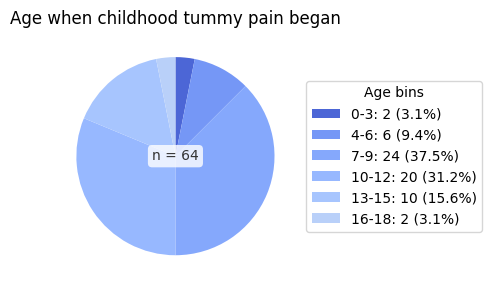

In [75]:
QUESTION_COL = "If yes, at what age did this pain begin?"
age_order = ["0-3","4-6","7-9","10-12","13-15","16-18","19-21","22-24","25-27","28-30"]

out = plot_single_question(
    df=Survey_endo_only,
    question_col=QUESTION_COL,
    rescale_to_100=True,
    remove_values=(),
    sort_by=None,
    category_order=age_order,
    chart="pie",
    fig_title="Age when childhood tummy pain began",
    y_label="Age bins",
    pie_colors=PALETTE_0_48,
    pie_use_base_color=False,
    pie_cmap="coolwarm",
    pie_cmap_reverse=False,
    pie_distinct_subset=False,
    return_data=True,
    display=True
)

## Tummy pain timing regarding periods

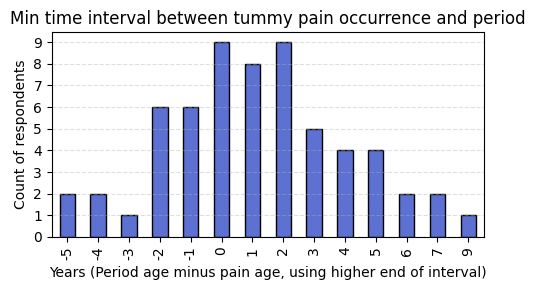

In [77]:
# What is the time between the pain and when the period started?

# Helper: parse the "interval" column and take the higher number 
def extract_highest_age(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float)):
        return float(value)
    s = str(value).replace("–", "-").replace("—", "-")
    nums = re.findall(r"\d+", s)
    if not nums:
        return np.nan
    return max(float(n) for n in nums)

# Columns 
col_period = 'At what age did your period begin?'
col_pain   = 'If yes, at what age did this pain begin?'

df = Survey_endo_only.copy()
df['_pain_age_high'] = df[col_pain].apply(extract_highest_age)
df['_period_age'] = pd.to_numeric(df[col_period], errors='coerce')

# Compute difference only where both present =
diff_col = 'Min time interval between tummy pain occurrence and period'
df[diff_col] = df['_period_age'] - df['_pain_age_high']

valid = df[~df[diff_col].isna()].copy()

#  Bar chart with integer axes 
counts = valid[diff_col].value_counts().sort_index()

# Make x tick labels integers (no decimals)
try:
    # If differences are floats but represent whole numbers, cast them
    counts.index = counts.index.astype(int)
except Exception:
    # If casting fails (true floats), you can round first:
    counts.index = counts.index.round().astype(int)
    # Regroup counts if rounding was needed
    counts = counts.groupby(counts.index).sum().sort_index()

plt.figure(figsize=(5, 3))
counts.plot(kind='bar', color='#5c71d1', edgecolor='black')

plt.title('Min time interval between tummy pain occurrence and period')
plt.xlabel('Years (Period age minus pain age, using higher end of interval)')
plt.ylabel('Count of respondents')

# Force y-axis to show integer-only ticks
ax = plt.gca()
ax.yaxis.set_major_locator(MaxNLocator(integer=True))

# Show grid lines
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# Optional: assign back to original dataframe if needed
# Survey_endo_only[diff_col] = df[diff_col]

## Periods

In [79]:
# At what age did your period begin?

In [80]:
Survey_endo_only["At what age did your period begin?"].apply(type).value_counts() # answers are mixed numbers and words

At what age did your period begin?
<class 'float'>    183
<class 'int'>      121
<class 'str'>        6
Name: count, dtype: int64

In [81]:
Survey_endo_only["At what age did your period begin?"].count()

127

In [82]:
Survey_endo_only["At what age did your period begin?"].isna().sum()

183

In [83]:
# Check responses
common_items = (
    Survey_endo_only['At what age did your period begin?']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 0].head(50))

At what age did your period begin?
nan                   121
nearly 1 years old      1
12/13                   1
14-15                   1
9ish                    1
13 or 14                1
13/4                    1
Name: count, dtype: int64


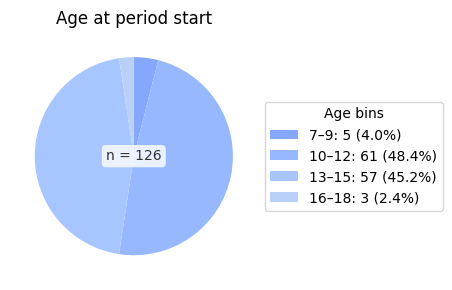

In [84]:
QUESTION_COL = "At what age did your period begin?"

bin_tuples = [(0, 3, "0–3")] + [(a, a+2, f"{a}–{a+2}") for a in range(4, 100, 3)]
cat_order_asc = [lab for (_, _, lab) in bin_tuples]

out_age_numeric = plot_single_question(
    df=Survey_endo_only,
    question_col=QUESTION_COL,
    numeric=True,
    number_pattern=r"\d+",
    number_extract="first",
    numeric_range=(5, 129),
    numeric_bins=bin_tuples,
    rescale_to_100=True,
    remove_values=(),
    sort_by=None,
    category_order=cat_order_asc,
    chart="pie",
    fig_title="Age at period start",
    y_label="Age bins",
    pie_colors=PALETTE_0_48,
    pie_use_base_color=False,
    pie_cmap="coolwarm",
    pie_cmap_reverse=False,
    pie_distinct_subset=False,
    return_data=True,
    display=True
)

In [85]:
# Did/do you suffer from heavy or extreme menstrual bleeding?

In [86]:
Survey_endo_only["Did/do you suffer from heavy or extreme menstrual bleeding?"].apply(type).value_counts() 

Did/do you suffer from heavy or extreme menstrual bleeding?
<class 'str'>    310
Name: count, dtype: int64

In [87]:
Survey_endo_only["Did/do you suffer from heavy or extreme menstrual bleeding?"].count() 

310

In [88]:
Survey_endo_only["Did/do you suffer from heavy or extreme menstrual bleeding?"].isna().sum()

0

In [89]:
# Check responses
common_items = (
    Survey_endo_only['Did/do you suffer from heavy or extreme menstrual bleeding?']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 0].head(50))

Did/do you suffer from heavy or extreme menstrual bleeding?
yes    243
no      67
Name: count, dtype: int64


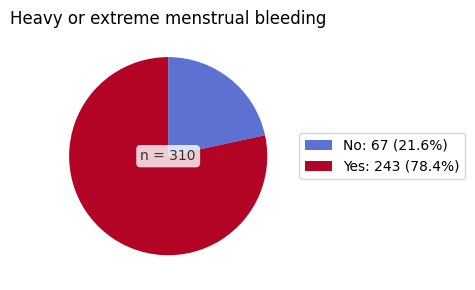

In [90]:
QUESTION_COL = "Did/do you suffer from heavy or extreme menstrual bleeding?"

# Define once: label + color
CATEGORIES = [
    ("No", "#5c71d1"),  # blue
    ("Yes", "#b40426")  # red
]

cat_order  = [label for label, _ in CATEGORIES]
map_dict   = {label: label for label, _ in CATEGORIES}  
pie_colors = dict(CATEGORIES)

# Plot
out = plot_single_question(
    df=Survey_endo_only,
    question_col=QUESTION_COL,
    multi_label=False,
    allowed_answers=cat_order,
    map_dict=map_dict,
    include_other=False,
    remove_values=("unsure", "none", "", np.nan),  # or remove_values=()
    sort_by=None,
    category_order=cat_order,
    chart="pie",
    fig_title="Heavy or extreme menstrual bleeding",
    y_label=None,
    pie_colors=pie_colors,
    return_data=True,
    display=True
)

In [91]:
# Were/are you periods regular?

In [92]:
Survey_endo_only["Were/are you periods regular?"].apply(type).value_counts() 

Were/are you periods regular?
<class 'str'>    310
Name: count, dtype: int64

In [93]:
Survey_endo_only["Were/are you periods regular?"].count() 

310

In [94]:
Survey_endo_only["Were/are you periods regular?"].isna().sum()

0

In [95]:
# Check responses
common_items = (
    Survey_endo_only['Were/are you periods regular?']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 0].head(50))

Were/are you periods regular?
yes    212
no      98
Name: count, dtype: int64


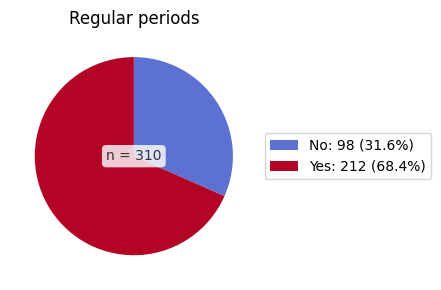

In [96]:
QUESTION_COL = "Were/are you periods regular?"

# Define once: label + color
CATEGORIES = [
    ("No", "#5c71d1"),  # blue
    ("Yes", "#b40426")  # red
]

cat_order  = [label for label, _ in CATEGORIES]
map_dict   = {label: label for label, _ in CATEGORIES}  
pie_colors = dict(CATEGORIES)

# Plot
out = plot_single_question(
    df=Survey_endo_only,
    question_col=QUESTION_COL,
    multi_label=False,
    allowed_answers=cat_order,
    map_dict=map_dict,
    include_other=False,
    remove_values=("unsure", "none", "", np.nan),  
    sort_by=None,
    category_order=cat_order,
    chart="pie",
    fig_title="Regular periods",
    y_label=None,
    pie_colors=pie_colors,
    return_data=True,
    display=True
)

In [97]:
# Heavy bleeding and period regularity

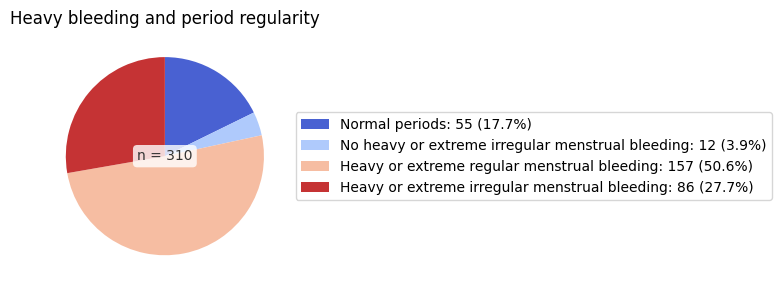

In [98]:
col_heavy   = "Did/do you suffer from heavy or extreme menstrual bleeding?"
col_regular = "Were/are you periods regular?"

# Normalize answers (robust to case/spacing)
def norm_yes_no(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s.startswith("y"):              # yes, y
        return "yes"
    if s.startswith("n"):              # no, n
        return "no"
    if "unsure" in s or "prefer not" in s or s == "":
        return np.nan
    return np.nan

def norm_regular_irregular(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if "irreg" in s or s.startswith("no"):   # "no (not regular)" variants treated as irregular
        return "irregular"
    if "reg" in s or s.startswith("yes"):    # "yes (regular)" variants
        return "regular"
    if "unsure" in s or "prefer not" in s or s == "":
        return np.nan
    return np.nan

# Build normalized columns
heavy_n = Survey_endo_only[col_heavy].map(norm_yes_no)
reg_n   = Survey_endo_only[col_regular].map(norm_regular_irregular)

# Map to the four descriptive categories
def combo_label(h, r):
    if pd.isna(h) or pd.isna(r):
        return np.nan
    if h == "yes" and r == "regular":
        return "Heavy or extreme regular menstrual bleeding"
    if h == "yes" and r == "irregular":
        return "Heavy or extreme irregular menstrual bleeding"
    if h == "no" and r == "regular":
        return "Normal periods"
    if h == "no" and r == "irregular":
        return "No heavy or extreme irregular menstrual bleeding"
    return np.nan

QUESTION_COL = "Heavy bleeding × regularity (combined)"
Survey_endo_only[QUESTION_COL] = np.vectorize(combo_label)(heavy_n, reg_n)


# Colors (and their deterministic order)
CATEGORIES = {
    "Normal periods":"#2ca02c", # green
    "No heavy or extreme irregular menstrual bleeding":"#1f77b4", # blue
    "Heavy or extreme regular menstrual bleeding":   "#ff7f0e",  # orange
    "Heavy or extreme irregular menstrual bleeding": "#d62728",  # red

}

cat_order  = list(CATEGORIES.keys())                 # keep a stable order
map_dict   = {label: label for label in cat_order}   # identity map (values already match)
pie_colors = [CATEGORIES[label] for label in cat_order]

# Plot
out = plot_single_question(
    df=Survey_endo_only,
    question_col=QUESTION_COL,
    multi_label=False,
    allowed_answers=cat_order,
    map_dict=map_dict,
    include_other=False,
    remove_values=(np.nan, "unsure", "none", ""),   # remove blanks/unsure
    sort_by=None,
    category_order=cat_order,
    chart="pie",
    fig_title="Heavy bleeding and period regularity",
    y_label=None,
    pie_cmap="coolwarm",            # ignored when pie_colors provided
    return_data=True,
    display=True
)


## Skin conditions

In [100]:
# Do you suffer from any skin conditions?

In [101]:
Survey_endo_only["Do you suffer from any skin conditions?"].apply(type).value_counts()

Do you suffer from any skin conditions?
<class 'str'>      190
<class 'float'>    120
Name: count, dtype: int64

In [102]:
Survey_endo_only["Do you suffer from any skin conditions?"].count()

190

In [103]:
Survey_endo_only["Do you suffer from any skin conditions?"].isna().sum()

120

In [104]:
# Do you suffer from any skin conditions?
# Check for any other itemas I may include 
common_items = (
    Survey_endo_only['Do you suffer from any skin conditions?']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 1].head(50))

Do you suffer from any skin conditions?
dry skin              93
eczema                56
psoriasis             33
acne                  20
cellulitis            10
rosacea                9
dermatitis             4
face                   3
contact dermatitis     2
Name: count, dtype: int64


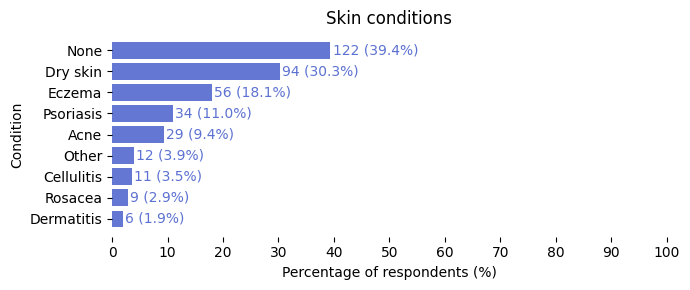

In [105]:
QUESTION_COL = "Do you suffer from any skin conditions?"

def map_skin_multilabel(raw: str):
    if raw is None:
        return ["None"]

    s = str(raw).strip()
    sn = s.casefold()

    # Detect 'None' meanings 
    none_patterns = [
        r'\bnone\b', r'\bno other\b', r'\bno\b', 
        r'\bn/?a\b', r'\bnil\b', 
    ]
    if any(re.search(p, sn) for p in none_patterns):
        return ["None"]

    categories_found = []

    # Other categories (can all co-occur)
    patterns = {
        "PID (Pelvic Inflammatory Disease)": [r'\bpid\b', r'pelvic inflammatory disease'],
        "Dry skin":    [r"\bdry skin\b"],
        "Eczema":      [r"\beczema\b"],
        "Psoriasis":   [r"\bpsoriasis\b"],
        "Cellulitis":  [r"\bcellulitis\b"],
        "Acne":        [r"\bacne\b"],
        "Rosacea":     [r"\brosacea\b"],
        "Dermatitis":  [r"\bdermatitis\b"],
        "None":        [r"\bnone\b", r"\bn/?a\b", r"\bno\b"] # avoid "not" to reduce false positives
        }

    
    for label, patterns_list in patterns.items():
        for p in patterns_list:
            if re.search(p, sn):
                categories_found.append(label)
                break  # avoid duplicate insertion

    # If nothing matched yet → assign "Other" 
    if len(categories_found) == 0:
        return ["Other"]

    return categories_found

# Plot
out = plot_single_question(
    df=Survey_endo_only,
    question_col=QUESTION_COL,
    category_func=map_skin_multilabel,
    multi_label=True, 
    na_to_category="None",
    remove_values=(),             # count everyone
    rescale_to_100=True,         # % of respondents
    sort_by="count_desc", 
    chart="barh",
    fig_title="Skin conditions",
    y_label="Condition",
)


## Healing

In [107]:
# When you have an injury (e.g. a cut in your finger) are you slow to heal or normally more fast?

In [108]:
Survey_endo_only["When you have an injury (e.g. a cut in your finger) are you slow to heal or normally more fast?"].apply(type).value_counts()

When you have an injury (e.g. a cut in your finger) are you slow to heal or normally more fast?
<class 'str'>    310
Name: count, dtype: int64

In [109]:
Survey_endo_only["When you have an injury (e.g. a cut in your finger) are you slow to heal or normally more fast?"].count()

310

In [110]:
Survey_endo_only["When you have an injury (e.g. a cut in your finger) are you slow to heal or normally more fast?"].isna().sum()

0

In [111]:
# Check responses
common_items = (
    Survey_endo_only['When you have an injury (e.g. a cut in your finger) are you slow to heal or normally more fast?']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 1].head(50))

When you have an injury (e.g. a cut in your finger) are you slow to heal or normally more fast?
heal at a normal enough rate    139
slow to heal                     96
unsure                           45
fast to heal                     30
Name: count, dtype: int64


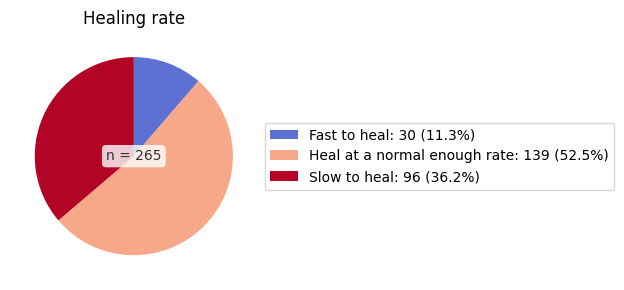

In [112]:
QUESTION_COL = "When you have an injury (e.g. a cut in your finger) are you slow to heal or normally more fast?"

# Define categories: label + color
CATEGORIES = [
    ("Fast to heal", "#5c71d1"),  # blue
    ("Heal at a normal enough rate", "#f7a889"),  # orange
    ("Slow to heal", "#b40426")  # red
]

cat_order  = [label for label, _ in CATEGORIES]
map_dict   = {label: label for label, _ in CATEGORIES}  
pie_colors = dict(CATEGORIES)

# Plot
out = plot_single_question(
    df=Survey_endo_only,
    question_col=QUESTION_COL,
    multi_label=False,
    allowed_answers=cat_order,
    map_dict=map_dict,
    include_other=False,
    remove_values=("unsure", "none", "", np.nan),  # or remove_values=()
    sort_by=None,
    category_order=cat_order,
    chart="pie",
    fig_title="Healing rate",
    y_label=None,
    pie_colors=pie_colors,
    return_data=True,
    display=True
)

## Nausea and stomach issues

In [114]:
# Do you suffer from nausea or any stomach issues related to or not related to your endometriosis

In [115]:
Survey_endo_only["Do you suffer from nausea or any stomach issues related to or not related to your endometriosis"].apply(type).value_counts()

Do you suffer from nausea or any stomach issues related to or not related to your endometriosis
<class 'str'>      245
<class 'float'>     65
Name: count, dtype: int64

In [116]:
Survey_endo_only["Do you suffer from nausea or any stomach issues related to or not related to your endometriosis"].count()

245

In [117]:
Survey_endo_only["Do you suffer from nausea or any stomach issues related to or not related to your endometriosis"].isna().sum()

65

In [118]:
# Check for any other itemas I may include 
common_items = (
    Survey_endo_only['Do you suffer from nausea or any stomach issues related to or not related to your endometriosis']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 1].head(50))

Do you suffer from nausea or any stomach issues related to or not related to your endometriosis
ibs (irritable bowel syndrome)                 166
gerd (gastro eosophageal reflux disorder)       38
nausea                                          16
sibo (small intestine bacterial overgrowth)     13
celiac disease                                  10
gluten intolerance                               4
constipation                                     3
gastritis                                        3
bowel spasms                                     2
frequent nausea                                  2
chronic constipation                             2
vomiting                                         2
diarrhea                                         2
bloating                                         2
Name: count, dtype: int64


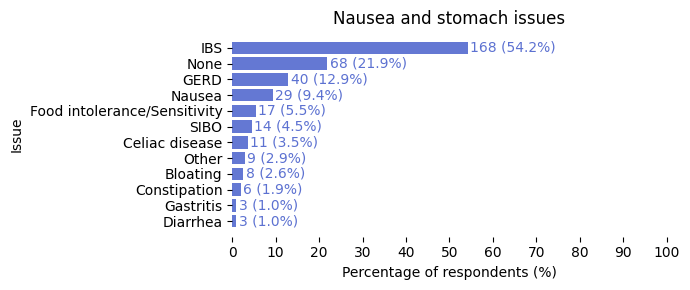

In [119]:
QUESTION_COL = "Do you suffer from nausea or any stomach issues related to or not related to your endometriosis"

# Custom category mapper 
def map_nausea_multilabel(raw: str):
    if raw is None:
        return ["None"]

    s = str(raw).strip()
    sn = s.casefold()

    # Detect 'None' meanings
    none_patterns = [
        r'\bnone\b', r'\bno other\b', r'\bno\b', 
        r'\bn/?a\b', r'\bnil\b'
    ]
    if any(re.search(p, sn) for p in none_patterns):
        return ["None"]

    categories_found = []

    # Other categories (can all co-occur) 
    patterns = {
        "IBS": [r"\bibs\b", r"\birritable bowel\b"],
        "SIBO": [r"\bsibo\b"],
        "Celiac disease": [r"\bceliac\b", r"\bcoeliac\b"],
        "GERD": [r"\bgerd\b", r"\bgastro[- ]?esophageal\b", r"\breflux\b"],
        "Nausea": [r"\bnausea\b", r"\bnauseous\b"],
        "Gastritis": [r"\bgastritis\b"],
        "Diarrhea": [r"\bdiarrh?ea\b"],                  
        "Constipation": [r"\bconstipation\b", r"\bconstipated\b"],
        "Bloating": [r"\bbloat(ing|ed)?\b"],
        "Food intolerance/Sensitivity": [r"intoleran", r"sensit"],
        "None": [r"\bnone\b", r"\bn/?a\b", r"\bno\b"]
        }

 
    for label, patterns_list in patterns.items():
        for p in patterns_list:
            if re.search(p, sn):
                categories_found.append(label)
                break  # avoid duplicate insertion

    #  If nothing matched yet → assign "Other" 
    if len(categories_found) == 0:
        return ["Other"]

    return categories_found


# Plot
out = plot_single_question(
    df=Survey_endo_only,
    question_col=QUESTION_COL,
    category_func=map_nausea_multilabel,
    multi_label=True, 
    na_to_category="None",
    remove_values=(),             # count everyone
    rescale_to_100=True,         # % of respondents
    sort_by="count_desc", 
    chart="barh",
    fig_title="Nausea and stomach issues",
    y_label="Issue",
)

In [120]:
# Did your stomach issues present before or after the onset of your endometriosis symptoms?

In [121]:
Survey_endo_only["Did your stomach issues present before or after the onset of your endometriosis symptoms?"].apply(type).value_counts()

Did your stomach issues present before or after the onset of your endometriosis symptoms?
<class 'str'>      266
<class 'float'>     44
Name: count, dtype: int64

In [122]:
Survey_endo_only["Did your stomach issues present before or after the onset of your endometriosis symptoms?"].count()

266

In [123]:
Survey_endo_only["Did your stomach issues present before or after the onset of your endometriosis symptoms?"].isna().sum()

44

In [124]:
# Check responses
common_items = (
    Survey_endo_only['Did your stomach issues present before or after the onset of your endometriosis symptoms?']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 1].head(50))

Did your stomach issues present before or after the onset of your endometriosis symptoms?
they began around the same time as my endometriosis symptoms    133
they began a while after my other endometriosis symptoms         83
they were present before                                         40
Name: count, dtype: int64


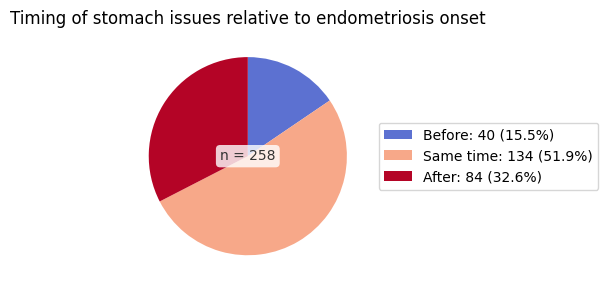

In [125]:
QUESTION_COL = "Did your stomach issues present before or after the onset of your endometriosis symptoms?"

# Single-label mapper for timing 
def map_timing_singlelabel(raw):
    """
    Map raw text into exactly one of: 'Before', 'Same time', 'After', 'None', or 'Other'.
    Designed for multi_label=False in plot_single_question.
    """
    if raw is None or (isinstance(raw, float) and np.isnan(raw)):
        return "None"

    s  = str(raw).strip()
    sn = s.casefold()

    # Handle explicit 'none' / missing-like responses early
    none_patterns = [
        r"\bnone\b", r"\bn/?a\b", r"\bnil\b",
        r"\bno\b(?!\s*(change|difference))",  # avoid 'no change' falling into None
        r"\bno other\b",
        r"\bprefer not\b", r"\bunsure\b", r"\bdon't know\b", r"\bdo not know\b"
    ]
    if any(re.search(p, sn) for p in none_patterns) or sn == "":
        return "None"

    # Normalized timing patterns (Order matters: match 'same time' before 'before/after')
    same_time_patterns = [
        r"\bat (the )?same time\b",
        r"\bsame time\b",
        r"\bsimultaneous(ly)?\b",
        r"\bconcurrent(ly)?\b",
        r"\baround the same time\b",
        r"\bco-?occurr?ed?\b",       # co-occur/occurred
        r"\bbegan (at|around) the same time\b",
        r"\bno difference in onset\b",
        r"\bno change\b",            # some people write this
        r"\bapproximately the same time\b",
        r"\babout the same time\b",
    ]
    if any(re.search(p, sn) for p in same_time_patterns):
        return "Same time"

    before_patterns = [
        r"\bbefore\b",
        r"\bprior\b",
        r"\bearlier\b",
        r"\bpreceded\b",
        r"\bstarted before\b",
        r"\bonset before\b",
        r"\bbegan before\b",
    ]
    if any(re.search(p, sn) for p in before_patterns):
        return "Before"

    after_patterns = [
        r"\bafter\b",
        r"\bafterwards?\b",
        r"\bsubsequent(ly)?\b",
        r"\bfollowed\b",
        r"\bstarted after\b",
        r"\bonset after\b",
        r"\bbegan after\b",
    ]
    if any(re.search(p, sn) for p in after_patterns):
        return "After"

    # If we saw no recognizable timing keywords
    return np.nan


# Categories & colors (fixed order for pie) 
CATEGORIES = {
    "Before":    "#5c71d1",  # blue
    "Same time": "#f7a889",  # orange
    "After":     "#b40426",  # red
}

cat_order  = ["Before", "Same time", "After"]  # pool to these 3 for the pie
map_dict   = {k: k for k in cat_order}         # identity for allowed answers
pie_colors = [CATEGORIES[k] for k in cat_order]

#  Plot 
out = plot_single_question(
    df=Survey_endo_only,
    question_col=QUESTION_COL,
    category_func=map_timing_singlelabel,  # single-label mapper
    multi_label=False,
    allowed_answers=cat_order,              # only show the pooled 3
    map_dict=map_dict,
    include_other=False,                    # hide 'Other' & 'None' from the pie
    remove_values=("unsure", "none", "Other", "", np.nan),  # also filtered by mapper
    sort_by=None,
    category_order=cat_order,
    chart="pie",
    fig_title="Timing of stomach issues relative to endometriosis onset",
    y_label=None,
    pie_colors=pie_colors,
    return_data=True,
    display=True
)

## Swollen belly

In [127]:
# Do/have you had a swollen belly, excessive bloating or fat around your tummy you couldn't get rid of using diet or exercise?

In [128]:
Survey_endo_only["Do/have you had a swollen belly, excessive bloating or fat around your tummy you couldn't get rid of using diet or exercise?"].apply(type).value_counts()

Do/have you had a swollen belly, excessive bloating or fat around your tummy you couldn't get rid of using diet or exercise?
<class 'str'>      309
<class 'float'>      1
Name: count, dtype: int64

In [129]:
Survey_endo_only["Do/have you had a swollen belly, excessive bloating or fat around your tummy you couldn't get rid of using diet or exercise?"].count()

309

In [130]:
Survey_endo_only["Do/have you had a swollen belly, excessive bloating or fat around your tummy you couldn't get rid of using diet or exercise?"].isna().sum()

1

In [131]:
# Check responses
common_items = (
    Survey_endo_only["Do/have you had a swollen belly, excessive bloating or fat around your tummy you couldn't get rid of using diet or exercise?"]
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 1].head(50))

Do/have you had a swollen belly, excessive bloating or fat around your tummy you couldn't get rid of using diet or exercise?
yes      270
no        30
maybe      9
Name: count, dtype: int64


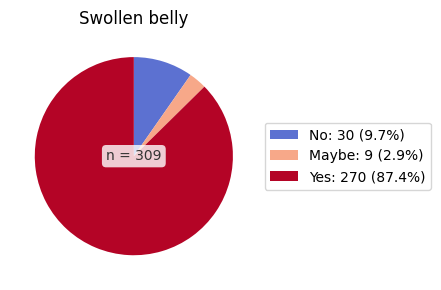

In [132]:
QUESTION_COL = "Do/have you had a swollen belly, excessive bloating or fat around your tummy you couldn't get rid of using diet or exercise?"

# Define categories: label + color
CATEGORIES = [
    ("No", "#5c71d1"),  # blue
    ("Maybe", "#f7a889"),  # orange
    ("Yes", "#b40426")  # red
]

cat_order  = [label for label, _ in CATEGORIES]
map_dict   = {label: label for label, _ in CATEGORIES}  
pie_colors = dict(CATEGORIES)

# Plot
out = plot_single_question(
    df=Survey_endo_only,
    question_col=QUESTION_COL,
    multi_label=False,
    allowed_answers=cat_order,
    map_dict=map_dict,
    include_other=False,
    remove_values=("unsure", "none", "", np.nan),  # or remove_values=()
    sort_by=None,
    category_order=cat_order,
    chart="pie",
    fig_title="Swollen belly",
    y_label=None,
    pie_colors=pie_colors,
    return_data=True,
    display=True
)

## Painful bowel movements

In [134]:
# Do/have you suffered from painful bowel movements?

In [135]:
Survey_endo_only["Do/have you suffered from painful bowel movements?"].apply(type).value_counts()

Do/have you suffered from painful bowel movements?
<class 'str'>      308
<class 'float'>      2
Name: count, dtype: int64

In [136]:
Survey_endo_only["Do/have you suffered from painful bowel movements?"].count()

308

In [137]:
Survey_endo_only["Do/have you suffered from painful bowel movements?"].isna().sum()

2

In [138]:
# Check responses
common_items = (
    Survey_endo_only["Do/have you suffered from painful bowel movements?"]
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 1].head(50))

Do/have you suffered from painful bowel movements?
yes      269
no        26
maybe     13
Name: count, dtype: int64


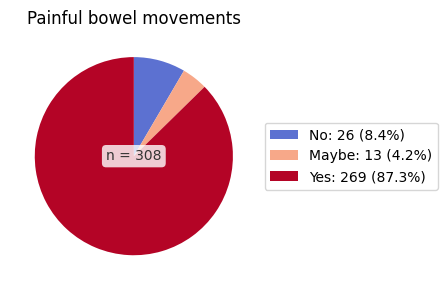

In [139]:
QUESTION_COL = "Do/have you suffered from painful bowel movements?"

# Define categories: label + color
CATEGORIES = [
    ("No", "#5c71d1"),  # blue
    ("Maybe", "#f7a889"),  # orange
    ("Yes", "#b40426")  # red
]

cat_order  = [label for label, _ in CATEGORIES]
map_dict   = {label: label for label, _ in CATEGORIES}  
pie_colors = dict(CATEGORIES)

# Plot
out = plot_single_question(
    df=Survey_endo_only,
    question_col=QUESTION_COL,
    multi_label=False,
    allowed_answers=cat_order,
    map_dict=map_dict,
    include_other=False,
    remove_values=("unsure", "none", "", np.nan),  # or remove_values=()
    sort_by=None,
    category_order=cat_order,
    chart="pie",
    fig_title="Painful bowel movements",
    y_label=None,
    pie_colors=pie_colors,
    return_data=True,
    display=True
)

## Food and symptoms

In [141]:
# Are there any types of foods or drinks that aggravate any of your symptoms?

In [142]:
Survey_endo_only["Are there any types of foods or drinks that aggravate any of your symptoms?"].apply(type).value_counts()

Are there any types of foods or drinks that aggravate any of your symptoms?
<class 'str'>      276
<class 'float'>     34
Name: count, dtype: int64

In [143]:
Survey_endo_only["Are there any types of foods or drinks that aggravate any of your symptoms?"].count()

276

In [144]:
Survey_endo_only["Are there any types of foods or drinks that aggravate any of your symptoms?"].isna().sum()

34

In [145]:
# Check for any other itemas I may include 
common_items = (
    Survey_endo_only['Are there any types of foods or drinks that aggravate any of your symptoms?']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 1].head(50))

Are there any types of foods or drinks that aggravate any of your symptoms?
alcohol            180
dairy              147
processed foods    145
gluten             121
caffeine            88
red meat            56
sugar                6
not sure             3
onions               3
garlic               3
eggs                 3
white bread          2
onion                2
tomatoes             2
peppers              2
unsure               2
Name: count, dtype: int64


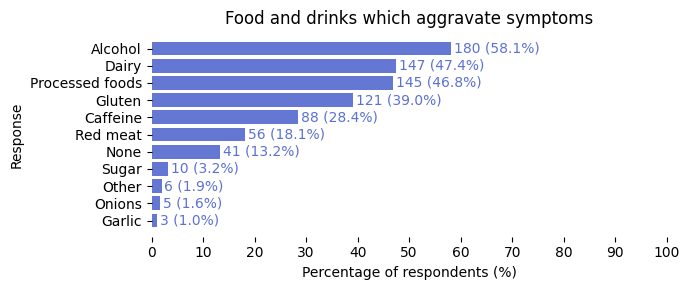

In [146]:
QUESTION_COL = "Are there any types of foods or drinks that aggravate any of your symptoms?"

# Custom category mapper  
def map_food_multilabel(raw: str):
    if raw is None:
        return ["None"]

    s = str(raw).strip()
    sn = s.casefold()

    # Detect 'None' meanings 
    none_patterns = [
        r'\bnone\b', r'\bno other\b', r'\bno\b', 
        r'\bn/?a\b', r'\bnil\b'
    ]
    if any(re.search(p, sn) for p in none_patterns):
        return ["None"]

    categories_found = []

    # Other categories (can all co-occur) 
    patterns = {
        "Dairy": [r"\bdairy\b", r"\bmilk\b", r"\bcheese\b", r"\byogh?urt\b"],
        "Red meat": [r"\bred meat\b", r"\bbeef\b", r"\blamb\b"],
        "Gluten": [r"\bgluten\b", r"\bwheat\b"],
        "Processed foods": [r"\bprocessed\b", r"\bfast food\b", r"\bpackaged\b", r"\bjunk\b"],
        "Caffeine": [r"\bcaffeine\b", r"\bcoffee\b", r"\bcaf[eé]\b"],
        "Alcohol": [r"\balcohol\b", r"\bwine\b", r"\bbeer\b", r"\bspirits?\b"],
        "Sugar": [r"\bsugar\b", r"\bsugary\b"],
        "Garlic": [r"\bgarlic\b"],
        "Onions": [r"\bonions?\b"],   
        "None": [
            r"\bnone\b",
            r"\bn/?a\b",
            r"\bnil\b",
            r"\bno\b(?!\s*(change|difference))",  # still safe
            r"\bnot sure\b",
            r"\bunsure\b",
            r"\bi('?m| am)? not sure\b",
            r"\bdon'?t know\b",
            r"\bdo not know\b",
            r"\bprefer not\b"
        ]
        }
 
    for label, patterns_list in patterns.items():
        for p in patterns_list:
            if re.search(p, sn):
                categories_found.append(label)
                break  # avoid duplicate insertion

    #  If nothing matched yet → assign "Other" 
    if len(categories_found) == 0:
        return ["Other"]

    return categories_found


# Plot
out = plot_single_question(
    df=Survey_endo_only,
    question_col=QUESTION_COL,
    category_func=map_food_multilabel,
    multi_label=True, 
    na_to_category="None",
    remove_values=(),             # count everyone
    rescale_to_100=True,         # % of respondents
    sort_by="count_desc", 
    chart="barh",
    fig_title="Food and drinks which aggravate symptoms",
    y_label="Response",
)

## Appetite

In [148]:
# Have you noticed any change in your appetite as your endometriosis has progressed

In [149]:
Survey_endo_only["Have you noticed any change in your appetite as your endometriosis has progressed"].apply(type).value_counts()

Have you noticed any change in your appetite as your endometriosis has progressed
<class 'str'>      306
<class 'float'>      4
Name: count, dtype: int64

In [150]:
Survey_endo_only["Have you noticed any change in your appetite as your endometriosis has progressed"].count()

306

In [151]:
Survey_endo_only["Have you noticed any change in your appetite as your endometriosis has progressed"].isna().sum()

4

In [152]:
# Check for any other itemas I may include 
common_items = (
    Survey_endo_only['Have you noticed any change in your appetite as your endometriosis has progressed']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 1].head(50))

Have you noticed any change in your appetite as your endometriosis has progressed
yes                                   156
my appetite has decreased              87
no                                     82
i have not noticed any change          82
my appetite has increased              69
unsure                                 38
increases                               3
increase some days decrease others      2
Name: count, dtype: int64


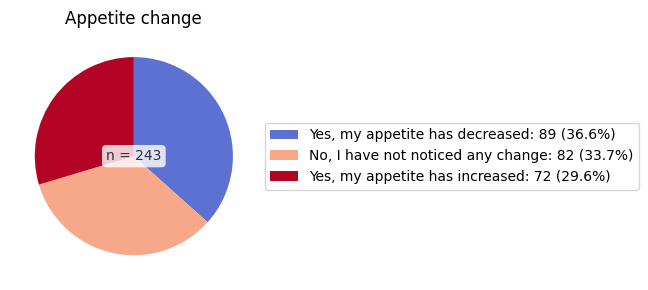

In [153]:
QUESTION_COL = "Have you noticed any change in your appetite as your endometriosis has progressed"

# Single-label mapper for timing
def map_appetite_singlelabel(raw):
    """
    Maps free text to one of three categories:
      - "Yes, my appetite has decreased"
      - "No, I have not noticed any change"
      - "Yes, my appetite has increased"

    Excludes (returns np.nan) if a response contains signals for BOTH decreased and increased,
    or if 'no change' appears alongside either decreased or increased.
    """

    if raw is None or (isinstance(raw, float) and np.isnan(raw)):
        return np.nan  # Return NaN so it's excluded cleanly

    s  = str(raw).strip()
    sn = s.casefold()

    decreased_patterns = [
        r"\bdecreas(e|ed|es|ing)?\b",          # decrease / decreased / decreases / decreasing
        r"\breduc(e|ed|es|ing|tion)\b",        # reduce / reduced / reduces / reducing / reduction
        r"\blower\b",                          # lower
        r"\bloss\b",                           # loss
        r"\bloss of appetite\b",               # loss of appetite
        r"\bappetite\s*loss\b",                # appetite loss
        r"\blost appetite\b",                  # lost appetite
        r"\bpoor appetite\b",                  # poor appetite
    ]

    same_patterns = [
        r"\bsame\b",
        r"\bany change\b",
        r"\bsame as before\b",
        r"\bthe same\b",
        r"\bstayed the same\b",
        r"\bremained the same\b",
        r"\bno difference\b",
        r"\bno change\b",
        r"\bunchanged\b",
        r"\bno real change\b",
        r"\bnot changed\b",
        r"\bunchanging\b",
        r"\bsteady\b",
        r"\bstable\b",
    ]

    increased_patterns = [
        # Core "increase" verb family
        r"\bincreas(e|ed|es|ing)\b",

        # Appetite-specific improvements
        r"\bimproved appetite\b",
        r"\bbetter appetite\b",
        r"\bappetite improved\b",
        r"\bimprov(ed|ement)\b.*\bappetite\b",
        r"\bappetite\b.*\bincreas(e|ed|ing)\b",

        # Hunger phrasing
        r"\bhungr(ier|y)\b",            # hungry, hungrier
        r"\bincreased hunger\b",
        r"\bmore hungry\b",
        r"\bravenous\b",
        r"\bgreater hunger\b",

        # “More” intake/portion/quantity phrasing
        r"\beating more\b",
        r"\bmore food\b",
        r"\bmore often\b",
        r"\blarger portions?\b",
        r"\bbigger portions?\b",
        r"\bhigher (intake|consumption)\b",
        r"\bgreater (intake|consumption)\b",

        # General synonyms for “higher”
        r"\bhigher\b",
        r"\bgreater\b",
        r"\belevated\b",
        r"\bheightened\b",

        # Appetite-centric “more” phrasing
        r"\bmore appetite\b",
        r"\bappetite (got|is|feels)?\s*better\b",
    ]

    dec_hit = any(re.search(p, sn) for p in decreased_patterns)
    inc_hit = any(re.search(p, sn) for p in increased_patterns)
    same_hit = any(re.search(p, sn) for p in same_patterns)

    # If both decreased and increased are present, exclude as ambiguous
    if dec_hit and inc_hit:
        return np.nan

    # If "no change/same" appears with either dec or inc, exclude as contradictory
    if same_hit and (dec_hit or inc_hit):
        return np.nan

    # Otherwise map to the single clear category
    if dec_hit:
        return "Yes, my appetite has decreased"

    if same_hit:
        return "No, I have not noticed any change"

    if inc_hit:
        return "Yes, my appetite has increased"

    # If no recognizable keywords, exclude from the pie
    return np.nan

#  Categories & colors (fixed order for pie) 
CATEGORIES = {
    "Yes, my appetite has decreased":    "#5c71d1",  # blue
    "No, I have not noticed any change": "#f7a889",  # orange
    "Yes, my appetite has increased":     "#b40426",  # red
}

cat_order  = ["Yes, my appetite has decreased", "No, I have not noticed any change", "Yes, my appetite has increased"]  # pool to these 3 for the pie
map_dict   = {k: k for k in cat_order}         # identity for allowed answers
pie_colors = [CATEGORIES[k] for k in cat_order]

# ----- Plot -----
out = plot_single_question(
    df=Survey_endo_only,
    question_col=QUESTION_COL,
    category_func=map_appetite_singlelabel,  # single-label mapper
    multi_label=False,
    allowed_answers=cat_order,              # only show the pooled 3
    map_dict=map_dict,
    include_other=False,                    # hide 'Other' & 'None' from the pie
    remove_values=("unsure", "None", "Other", "", np.nan),  # also filtered by mapper
    sort_by=None,
    category_order=cat_order,
    chart="pie",
    fig_title="Appetite change",
    y_label=None,
    pie_colors=pie_colors,
    return_data=True,
    display=True
)

## Issues with weight

In [155]:
# Are you or have you ever suffered from issues with your weight?

In [156]:
Survey_endo_only["Are you or have you ever suffered from issues with your weight?"].apply(type).value_counts()

Are you or have you ever suffered from issues with your weight?
<class 'str'>    310
Name: count, dtype: int64

In [157]:
Survey_endo_only["Are you or have you ever suffered from issues with your weight?"].count()

310

In [158]:
Survey_endo_only["Are you or have you ever suffered from issues with your weight?"].isna().sum()

0

In [159]:
# Check for any other itemas I may include 
common_items = (
    Survey_endo_only['Are you or have you ever suffered from issues with your weight?']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 1].head(50))

Are you or have you ever suffered from issues with your weight?
yes                                     197
i am/have been overweight               159
no                                      113
i am usually around a healthy weight    113
i am/have been underweight               38
Name: count, dtype: int64


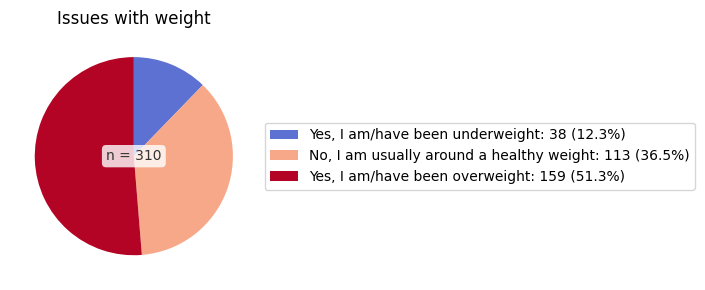

In [160]:
QUESTION_COL = "Are you or have you ever suffered from issues with your weight?"

# Define categories: label + color
CATEGORIES = [
    ("Yes, I am/have been underweight", "#5c71d1"),  # blue
    ("No, I am usually around a healthy weight", "#f7a889"),  # orange
    ("Yes, I am/have been overweight", "#b40426")  # red
]

cat_order  = [label for label, _ in CATEGORIES]
map_dict   = {label: label for label, _ in CATEGORIES}  
pie_colors = dict(CATEGORIES)

# Plot
out = plot_single_question(
    df=Survey_endo_only,
    question_col=QUESTION_COL,
    multi_label=False,
    allowed_answers=cat_order,
    map_dict=map_dict,
    include_other=False,
    remove_values=("unsure", "none", "", np.nan),  # or remove_values=()
    sort_by=None,
    category_order=cat_order,
    chart="pie",
    fig_title="Issues with weight",
    y_label=None,
    pie_colors=pie_colors,
    return_data=True,
    display=True
)

# Correlation appetite vs weight

In [162]:
# Correlation
# Have you noticed any change in your appetite as your endometriosis has progressed
# Are you or have you ever suffered from issues with your weight?
# Delete below when no needed and keep the function plus application

# Application: Correlation of weight vs appetite

Contingency table (counts):
           Yes - underweight  No  Yes - overweight
Increased                  6  14                52
No change                  7  42                33
Decreased                 18  33                38


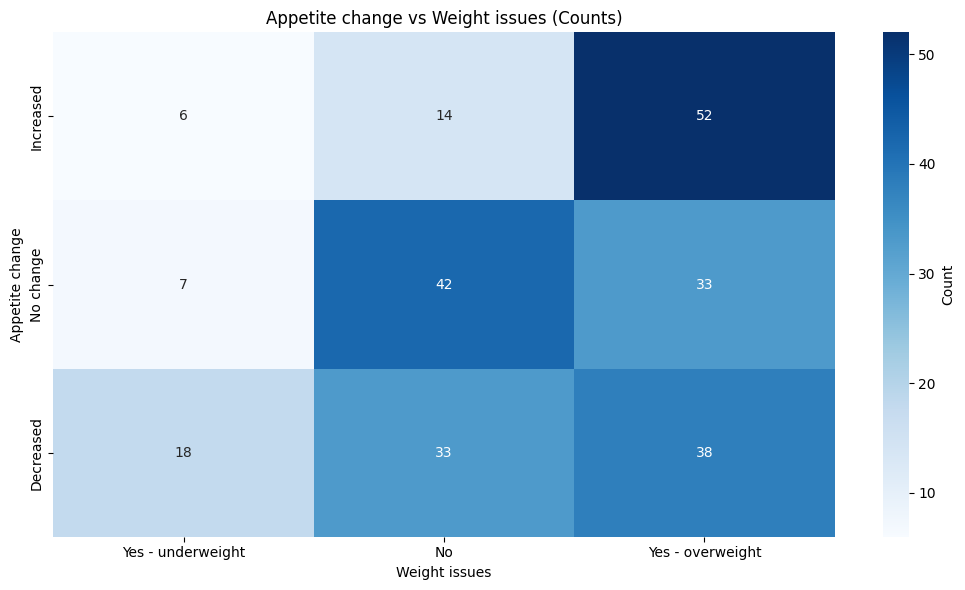

In [164]:
# Correlation of weight vs appetite
# Specific mapping functions
def map_appetite_singlelabel(raw):
    if raw is None or (isinstance(raw, float) and np.isnan(raw)):
        return np.nan  # Return NaN so it's excluded cleanly
    s  = str(raw).strip()
    sn = s.casefold()

    decreased_patterns = [
        r"\bdecreas(e|ed|es|ing)?\b",
        r"\breduc(e|ed|es|ing|tion)\b",
        r"\blower\b",
        r"\bloss\b",
        r"\bloss of appetite\b",
        r"\bappetite\s*loss\b",
        r"\blost appetite\b",
        r"\bpoor appetite\b",
    ]
    same_patterns = [
        r"\bsame\b",
        r"\bany change\b",
        r"\bsame as before\b",
        r"\bthe same\b",
        r"\bstayed the same\b",
        r"\bremained the same\b",
        r"\bno difference\b",
        r"\bno change\b",
        r"\bunchanged\b",
        r"\bno real change\b",
        r"\bnot changed\b",
        r"\bunchanging\b",
        r"\bsteady\b",
        r"\bstable\b",
    ]
    increased_patterns = [
        r"\bincreas(e|ed|es|ing)\b",
        r"\bimproved appetite\b",
        r"\bbetter appetite\b",
        r"\bappetite improved\b",
        r"\bimprov(ed|ement)\b.*\bappetite\b",
        r"\bappetite\b.*\bincreas(e|ed|ing)\b",
        r"\bhungr(ier|y)\b",
        r"\bincreased hunger\b",
        r"\bmore hungry\b",
        r"\bravenous\b",
        r"\bgreater hunger\b",
        r"\beating more\b",
        r"\bmore food\b",
        r"\bmore often\b",
        r"\blarger portions?\b",
        r"\bbigger portions?\b",
        r"\bhigher (intake|consumption)\b",
        r"\bgreater (intake|consumption)\b",
        r"\bhigher\b",
        r"\bgreater\b",
        r"\belevated\b",
        r"\bheightened\b",
        r"\bmore appetite\b",
        r"\bappetite (got|is|feels)?\s*better\b",
    ]

    dec_hit  = any(re.search(p, sn) for p in decreased_patterns)
    inc_hit  = any(re.search(p, sn) for p in increased_patterns)
    same_hit = any(re.search(p, sn) for p in same_patterns)

    if dec_hit and inc_hit:
        return np.nan
    if same_hit and (dec_hit or inc_hit):
        return np.nan

    if dec_hit:
        return "Yes, my appetite has decreased"
    if same_hit:
        return "No, I have not noticed any change"
    if inc_hit:
        return "Yes, my appetite has increased"
    return np.nan


WEIGHT_ALLOWED = [
    "Yes, I am/have been underweight",
    "No, I am usually around a healthy weight",
    "Yes, I am/have been overweight",
]

def map_weight_three(raw):
    if raw is None or (isinstance(raw, float) and np.isnan(raw)):
        return np.nan
    s = str(raw).strip()
    if s in WEIGHT_ALLOWED:
        return s
    sn = s.casefold()
    non_info = {"n/a", "na", "prefer not to say", "unsure", "unknown", "", "not sure", "prefer not to answer"}
    if sn in non_info:
        return np.nan
    under = any(k in sn for k in ["underweight", "under weight", "low bmi", "bmi low", "too thin", "under wt"])
    over  = any(k in sn for k in ["overweight", "obese", "obesity", "high bmi", "bmi high"])
    healthy_no = (
        "healthy weight" in sn or sn == "no" or
        ("no" in sn and ("issue" in sn or "problem" in sn) and "weight" in sn) or
        ("around a healthy weight" in sn) or ("normal weight" in sn)
    )
    if (under and over) or (healthy_no and (under or over)):
        return np.nan
    if under:
        return "Yes, I am/have been underweight"
    if over:
        return "Yes, I am/have been overweight"
    if healthy_no:
        return "No, I am usually around a healthy weight"
    return np.nan

# Short labels & order 
appetite_short_map = {
    "Yes, my appetite has decreased":    "Decreased",
    "No, I have not noticed any change": "No change",
    "Yes, my appetite has increased":    "Increased",
}
weight_short_map = {
    "Yes, I am/have been underweight": "Yes - underweight",
    "No, I am usually around a healthy weight": "No",
    "Yes, I am/have been overweight": "Yes - overweight",
}

row_order = ["Increased", "No change", "Decreased"]
col_order = ["Yes - underweight", "No", "Yes - overweight"]

# Plot
appetite_col = "Have you noticed any change in your appetite as your endometriosis has progressed"
weight_col   = "Are you or have you ever suffered from issues with your weight?"

result = two_way_assoc_with_heatmaps(
    df=Survey_endo_only,
    left_col=appetite_col,                       # Self (rows)
    right_col=weight_col,                      # Family (columns)
    left_map_func=map_appetite_singlelabel,
    right_map_func=map_weight_three,
    left_short_map=appetite_short_map,
    right_short_map=weight_short_map,
    row_order=row_order,
    col_order=col_order,
    title_prefix="Appetite change vs Weight issues",
    left_axis_label="Appetite change",
    right_axis_label="Weight issues",
    percent_cmap="Blues",
    or_cmap="coolwarm",
    alpha=0.05,
    show_plots=True,
    multi_label_left=True,
    multi_label_right=True,
    rows_from="left",                     

)

In [165]:
# If yes, was this before or after your endometriosis symptoms began?

In [166]:
Survey_endo_only["If yes, was this before or after your endometriosis symptoms began?"].apply(type).value_counts()

If yes, was this before or after your endometriosis symptoms began?
<class 'str'>      204
<class 'float'>    106
Name: count, dtype: int64

In [167]:
Survey_endo_only["If yes, was this before or after your endometriosis symptoms began?"].count()

204

In [168]:
Survey_endo_only["If yes, was this before or after your endometriosis symptoms began?"].isna().sum()

106

In [169]:
# Check for any other itemas I may include 
common_items = (
    Survey_endo_only['If yes, was this before or after your endometriosis symptoms began?']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 1].head(50))

If yes, was this before or after your endometriosis symptoms began?
i only became overweight after my endometriosis symptoms began     119
i was overweight before my endometriosis symptoms began             28
i was underweight before my endometriosis symptoms began            22
i have always been overweight                                       15
i only became underweight after my endometriosis symptoms began     14
i have always been underweight                                       6
Name: count, dtype: int64


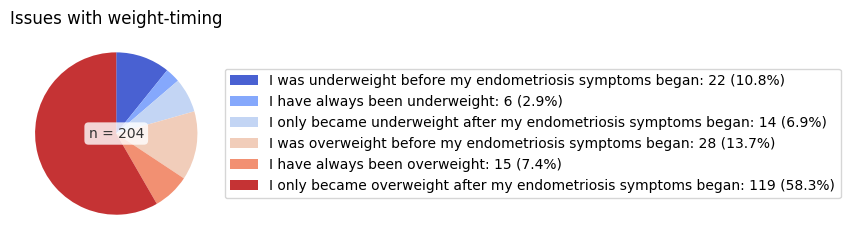

In [170]:
QUESTION_COL = "If yes, was this before or after your endometriosis symptoms began?"

# Define categories: label + color
CATEGORIES = [
    "I was underweight before my endometriosis symptoms began",
    "I have always been underweight",
    "I only became underweight after my endometriosis symptoms began",
    "I was overweight before my endometriosis symptoms began", 
    "I have always been overweight", 
    "I only became overweight after my endometriosis symptoms began",
]

cat_order  = CATEGORIES
map_dict   = {label: label for label in CATEGORIES}  

# Plot
out = plot_single_question(
    df=Survey_endo_only,
    question_col=QUESTION_COL,
    multi_label=False,
    allowed_answers=cat_order,
    map_dict=map_dict,
    include_other=False,
    remove_values=("unsure", "none", "", np.nan),  # or remove_values=()
    sort_by=None,
    category_order=cat_order,
    chart="pie",
    fig_title="Issues with weight-timing",
    y_label=None,
    pie_cmap="coolwarm",            # ignored when pie_colors provided (pie_colors=pie_colors)
    return_data=True,
    display=True
)

## Fatigue and tiredness

In [172]:
# Do you suffer from fatigue or tiredness?

In [173]:
Survey_endo_only["Do you suffer from fatigue or tiredness?"].apply(type).value_counts()

Do you suffer from fatigue or tiredness?
<class 'str'>      308
<class 'float'>      2
Name: count, dtype: int64

In [174]:
Survey_endo_only["Do you suffer from fatigue or tiredness?"].count()

308

In [175]:
Survey_endo_only["Do you suffer from fatigue or tiredness?"].isna().sum()

2

In [176]:
# Check responses
common_items = (
    Survey_endo_only['Do you suffer from fatigue or tiredness?']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 0].head(50))

Do you suffer from fatigue or tiredness?
yes    297
no      11
Name: count, dtype: int64


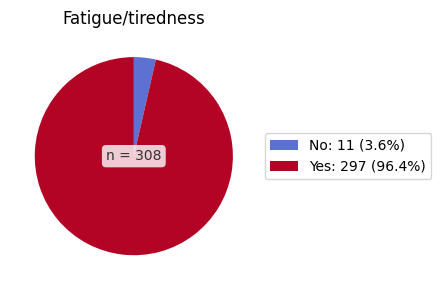

In [177]:
QUESTION_COL = "Do you suffer from fatigue or tiredness?"

# Define categories: label + color
CATEGORIES = [
    ("No", "#5c71d1"),  # blue
    ("Yes", "#b40426")  # red
]

cat_order  = [label for label, _ in CATEGORIES]
map_dict   = {label: label for label, _ in CATEGORIES}  
pie_colors = dict(CATEGORIES)

# Plot
out = plot_single_question(
    df=Survey_endo_only,
    question_col=QUESTION_COL,
    multi_label=False,
    allowed_answers=cat_order,
    map_dict=map_dict,
    include_other=False,
    remove_values=("unsure", "none", "", np.nan),  # or remove_values=()
    sort_by=None,
    category_order=cat_order,
    chart="pie",
    fig_title="Fatigue/tiredness",
    y_label=None,
    pie_colors=pie_colors,
    return_data=True,
    display=True
)

In [178]:
# If yes, at what age did you begin to suffer from this fatigue/tiredness?

In [179]:
Survey_endo_only["If yes, at what age did you begin to suffer from this fatigue/tiredness?"].apply(type).value_counts()

If yes, at what age did you begin to suffer from this fatigue/tiredness?
<class 'float'>    188
<class 'int'>       89
<class 'str'>       33
Name: count, dtype: int64

In [180]:
Survey_endo_only["If yes, at what age did you begin to suffer from this fatigue/tiredness?"].count()

122

In [181]:
Survey_endo_only["If yes, at what age did you begin to suffer from this fatigue/tiredness?"].isna().sum()

188

In [182]:
# Check responses
common_items = (
    Survey_endo_only['If yes, at what age did you begin to suffer from this fatigue/tiredness?']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 1].head(50))

If yes, at what age did you begin to suffer from this fatigue/tiredness?
nan         89
teens        2
not sure     2
20’s         2
Name: count, dtype: int64


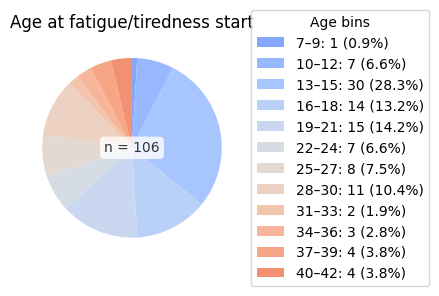

In [183]:
QUESTION_COL = "If yes, at what age did you begin to suffer from this fatigue/tiredness?"

bin_tuples = [(0, 3, "0–3")] + [(a, a+2, f"{a}–{a+2}") for a in range(4, 100, 3)]
cat_order_asc = [lab for (_, _, lab) in bin_tuples]

out_age_numeric = plot_single_question(
    df=Survey_endo_only,
    question_col=QUESTION_COL,
    numeric=True,
    number_pattern=r"\d+",
    number_extract="first",
    numeric_range=(5, 129),
    numeric_bins=bin_tuples,
    rescale_to_100=True,
    remove_values=(),
    sort_by=None,
    category_order=cat_order_asc,
    chart="pie",
    fig_title="Age at fatigue/tiredness start",
    y_label="Age bins",
    figsize=(8,3),
    pie_colors=PALETTE_0_48,
    pie_use_base_color=False,
    pie_cmap="coolwarm",
    pie_cmap_reverse=False,
    pie_distinct_subset=False,
    return_data=True,
    display=True
)

## Mental health issues

In [185]:
# Do/have you ever suffered from mental health problems?

In [186]:
Survey_endo_only["Do/have you ever suffered from mental health problems?"].apply(type).value_counts()

Do/have you ever suffered from mental health problems?
<class 'str'>      301
<class 'float'>      9
Name: count, dtype: int64

In [187]:
Survey_endo_only["Do/have you ever suffered from mental health problems?"].count()

301

In [188]:
Survey_endo_only["Do/have you ever suffered from mental health problems?"].isna().sum()

9

In [189]:
# Check for any other itemas I may include 
common_items = (
    Survey_endo_only['Do/have you ever suffered from mental health problems?']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 1].head(50))

Do/have you ever suffered from mental health problems?
anxiety                                                 212
depression                                              159
no                                                       52
i have not suffered from any mental health disorders     52
ptsd (post-traumatic stress disorder)                    49
easting disorders                                        35
adhd                                                      6
ocd                                                       6
pmdd                                                      4
bipolar disorder                                          3
low mood                                                  2
pms                                                       2
borderline personality disorder                           2
bpd                                                       2
Name: count, dtype: int64


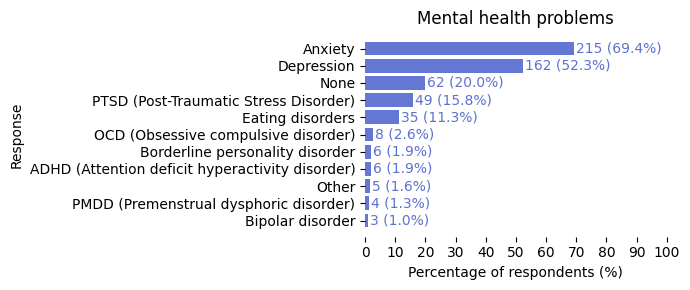

In [190]:
QUESTION_COL = "Do/have you ever suffered from mental health problems?"

# Map categories
def map_mental_multilabel(raw: str):
    if raw is None:
        return ["None"]

    s = str(raw).strip()
    sn = s.casefold()

    # Detect 'None' meanings 
    none_patterns = [
        r'\bnone\b', r'\bno other\b', r'\bno\b', 
        r'\bn/?a\b', r'\bnil\b'
    ]
    if any(re.search(p, sn) for p in none_patterns):
        return ["None"]

    categories_found = []

    # Other categories (can all co-occur)
    patterns = {
        "Depression": [r"\bdepress(ion|ed)?\b", r"\blow mood\b"], 
        "Anxiety": [r"\banxiet(y|ies)\b", r"\banxious\b"],
        "Bipolar disorder": [r"\bbipolar\b"],  # avoid 'BPD' here (used for Borderline PD)
        "Schizophrenia": [r"\bschizo(phrenia|affective)?\b"],
        "Eating disorders": [r"\beating disorder(s)?\b", r"\banorex(ia|ic)\b", r"\bbulim(ia|ic)\b", r"\beasting disorder(s)?\b"],
        "PTSD (Post-Traumatic Stress Disorder)": [r"\bptsd\b", r"\bpost[- ]traumatic stress\b"],
        "Borderline personality disorder": [r"\bborderline personality\b", r"\bbpd\b"],
        "ADHD (Attention deficit hyperactivity disorder)": [r"\badhd\b", r"\battention[- ]deficit\b"],
        "PMDD (Premenstrual dysphoric disorder)": [r"\bpmdd\b", r"\bpremenstrual dysphoric\b"],
        "OCD (Obsessive compulsive disorder)": [r"\bocd\b", r"\bobsessive[- ]compulsive\b"],
        "None": [r"\bnone\b", r"\bn/?a\b", r"\bno\b"]
        }
 
    for label, patterns_list in patterns.items():
        for p in patterns_list:
            if re.search(p, sn):
                categories_found.append(label)
                break  # avoid duplicate insertion

    # If nothing matched yet → assign "Other" 
    if len(categories_found) == 0:
        return ["Other"]

    return categories_found


# Plot
out = plot_single_question(
    df=Survey_endo_only,
    question_col=QUESTION_COL,
    category_func=map_mental_multilabel,
    multi_label=True, 
    na_to_category="None",
    remove_values=(),             # count everyone
    rescale_to_100=True,         # % of respondents
    sort_by="count_desc", 
    chart="barh",
    fig_title="Mental health problems",
    y_label="Response",
)

In [191]:
# Timing of mental conditions

In [192]:
Survey_endo_only["If yes, did you suffer from any of these conditions before your endometriosis symptoms began?"].apply(type).value_counts()

If yes, did you suffer from any of these conditions before your endometriosis symptoms began?
<class 'str'>      258
<class 'float'>     52
Name: count, dtype: int64

In [193]:
Survey_endo_only["If yes, did you suffer from any of these conditions before your endometriosis symptoms began?"].count()

258

In [194]:
Survey_endo_only["If yes, did you suffer from any of these conditions before your endometriosis symptoms began?"].isna().sum()

52

In [195]:
# Check responses
common_items = (
    Survey_endo_only['If yes, did you suffer from any of these conditions before your endometriosis symptoms began?']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 1].head(50))

If yes, did you suffer from any of these conditions before your endometriosis symptoms began?
no         134
yes         86
maybe       30
anxiety      2
Name: count, dtype: int64


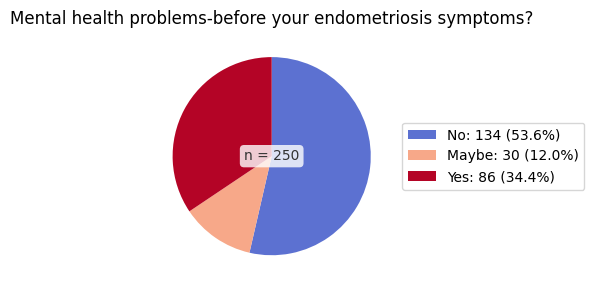

In [196]:
QUESTION_COL = "If yes, did you suffer from any of these conditions before your endometriosis symptoms began?"

# Define categories: label + color
CATEGORIES = [
    ("No", "#5c71d1"),  # blue
    ("Maybe", "#f7a889"),  # orange
    ("Yes", "#b40426")  # red
]
cat_order  = [label for label, _ in CATEGORIES]
map_dict   = {label: label for label, _ in CATEGORIES}  
pie_colors = dict(CATEGORIES)

# Plot
out = plot_single_question(
    df=Survey_endo_only,
    question_col=QUESTION_COL,
    multi_label=False,
    allowed_answers=cat_order,
    map_dict=map_dict,
    include_other=False,
    remove_values=("other", "none", "", np.nan),  # or remove_values=()
    sort_by=None,
    category_order=cat_order,
    chart="pie",
    fig_title="Mental health problems-before your endometriosis symptoms?",
    y_label=None,
    pie_colors=pie_colors,
    return_data=True,
    display=True
)

## Neurodiversity

In [198]:
# Are you neurodivergent

In [199]:
Survey_endo_only["Are you neurodivergent"].apply(type).value_counts()

Are you neurodivergent
<class 'float'>    190
<class 'str'>      120
Name: count, dtype: int64

In [200]:
Survey_endo_only["Are you neurodivergent"].apply(type).count()

310

In [201]:
Survey_endo_only["Are you neurodivergent"].apply(type).isna().sum()

0

In [202]:
# Check for responses
common_items = (
    Survey_endo_only['Are you neurodivergent']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 1].head(50))

Are you neurodivergent
no                                75
neurotypical                      75
yes                               26
adhd                              15
dyslexia                           9
dyscalculia                        4
autism                             3
undiagnosed but suspected adhd     2
suspected adhd                     2
Name: count, dtype: int64


In [203]:
# many other responses have either multiple conditions or they are suspected, so the easier here is to go with the defined categories and pool the rest to other
# not include Nan

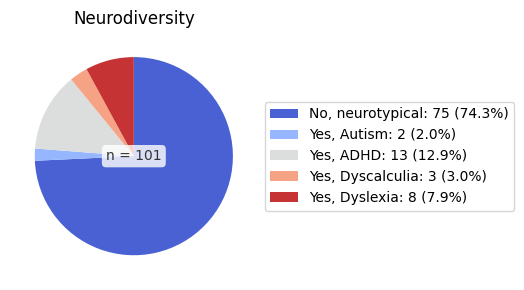

In [204]:
QUESTION_COL = "Are you neurodivergent"

# Define categories: label + color
CATEGORIES = [
    ("No, neurotypical", "green"),
    ("Yes, Autism", "lightcoral"),
    ("Yes, ADHD", "indianred"),
    ("Yes, Dyscalculia", "brown"),
    ("Yes, Dyslexia", "firebrick"),
    ("Yes, Dysgraphia", "maroon"),
    ("Other", "#1f77b4"),
]

cat_order  = [label for label, _ in CATEGORIES]
map_dict   = {label: label for label, _ in CATEGORIES}  
pie_colors = dict(CATEGORIES)

# Plot
out = plot_single_question(
    df=Survey_endo_only,
    question_col=QUESTION_COL,
    multi_label=False,
    allowed_answers=cat_order,
    map_dict=map_dict,
    include_other=False,
    remove_values=("unsure", "none", "", np.nan),  # or remove_values=()
    sort_by=None,
    category_order=cat_order,
    chart="pie",
    fig_title="Neurodiversity",
    y_label=None,
    pie_cmap="coolwarm",            
    return_data=True,
    display=True
)

## Hypermobility

In [206]:
# Would you describe yourself as hyper mobile (your joints ca move beyond the normal range of motion)?

In [207]:
Survey_endo_only["Would you describe yourself as hyper mobile (your joints ca move beyond the normal range of motion)?"].apply(type).value_counts()

Would you describe yourself as hyper mobile (your joints ca move beyond the normal range of motion)?
<class 'float'>    182
<class 'str'>      128
Name: count, dtype: int64

In [208]:
Survey_endo_only["Would you describe yourself as hyper mobile (your joints ca move beyond the normal range of motion)?"].count()

128

In [209]:
Survey_endo_only["Would you describe yourself as hyper mobile (your joints ca move beyond the normal range of motion)?"].isna().sum()

182

In [210]:
# Check responses
common_items = (
    Survey_endo_only['Would you describe yourself as hyper mobile (your joints ca move beyond the normal range of motion)?']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 0].head(50))

Would you describe yourself as hyper mobile (your joints ca move beyond the normal range of motion)?
no       80
yes      34
maybe    14
Name: count, dtype: int64


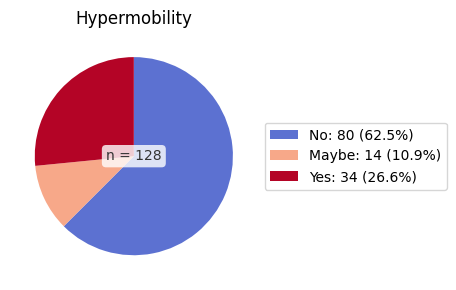

In [211]:
QUESTION_COL = "Would you describe yourself as hyper mobile (your joints ca move beyond the normal range of motion)?"

# Define categories : label + color
CATEGORIES = [
    ("No", "#5c71d1"),  # blue
    ("Maybe", "#f7a889"),  # orange
    ("Yes", "#b40426")  # red
]

cat_order  = [label for label, _ in CATEGORIES]
map_dict   = {label: label for label, _ in CATEGORIES}  
pie_colors = dict(CATEGORIES)

# Plot
out = plot_single_question(
    df=Survey_endo_only,
    question_col=QUESTION_COL,
    multi_label=False,
    allowed_answers=cat_order,
    map_dict=map_dict,
    include_other=False,
    remove_values=("other", "none", "", np.nan),  
    sort_by=None,
    category_order=cat_order,
    chart="pie",
    fig_title="Hypermobility",
    y_label=None,
    pie_colors=pie_colors,
    return_data=True,
    display=True
)

## Environment

## Birth

In [214]:
# Birth order

In [215]:
Survey_endo_only["In which order were you born in your family?"].apply(type).value_counts()

In which order were you born in your family?
<class 'str'>    310
Name: count, dtype: int64

In [216]:
Survey_endo_only["In which order were you born in your family?"].count()

310

In [217]:
Survey_endo_only["In which order were you born in your family?"].isna().sum()

0

In [218]:
# Check for responses
common_items = (
    Survey_endo_only['In which order were you born in your family?']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 0].head(50))

In which order were you born in your family?
1st                                                                                    125
2nd                                                                                     86
3rd                                                                                     52
4th                                                                                     22
5th                                                                                     10
only child                                                                               3
6th                                                                                      3
7th                                                                                      2
9th                                                                                      2
twin                                                                                     1
i am an only child but my mother had 2 miscar

In [219]:
# only keep main categories, the rest are rather complicated and not exact (only but miscariages, only girl and what about the rest etc..)
# only child, 1st - 10th

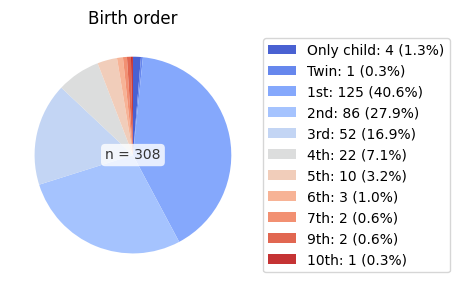

In [220]:
QUESTION_COL = "In which order were you born in your family?"

# Categorization function
def categorize_response(x: str) -> str:
    if x is None:
        return None
    s = str(x).strip().lower()

    if "only child" in s:
        return "Only child"

    if "twin" in s:
        return "Twin"
        
    # Normalize ordinals 1..10
    m = re.match(r'^\s*(10|[1-9])\s*(?:st|nd|rd|th)?\s*$', s, flags=re.I)
    if m:
        n = int(m.group(1))
        if n == 1: return "1st"
        if n == 2: return "2nd"
        if n == 3: return "3rd"
        return f"{n}th"

    # If not matching anything, drop it from the plot
    return None

# Apply categorizer to the dataset
standardized = Survey_endo_only[QUESTION_COL].apply(categorize_response)

# Allowed categories only — NO “Other”
cat_order = ["Only child", "Twin", "1st", "2nd", "3rd", "4th", "5th",
             "6th", "7th", "8th", "9th", "10th"]

map_dict = {label: label for label in cat_order}

# Plot 
out = plot_single_question(
    df=Survey_endo_only.assign(**{QUESTION_COL: standardized}),
    question_col=QUESTION_COL,
    multi_label=False,
    allowed_answers=cat_order,
    map_dict=map_dict,
    include_other=False,                 # ensures "Other" isn't auto-created
    remove_values=("unsure", "none", "", np.nan, None),
    sort_by=None,
    category_order=cat_order,
    chart="pie",
    fig_title="Birth order",
    y_label=None,
    pie_cmap="coolwarm",                 # <- uses coolwarm colormap
    return_data=True,
    display=True
)

In [221]:
# Were you born by C-section or natural birth?

In [222]:
Survey_endo_only["Were you born by C-section or natural birth?"].apply(type).value_counts()

Were you born by C-section or natural birth?
<class 'float'>    183
<class 'str'>      127
Name: count, dtype: int64

In [223]:
Survey_endo_only["Were you born by C-section or natural birth?"].count()

127

In [224]:
Survey_endo_only["Were you born by C-section or natural birth?"].isna().sum()

183

In [225]:
# Check for responses
common_items = (
    Survey_endo_only['Were you born by C-section or natural birth?']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 0].head(50))

Were you born by C-section or natural birth?
natural birth    111
c-section         16
Name: count, dtype: int64


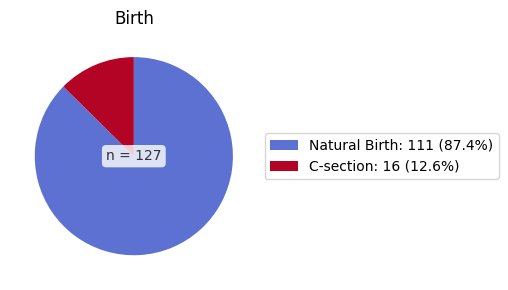

In [226]:
QUESTION_COL = "Were you born by C-section or natural birth?"

# Define categories: label + color
CATEGORIES = [
    ("Natural Birth", "#5c71d1"),  # blue
    ("C-section", "#b40426")  # red
]

cat_order  = [label for label, _ in CATEGORIES]
map_dict   = {label: label for label, _ in CATEGORIES}  
pie_colors = dict(CATEGORIES)

# Plot
out = plot_single_question(
    df=Survey_endo_only,
    question_col=QUESTION_COL,
    multi_label=False,
    allowed_answers=cat_order,
    map_dict=map_dict,
    include_other=False,
    remove_values=("unsure", "none", "", np.nan),  
    sort_by=None,
    category_order=cat_order,
    chart="pie",
    fig_title="Birth",
    y_label=None,
    pie_colors=pie_colors,
    return_data=True,
    display=True
)

In [227]:
# Were you breastfed?

In [228]:
Survey_endo_only["Were you breastfed?"].apply(type).value_counts()

Were you breastfed?
<class 'str'>    310
Name: count, dtype: int64

In [229]:
Survey_endo_only["Were you breastfed?"].count()

310

In [230]:
Survey_endo_only["Were you breastfed?"].isna().sum()

0

In [231]:
# Check for responses
common_items = (
    Survey_endo_only['Were you breastfed?']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 0].head(50))

Were you breastfed?
no        152
yes       139
unsure     19
Name: count, dtype: int64


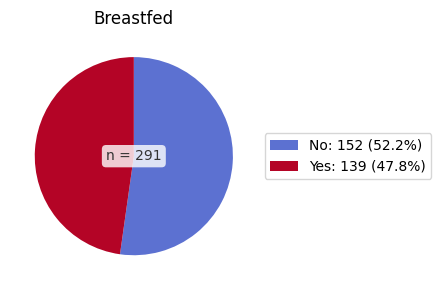

In [232]:
QUESTION_COL = "Were you breastfed?"

# Define categories: label + color
CATEGORIES = [
    ("No", "#5c71d1"),  # blue
    ("Yes", "#b40426")  # red
]

cat_order  = [label for label, _ in CATEGORIES]
map_dict   = {label: label for label, _ in CATEGORIES}  
pie_colors = dict(CATEGORIES)

# Plot
out = plot_single_question(
    df=Survey_endo_only,
    question_col=QUESTION_COL,
    multi_label=False,
    allowed_answers=cat_order,
    map_dict=map_dict,
    include_other=False,
    remove_values=("unsure", "none", "", np.nan),  
    sort_by=None,
    category_order=cat_order,
    chart="pie",
    fig_title="Breastfed",
    y_label=None,
    pie_colors=pie_colors,
    return_data=True,
    display=True
)

## Diet

In [234]:
# Growing up diet

In [235]:
Survey_endo_only["Growing up, was your diet mostly composed of whole (e.g. fresh meat, fruits and vegetables) or processed foods (e.g. fast food, takeaways, frozen meals)?"].apply(type).value_counts()

Growing up, was your diet mostly composed of whole (e.g. fresh meat, fruits and vegetables) or processed foods (e.g. fast food, takeaways, frozen meals)?
<class 'int'>    310
Name: count, dtype: int64

In [236]:
Survey_endo_only["Growing up, was your diet mostly composed of whole (e.g. fresh meat, fruits and vegetables) or processed foods (e.g. fast food, takeaways, frozen meals)?"].count()

310

In [237]:
Survey_endo_only["Growing up, was your diet mostly composed of whole (e.g. fresh meat, fruits and vegetables) or processed foods (e.g. fast food, takeaways, frozen meals)?"].isna().sum()

0

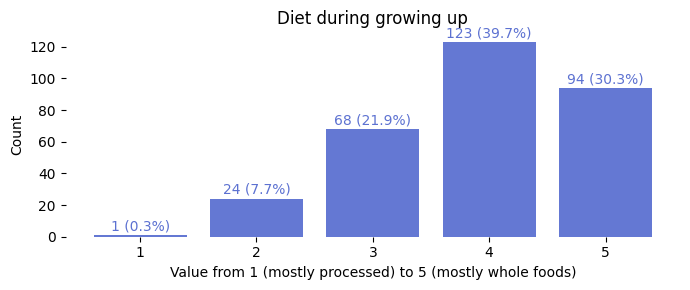

In [238]:
QUESTION_COL = "Growing up, was your diet mostly composed of whole (e.g. fresh meat, fruits and vegetables) or processed foods (e.g. fast food, takeaways, frozen meals)?"

# Extract numeric value
def extract_value(value):
    if pd.isna(value):
        return None
    m = re.search(r'\d+', str(value))
    if m:
        return int(m.group())
    return None

# Apply to dataframe
Survey_endo_only[QUESTION_COL] = Survey_endo_only[QUESTION_COL].apply(extract_value)

# Define category order (1 to 5) 
cat_order = ["1", "2", "3", "4", "5"]

# Mapping: convert int → str for the plotting function
map_dict = {i: str(i) for i in range(1, 6)}

# Plot 
out = plot_single_question(
    df=Survey_endo_only,
    question_col=QUESTION_COL,
    multi_label=False,
    allowed_answers=cat_order,
    map_dict=map_dict,
    category_order=cat_order,
    include_other=False,
    numeric=False,                # use categorical (explicit answers)
    chart="barv",                 
    rescale_to_100=False,                # <<< use COUNTS 
    axis_label="Count",
    fig_title="Diet during growing up",
    y_label="Value from 1 (mostly processed) to 5 (mostly whole foods)",
    return_data=True,
    display=True
)

In [239]:
# Current diet

In [240]:
Survey_endo_only["Is your diet now mostly composed of whole or processed foods?"].apply(type).value_counts()

Is your diet now mostly composed of whole or processed foods?
<class 'int'>    310
Name: count, dtype: int64

In [241]:
Survey_endo_only["Is your diet now mostly composed of whole or processed foods?"].count()

310

In [242]:
Survey_endo_only["Is your diet now mostly composed of whole or processed foods?"].isna().sum()

0

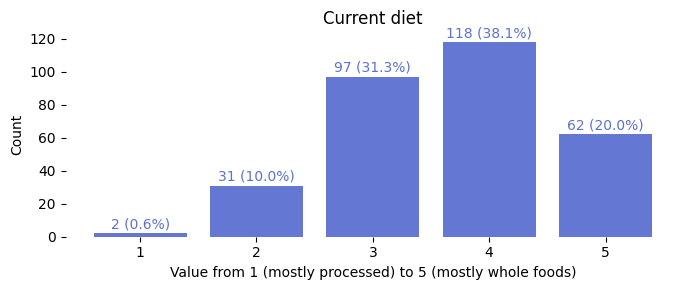

In [243]:
QUESTION_COL = "Is your diet now mostly composed of whole or processed foods?"

# Extract numeric value 
def extract_value(value):
    if pd.isna(value):
        return None
    m = re.search(r'\d+', str(value))
    if m:
        return int(m.group())
    return None

# Apply to dataframe
Survey_endo_only[QUESTION_COL] = Survey_endo_only[QUESTION_COL].apply(extract_value)

# Define category order 
cat_order = ["1", "2", "3", "4", "5"]

# Mapping: convert int → str for the plotting function
map_dict = {i: str(i) for i in range(1, 6)}

# Plot 
out = plot_single_question(
    df=Survey_endo_only,
    question_col=QUESTION_COL,
    multi_label=False,
    allowed_answers=cat_order,
    map_dict=map_dict,
    category_order=cat_order,
    include_other=False,
    numeric=False,                # use categorical (explicit answers)
    chart="barv",                 
    rescale_to_100=False,                # <<< use COUNTS 
    axis_label="Count",
    fig_title="Current diet",
    y_label="Value from 1 (mostly processed) to 5 (mostly whole foods)",
    return_data=True,
    display=True
)

## Smoking

In [245]:
# Are you or have you ever been a smoker?

In [246]:
Survey_endo_only["Are you or have you ever been a smoker?"].apply(type).value_counts()

Are you or have you ever been a smoker?
<class 'str'>      308
<class 'float'>      2
Name: count, dtype: int64

In [247]:
Survey_endo_only["Are you or have you ever been a smoker?"].count()

308

In [248]:
Survey_endo_only["Are you or have you ever been a smoker?"].isna().sum()

2

In [249]:
# Check for responses
common_items = (
    Survey_endo_only['Are you or have you ever been a smoker?']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 1].head(50))

Are you or have you ever been a smoker?
no                       190
i have never smoked      190
yes                       93
but i have since quit     64
i am a smoker             29
occasionally               2
Name: count, dtype: int64


In [250]:
# Very discrepant answers, just focus on the outlined answers=categories as the rest is hard to categorize, keep 'other' here

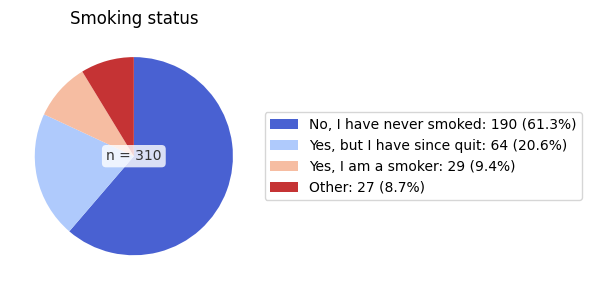

In [251]:
QUESTION_COL = "Are you or have you ever been a smoker?"

# Define allowed categories (including Other)
cat_order = [
    "No, I have never smoked",
    "Yes, but I have since quit",
    "Yes, I am a smoker",
    "Other"
]

map_dict = {c: c for c in cat_order}

# Standardize values into known categories or Other
def standardize_smoking(x):
    if pd.isna(x):
        return "Other"
    s = str(x).strip()
    return s if s in cat_order else "Other"

Survey_endo_only["_smoking"] = Survey_endo_only[QUESTION_COL].apply(standardize_smoking)

# Plot
out = plot_single_question(
    df=Survey_endo_only,
    question_col="_smoking",
    multi_label=False,
    allowed_answers=cat_order,
    map_dict=map_dict,
    category_order=cat_order,
    include_other=True,
    chart="pie",
    fig_title="Smoking status",
    y_label=None,
    pie_cmap="coolwarm",
    pie_cmap_reverse=False,
    return_data=True,
    display=True
)

Survey_endo_only.drop(columns=["_smoking"], inplace=True)

In [252]:
# If yes, at what age did you start smoking?

In [253]:
Survey_endo_only["If yes, at what age did you start smoking?"].apply(type).value_counts()

If yes, at what age did you start smoking?
<class 'float'>    192
<class 'int'>      101
<class 'str'>       17
Name: count, dtype: int64

In [254]:
Survey_endo_only["If yes, at what age did you start smoking?"].count()

118

In [255]:
Survey_endo_only["If yes, at what age did you start smoking?"].isna().sum()

192

In [256]:
# Check for responses
common_items = (
    Survey_endo_only['If yes, at what age did you start smoking?']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 0].head(50))

If yes, at what age did you start smoking?
nan                 101
n/a                   3
stopped at 23         1
15                    1
nil                   1
late teens            1
11...                 1
teenager              1
young tween/teen      1
current age 29        1
off since 16          1
on                    1
.                     1
16-18                 1
14-15                 1
17/18                 1
18 until 21           1
na                    1
Name: count, dtype: int64


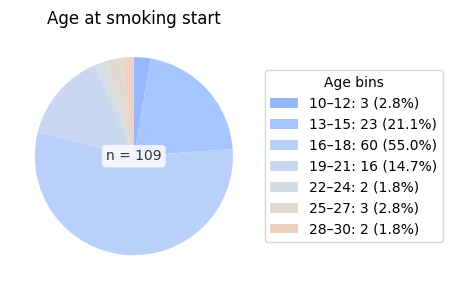

In [257]:
QUESTION_COL = "If yes, at what age did you start smoking?"

bin_tuples = [(0, 3, "0–3")] + [(a, a+2, f"{a}–{a+2}") for a in range(4, 100, 3)]
cat_order_asc = [lab for (_, _, lab) in bin_tuples]

out_age_numeric = plot_single_question(
    df=Survey_endo_only,
    question_col=QUESTION_COL,
    numeric=True,
    number_pattern=r"\d+",
    number_extract="first",
    numeric_range=(1, 129),
    numeric_bins=bin_tuples,
    rescale_to_100=True,
    remove_values=(),
    sort_by=None,
    category_order=cat_order_asc,
    chart="pie",
    fig_title="Age at smoking start",
    y_label="Age bins",
    pie_colors=PALETTE_0_48,
    pie_use_base_color=False,
    pie_cmap="coolwarm",
    pie_cmap_reverse=False,
    pie_distinct_subset=False,
    return_data=True,
    display=True
)

## City or countryside

In [259]:
# Did you grow up in a rural (countryside) or urban area (town or city) setting?

In [260]:
Survey_endo_only["Did you grow up in a rural (countryside) or urban area (town or city) setting?"].apply(type).value_counts()

Did you grow up in a rural (countryside) or urban area (town or city) setting?
<class 'str'>    310
Name: count, dtype: int64

In [261]:
Survey_endo_only["Did you grow up in a rural (countryside) or urban area (town or city) setting?"].count()

310

In [262]:
Survey_endo_only["Did you grow up in a rural (countryside) or urban area (town or city) setting?"].isna().sum()

0

In [263]:
# Did you grow up in a rural (countryside) or urban area (town or city) setting?

# Check for any other itemas I may include 
common_items = (
    Survey_endo_only['Did you grow up in a rural (countryside) or urban area (town or city) setting?']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 1].head(50))

Did you grow up in a rural (countryside) or urban area (town or city) setting?
town     126
rural    105
city      65
Name: count, dtype: int64


In [264]:
# keep other, it is usually mix of the three options

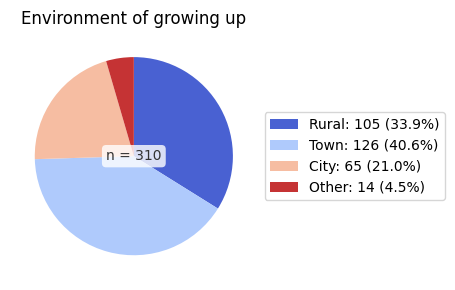

In [265]:
QUESTION_COL = "Did you grow up in a rural (countryside) or urban area (town or city) setting?"

# Define allowed categories (including Other)
cat_order = [
    "Rural",
    "Town",
    "City",
    "Other"
]

map_dict = {c: c for c in cat_order}

# Standardize values into known categories or Other
def standardize_area(x):
    if pd.isna(x):
        return "Other"
    s = str(x).strip()
    return s if s in cat_order else "Other"

Survey_endo_only["_area"] = Survey_endo_only[QUESTION_COL].apply(standardize_area)

# Plot
out = plot_single_question(
    df=Survey_endo_only,
    question_col="_area",
    multi_label=False,
    allowed_answers=cat_order,
    map_dict=map_dict,
    category_order=cat_order,
    include_other=True,
    chart="pie",
    fig_title="Environment of growing up",
    y_label=None,
    pie_cmap="coolwarm",
    pie_cmap_reverse=False,
    return_data=True,
    display=True
)

Survey_endo_only.drop(columns=["_area"], inplace=True)

## Air polution

In [267]:
# How would you describe the air pollution levels where you grew up?

In [268]:
Survey_endo_only["How would you describe the air pollution levels where you grew up?"].apply(type).value_counts()

How would you describe the air pollution levels where you grew up?
<class 'float'>    310
Name: count, dtype: int64

In [269]:
Survey_endo_only["How would you describe the air pollution levels where you grew up?"].count()

309

In [270]:
Survey_endo_only["How would you describe the air pollution levels where you grew up?"].isna().sum()

1

In [271]:
Survey_endo_only["How would you describe the air pollution levels where you grew up?"].head()

0    3.0
1    2.0
2    3.0
3    1.0
4    4.0
Name: How would you describe the air pollution levels where you grew up?, dtype: float64

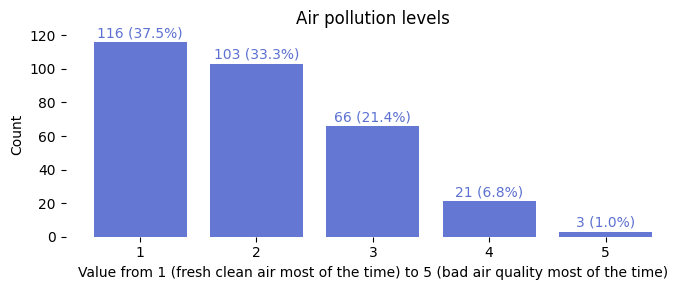

In [272]:
QUESTION_COL = "How would you describe the air pollution levels where you grew up?"

cat_order = ["1", "2", "3", "4", "5"]
map_dict  = {
    1.0: "1", 2.0: "2", 3.0: "3", 4.0: "4", 5.0: "5",
    1: "1", 2: "2", 3: "3", 4: "4", 5: "5",   # (covers ints too, just in case)
    "1": "1", "2": "2", "3": "3", "4": "4", "5": "5",
}

out = plot_single_question(
    df=Survey_endo_only,
    question_col=QUESTION_COL,
    multi_label=False,
    allowed_answers=cat_order,
    map_dict=map_dict,
    category_order=cat_order,
    include_other=False,
    remove_values=("unsure", "maybe", "none", "", np.nan, None),
    numeric=False,
    chart="barv",
    rescale_to_100=False,
    axis_label="Count",
    y_label="Value from 1 (fresh clean air most of the time) to 5 (bad air quality most of the time)",
    fig_title="Air pollution levels",
    return_data=True,
    display=True
)

## Environmental disasters

In [274]:
# Were you exposed to any environmental disasters in your lifetime? If so please list them below

# If yes, did you suffer from any of these conditions before your endometriosis symptoms began?
# Check for any other itemas I may include 
common_items = (
    Survey_endo_only['Were you exposed to any environmental disasters in your lifetime? If so please list them below']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 1].head(50))

Were you exposed to any environmental disasters in your lifetime? If so please list them below
no           125
chernobyl      2
Name: count, dtype: int64


In [275]:
QUESTION_COL = "Were you exposed to any environmental disasters in your lifetime? If so please list them below"

pattern = r'\b(?:Chernobyl|Cernobil|Sellafield)\b'  # non-capturing group
mask = Survey_endo_only[QUESTION_COL].str.contains(pattern, case=False, na=False)
count = mask.sum()
count

8

## Vaccination

In [277]:
# Did you receive all of your vaccinations as a child?

In [278]:
Survey_endo_only["Did you receive all of your vaccinations as a child?"].apply(type).value_counts()

Did you receive all of your vaccinations as a child?
<class 'str'>    310
Name: count, dtype: int64

In [279]:
Survey_endo_only["Did you receive all of your vaccinations as a child?"].count()

310

In [280]:
Survey_endo_only["Did you receive all of your vaccinations as a child?"].isna().sum()

0

In [281]:
# Check responses
common_items = (
    Survey_endo_only['Did you receive all of your vaccinations as a child?']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 1].head(50))

Did you receive all of your vaccinations as a child?
yes                 296
some but not all     14
Name: count, dtype: int64


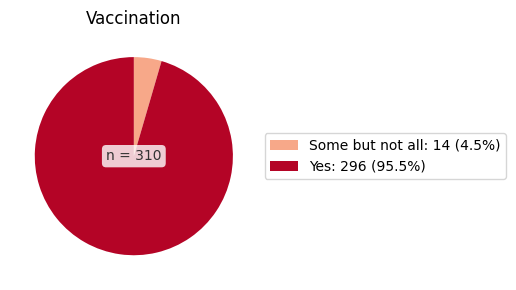

In [282]:
QUESTION_COL = "Did you receive all of your vaccinations as a child?"

# Define categories: label + color
CATEGORIES = [
    ("No I did not receive any vaccinations", "#5c71d1"),  # blue
    ("Some but not all", "#f7a889"),  # orange
    ("Yes", "#b40426")  # red
]

cat_order  = [label for label, _ in CATEGORIES]
map_dict   = {label: label for label, _ in CATEGORIES}  
pie_colors = dict(CATEGORIES)

# Plot
out = plot_single_question(
    df=Survey_endo_only,
    question_col=QUESTION_COL,
    multi_label=False,
    allowed_answers=cat_order,
    map_dict=map_dict,
    include_other=False,
    remove_values=("other", "none", "", np.nan), 
    sort_by=None,
    category_order=cat_order,
    chart="pie",
    fig_title="Vaccination",
    y_label=None,
    pie_colors=pie_colors,
    return_data=True,
    display=True
)

## Infection

In [284]:
# Did you have any illnesses as a child more serious than a common cold or stomach bug?

In [285]:
Survey_endo_only["Did you have any illnesses as a child more serious than a common cold or stomach bug?"].apply(type).value_counts()

Did you have any illnesses as a child more serious than a common cold or stomach bug?
<class 'str'>      309
<class 'float'>      1
Name: count, dtype: int64

In [286]:
Survey_endo_only["Did you have any illnesses as a child more serious than a common cold or stomach bug?"].count()

309

In [287]:
Survey_endo_only["Did you have any illnesses as a child more serious than a common cold or stomach bug?"].isna().sum()

1

In [288]:
# Check responses
common_items = (
    Survey_endo_only['Did you have any illnesses as a child more serious than a common cold or stomach bug?']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 1].head(50))

Did you have any illnesses as a child more serious than a common cold or stomach bug?
yes       167
no        114
unsure     28
Name: count, dtype: int64


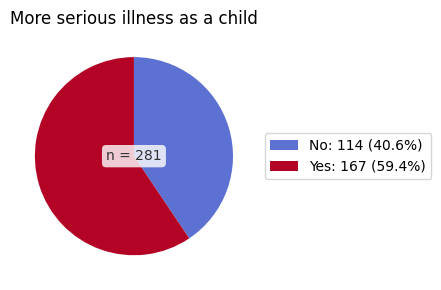

In [289]:
QUESTION_COL = "Did you have any illnesses as a child more serious than a common cold or stomach bug?"

# Define categories: label + color
CATEGORIES = [
    ("No", "#5c71d1"),  # blue
    ("Yes", "#b40426")  # red
]

cat_order  = [label for label, _ in CATEGORIES]
map_dict   = {label: label for label, _ in CATEGORIES}  
pie_colors = dict(CATEGORIES)

# Plot
out = plot_single_question(
    df=Survey_endo_only,
    question_col=QUESTION_COL,
    multi_label=False,
    allowed_answers=cat_order,
    map_dict=map_dict,
    include_other=False,
    remove_values=("unsure", "none", "", np.nan),  
    sort_by=None,
    category_order=cat_order,
    chart="pie",
    fig_title="More serious illness as a child",
    y_label=None,
    pie_colors=pie_colors,
    return_data=True,
    display=True
)

In [290]:
# If yes, can you name the infection if known?

In [291]:
# Check for any other itemas I may include 
common_items = (
    Survey_endo_only['If yes, please list below if you know the name the illness']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 1].head(50))

If yes, please list below if you know the name the illness
tonsillitis            22
glandular fever        12
chicken pox             8
scarlet fever           8
appendicitis            6
pneumonia               6
measles                 5
whooping cough          5
asthma                  5
mumps                   5
strep throat            4
ear infections          4
gastroenteritis         3
german measles          3
chest infections        3
swine flu               2
strep                   2
quinsy                  2
bronchitis              2
kidney infections       2
cryptosporidium         2
chickenpox              2
chronic tonsillitis     2
Name: count, dtype: int64


In [292]:
# Were you unusually healthy most of the time with minimum illness growing up?

In [293]:
Survey_endo_only["Were you unusually healthy most of the time with minimum illness growing up?"].apply(type).value_counts()

Were you unusually healthy most of the time with minimum illness growing up?
<class 'str'>      308
<class 'float'>      2
Name: count, dtype: int64

In [294]:
Survey_endo_only["Were you unusually healthy most of the time with minimum illness growing up?"].count()

308

In [295]:
Survey_endo_only["Were you unusually healthy most of the time with minimum illness growing up?"].isna().sum()

2

In [296]:
# Check responses
common_items = (
    Survey_endo_only['Were you unusually healthy most of the time with minimum illness growing up?']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 1].head(50))

Were you unusually healthy most of the time with minimum illness growing up?
yes       164
no        104
unsure     40
Name: count, dtype: int64


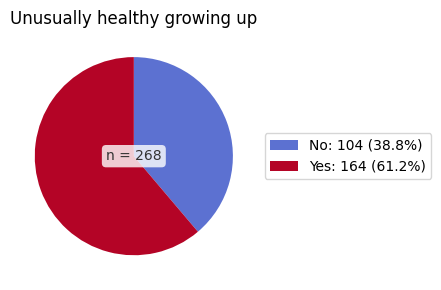

In [297]:
QUESTION_COL = "Were you unusually healthy most of the time with minimum illness growing up?"

# Define categories: label + color
CATEGORIES = [
    ("No", "#5c71d1"),  # blue
    ("Yes", "#b40426")  # red
]

cat_order  = [label for label, _ in CATEGORIES]
map_dict   = {label: label for label, _ in CATEGORIES}  
pie_colors = dict(CATEGORIES)

# Plot
out = plot_single_question(
    df=Survey_endo_only,
    question_col=QUESTION_COL,
    multi_label=False,
    allowed_answers=cat_order,
    map_dict=map_dict,
    include_other=False,
    remove_values=("unsure", "none", "", np.nan),  
    sort_by=None,
    category_order=cat_order,
    chart="pie",
    fig_title="Unusually healthy growing up",
    y_label=None,
    pie_colors=pie_colors,
    return_data=True,
    display=True
)

In [298]:
# Were you more susceptible to bacterial or viral infections than others growing up?

In [299]:
Survey_endo_only["Were you more susceptible to bacterial or viral infections than others growing up?"].apply(type).value_counts()

Were you more susceptible to bacterial or viral infections than others growing up?
<class 'str'>      306
<class 'float'>      4
Name: count, dtype: int64

In [300]:
Survey_endo_only["Were you more susceptible to bacterial or viral infections than others growing up?"].count()

306

In [301]:
Survey_endo_only["Were you more susceptible to bacterial or viral infections than others growing up?"].isna().sum()

4

In [302]:
# Check responses
common_items = (
    Survey_endo_only['Were you more susceptible to bacterial or viral infections than others growing up?']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 1].head(50))

Were you more susceptible to bacterial or viral infections than others growing up?
no                                       170
i was as susceptible as everyone else    137
yes                                      101
i was more susceptible                   101
unsure                                    35
i was less susceptible than others        33
Name: count, dtype: int64


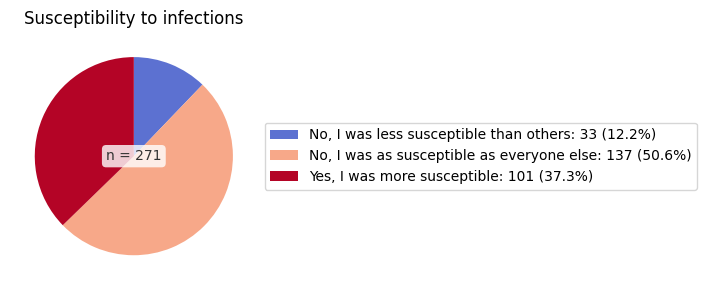

In [303]:
QUESTION_COL = "Were you more susceptible to bacterial or viral infections than others growing up?"

# Define categories: label + color
CATEGORIES = [
    ("No, I was less susceptible than others", "#5c71d1"),  # blue
    ("No, I was as susceptible as everyone else", "#f7a889"),  # orange
    ("Yes, I was more susceptible", "#b40426")  # red
]

cat_order  = [label for label, _ in CATEGORIES]
map_dict   = {label: label for label, _ in CATEGORIES}  
pie_colors = dict(CATEGORIES)

# Plot
out = plot_single_question(
    df=Survey_endo_only,
    question_col=QUESTION_COL,
    multi_label=False,
    allowed_answers=cat_order,
    map_dict=map_dict,
    include_other=False,
    remove_values=("other", "none", "", np.nan),  
    sort_by=None,
    category_order=cat_order,
    chart="pie",
    fig_title="Susceptibility to infections",
    y_label=None,
    pie_colors=pie_colors,
    return_data=True,
    display=True
)

## Bacterial infection

In [305]:
# Were you ever diagnosed with any recurrent bacterial infections?

In [306]:
Survey_endo_only["Were you ever diagnosed with any recurrent bacterial infections?"].apply(type).value_counts()

Were you ever diagnosed with any recurrent bacterial infections?
<class 'str'>      308
<class 'float'>      2
Name: count, dtype: int64

In [307]:
Survey_endo_only["Were you ever diagnosed with any recurrent bacterial infections?"].count()

308

In [308]:
Survey_endo_only["Were you ever diagnosed with any recurrent bacterial infections?"].isna().sum()

2

In [309]:
# Check responses
common_items = (
    Survey_endo_only['Were you ever diagnosed with any recurrent bacterial infections?']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 1].head(50))

Were you ever diagnosed with any recurrent bacterial infections?
no        168
yes       100
unsure     40
Name: count, dtype: int64


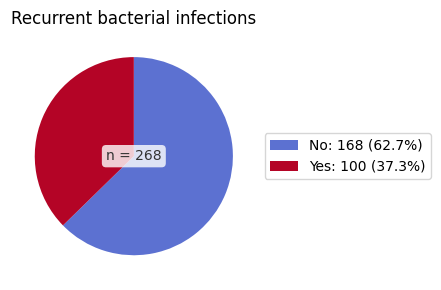

In [310]:
QUESTION_COL = "Were you ever diagnosed with any recurrent bacterial infections?"

# Define categories: label + color
CATEGORIES = [
    ("No", "#5c71d1"),  # blue
    ("Yes", "#b40426")  # red
]

cat_order  = [label for label, _ in CATEGORIES]
map_dict   = {label: label for label, _ in CATEGORIES}  
pie_colors = dict(CATEGORIES)

# Plot
out = plot_single_question(
    df=Survey_endo_only,
    question_col=QUESTION_COL,
    multi_label=False,
    allowed_answers=cat_order,
    map_dict=map_dict,
    include_other=False,
    remove_values=("unsure", "none", "", np.nan),  
    sort_by=None,
    category_order=cat_order,
    chart="pie",
    fig_title="Recurrent bacterial infections",
    y_label=None,
    pie_colors=pie_colors,
    return_data=True,
    display=True
)

In [311]:
# Did you experience any recurrent infection/dysbiosis where antibiotics were inefficient or ineffective or you needed multiple combinations of them?

In [312]:
Survey_endo_only["Did you experience any recurrent infection/dysbiosis where antibiotics were inefficient or ineffective or you needed multiple combinations of them?"].apply(type).value_counts()

Did you experience any recurrent infection/dysbiosis where antibiotics were inefficient or ineffective or you needed multiple combinations of them?
<class 'str'>      308
<class 'float'>      2
Name: count, dtype: int64

In [313]:
Survey_endo_only["Did you experience any recurrent infection/dysbiosis where antibiotics were inefficient or ineffective or you needed multiple combinations of them?"].count()

308

In [314]:
Survey_endo_only["Did you experience any recurrent infection/dysbiosis where antibiotics were inefficient or ineffective or you needed multiple combinations of them?"].isna().sum()

2

In [315]:
# Check responses
common_items = (
    Survey_endo_only['Did you experience any recurrent infection/dysbiosis where antibiotics were inefficient or ineffective or you needed multiple combinations of them?']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 1].head(50))

Did you experience any recurrent infection/dysbiosis where antibiotics were inefficient or ineffective or you needed multiple combinations of them?
no        174
yes       104
unsure     30
Name: count, dtype: int64


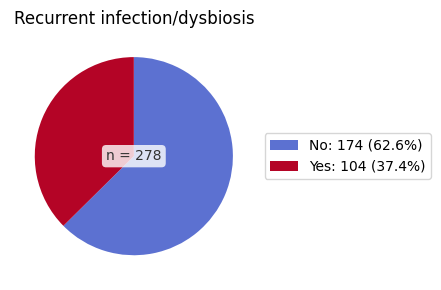

In [316]:
QUESTION_COL = "Did you experience any recurrent infection/dysbiosis where antibiotics were inefficient or ineffective or you needed multiple combinations of them?"

# Define categories: label + color
CATEGORIES = [
    ("No", "#5c71d1"),  # blue
    ("Yes", "#b40426")  # red
]

cat_order  = [label for label, _ in CATEGORIES]
map_dict   = {label: label for label, _ in CATEGORIES}  # identity map (normalize only to these)
pie_colors = dict(CATEGORIES)

# Plot
out = plot_single_question(
    df=Survey_endo_only,
    question_col=QUESTION_COL,
    multi_label=False,
    allowed_answers=cat_order,
    map_dict=map_dict,
    include_other=False,
    remove_values=("unsure", "none", "", np.nan),  # or remove_values=()
    sort_by=None,
    category_order=cat_order,
    chart="pie",
    fig_title="Recurrent infection/dysbiosis",
    y_label=None,
    pie_colors=pie_colors,
    return_data=True,
    display=True
)

In [317]:
# If yes, can you name the infection if known?

In [318]:
# Check for any other itemas I may include 
common_items = (
    Survey_endo_only['If yes, can you name the infection if known?']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 1].head(50))

If yes, can you name the infection if known?
tonsillitis                 15
uti                          9
kidney infections            7
strep throat                 6
sinusitis                    4
thrush                       3
throat infections            3
utis                         3
chest infections             3
ear infections               3
cellulitis                   3
bv                           2
bronchitis                   2
urinary tract infections     2
urinary tract infection      2
pneumonia                    2
Name: count, dtype: int64


In [319]:
# Roughly How many times did you take antibiotics as a child?

In [320]:
Survey_endo_only["Roughly How many times did you take antibiotics as a child?"].apply(type).value_counts()

Roughly How many times did you take antibiotics as a child?
<class 'str'>      306
<class 'float'>      4
Name: count, dtype: int64

In [321]:
Survey_endo_only["Roughly How many times did you take antibiotics as a child?"].count()

306

In [322]:
Survey_endo_only["Roughly How many times did you take antibiotics as a child?"].isna().sum()

4

In [323]:
# Check responses
common_items = (
    Survey_endo_only['Roughly How many times did you take antibiotics as a child?']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 1].head(50))

Roughly How many times did you take antibiotics as a child?
8+ times     127
3-5 times     66
5-7 times     55
1-2 times     41
never         17
Name: count, dtype: int64


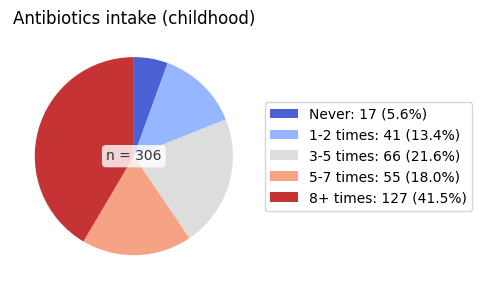

In [324]:
QUESTION_COL = "Roughly How many times did you take antibiotics as a child?"

# Define allowed categories (including Other)
cat_order = [
    "Never",
    "1-2 times",
    "3-5 times",
    "5-7 times",
    "8+ times",
]

map_dict = {c: c for c in cat_order}


# Plot
out = plot_single_question(
    df=Survey_endo_only,
    question_col=QUESTION_COL,
    multi_label=False,
    allowed_answers=cat_order,
    map_dict=map_dict,
    category_order=cat_order,
    include_other=False,
    chart="pie",
    fig_title="Antibiotics intake (childhood)",
    y_label=None,
    pie_cmap="coolwarm",
    pie_cmap_reverse=False,
    return_data=True,
    display=True
)

In [325]:
# Check ilnesses in these two columns as they overlap
# If yes, can you name the infection if known?
# If yes, please list below if you know the name the illness
# Most commonly occured: tonsillitis, UTIs and glandular fever

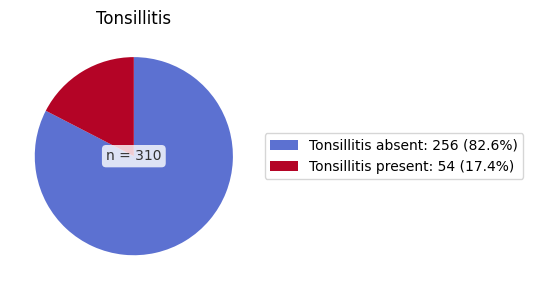

In [326]:
# Tonsillitis - selection based on overall responses- the answers are in these two colulmns:
# If yes, can you name the infection if known?
# If yes, please list below if you know the name the illness

QUESTION_COL1 = "If yes, please list below if you know the name the illness"
QUESTION_COL2 = "If yes, can you name the infection if known?"

tonsillitis_regex = re.compile(r"\btonsillitis\b[.,;:]?", re.IGNORECASE)

def detect_tonsillitis(row):
    txt1 = str(row[QUESTION_COL1]).casefold() if isinstance(row[QUESTION_COL1], str) else ""
    txt2 = str(row[QUESTION_COL2]).casefold() if isinstance(row[QUESTION_COL2], str) else ""
    combined = txt1 + " " + txt2

    if tonsillitis_regex.search(combined):
        return "Tonsillitis present"
    else:
        return "Tonsillitis absent"

Survey_endo_only = Survey_endo_only.copy()

Survey_endo_only.loc[:, "Tonsillitis_status"] = (
    Survey_endo_only.apply(detect_tonsillitis, axis=1)
)

# Define categories and mapping for your plotting function
cat_order = ["Tonsillitis absent", "Tonsillitis present"]   
map_dict  = {c: c for c in cat_order}                       # identity mapping

# Category-specific colors 
pie_colors = {
    "Tonsillitis present": "#b40426",  # red
    "Tonsillitis absent" : "#5c71d1",  # blue
}

# Plot
out = plot_single_question(
    df=Survey_endo_only,
    question_col="Tonsillitis_status",
    multi_label=False,
    allowed_answers=cat_order,
    map_dict=map_dict,
    category_order=cat_order,
    include_other=False,
    chart="pie",
    fig_title="Tonsillitis",
    y_label=None,
    pie_cmap="coolwarm",
    pie_cmap_reverse=False,
    pie_colors=pie_colors,
    return_data=True,
    display=True
)


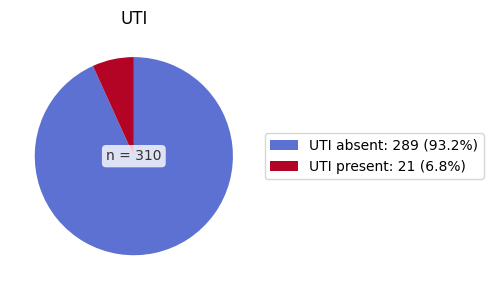

In [327]:
# UTIs

# UTIs- selection based on overall responses- the answers are in these two colulmns:
# If yes, can you name the infection if known?
# If yes, please list below if you know the name the illness

QUESTION_COL1 = "If yes, please list below if you know the name the illness"
QUESTION_COL2 = "If yes, can you name the infection if known?"

uti_regex = re.compile(
    r"\buti\b|"                                 # UTI standalone
    r"\burinary\s*tract\s*infection[s]?\b|"     # urinary tract infection / infections
    r"\burinary\s*infection[s]?\b",             # urinary infection,     
    re.IGNORECASE
)

def detect_uti(row):
    txt1 = str(row[QUESTION_COL1]).casefold() if isinstance(row[QUESTION_COL1], str) else ""
    txt2 = str(row[QUESTION_COL2]).casefold() if isinstance(row[QUESTION_COL2], str) else ""
    combined = txt1 + " " + txt2

    if uti_regex.search(combined):
        return "UTI present"
    else:
        return "UTI absent"

Survey_endo_only = Survey_endo_only.copy()

Survey_endo_only.loc[:, "UTI_status"] = (
    Survey_endo_only.apply(detect_uti, axis=1)
)

# Define categories and mapping for your plotting function
cat_order = ["UTI absent", "UTI present"]   
map_dict  = {c: c for c in cat_order}                       # identity mapping

# Category-specific colors
pie_colors = {
    "UTI present": "#b40426",  # red
    "UTI absent" : "#5c71d1",  # blue
}

# Plot
out = plot_single_question(
    df=Survey_endo_only,
    question_col="UTI_status",
    multi_label=False,
    allowed_answers=cat_order,
    map_dict=map_dict,
    category_order=cat_order,
    include_other=False,
    chart="pie",
    fig_title="UTI",
    y_label=None,
    pie_cmap="coolwarm",
    pie_colors=pie_colors,
    pie_cmap_reverse=False,
    return_data=True,
    display=True
)


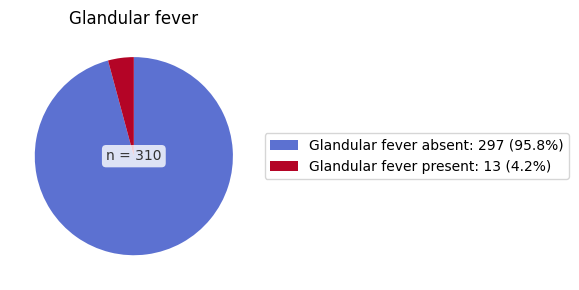

In [328]:
# Glandular fever - virus

# If yes, can you name the infection if known?
# If yes, please list below if you know the name the illness

QUESTION_COL1 = "If yes, please list below if you know the name the illness"
QUESTION_COL2 = "If yes, can you name the infection if known?"

glandular_regex = re.compile(r"\bglandular[- ]?fever\b[.,;:]?", re.IGNORECASE)

def detect_glandular(row):
    txt1 = str(row[QUESTION_COL1]).casefold() if isinstance(row[QUESTION_COL1], str) else ""
    txt2 = str(row[QUESTION_COL2]).casefold() if isinstance(row[QUESTION_COL2], str) else ""
    combined = txt1 + " " + txt2

    if glandular_regex.search(combined):
        return "Glandular fever present"
    else:
        return "Glandular fever absent"

Survey_endo_only = Survey_endo_only.copy()

Survey_endo_only.loc[:, "Glandular fever_status"] = (
    Survey_endo_only.apply(detect_glandular, axis=1)
)

# Define categories and mapping for your plotting function
cat_order = ["Glandular fever absent", "Glandular fever present"]   
map_dict  = {c: c for c in cat_order}                       # identity mapping

# Category-specific colors 
pie_colors = {
    "Glandular fever present": "#b40426",  # red
    "Glandular fever absent" : "#5c71d1",  # blue
}

# Plot
out = plot_single_question(
    df=Survey_endo_only,
    question_col="Glandular fever_status",
    multi_label=False,
    allowed_answers=cat_order,
    map_dict=map_dict,
    category_order=cat_order,
    include_other=False,
    chart="pie",
    fig_title="Glandular fever",
    y_label=None,
    pie_cmap="coolwarm",
    pie_colors=pie_colors,
    pie_cmap_reverse=False,
    return_data=True,
    display=True
)


In [329]:
# Have you had frequent UTI or vaginal infections throughout your life?

In [330]:
Survey_endo_only["Have you had frequent UTI or vaginal infections throughout your life?"].apply(type).value_counts()

Have you had frequent UTI or vaginal infections throughout your life?
<class 'str'>      309
<class 'float'>      1
Name: count, dtype: int64

In [331]:
Survey_endo_only["Have you had frequent UTI or vaginal infections throughout your life?"].count()

309

In [332]:
Survey_endo_only["Have you had frequent UTI or vaginal infections throughout your life?"].isna().sum()

1

In [333]:
# Check responses
common_items = (
    Survey_endo_only['Have you had frequent UTI or vaginal infections throughout your life?']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 1].head(50))

Have you had frequent UTI or vaginal infections throughout your life?
yes       177
no        124
unsure      8
Name: count, dtype: int64


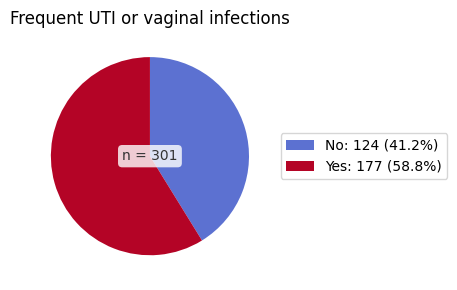

In [334]:
QUESTION_COL = "Have you had frequent UTI or vaginal infections throughout your life?"

# Define categories: label + color
CATEGORIES = [
    ("No", "#5c71d1"),  # blue
    ("Yes", "#b40426")  # red
]

cat_order  = [label for label, _ in CATEGORIES]
map_dict   = {label: label for label, _ in CATEGORIES}  
pie_colors = dict(CATEGORIES)

# Plot
out = plot_single_question(
    df=Survey_endo_only,
    question_col=QUESTION_COL,
    multi_label=False,
    allowed_answers=cat_order,
    map_dict=map_dict,
    include_other=False,
    remove_values=("unsure", "none", "", np.nan),  
    sort_by=None,
    category_order=cat_order,
    chart="pie",
    fig_title="Frequent UTI or vaginal infections",
    y_label=None,
    pie_colors=pie_colors,
    return_data=True,
    display=True
)

In [335]:
# Have you ever been diagnosed with any not so common pathogens, if yes please list below
Survey_endo_only["Have you ever been diagnosed with any not so common pathogens, if yes please list below?"].apply(type).value_counts()

Have you ever been diagnosed with any not so common pathogens, if yes please list below?
<class 'float'>    234
<class 'str'>       76
Name: count, dtype: int64

In [336]:
Survey_endo_only["Have you ever been diagnosed with any not so common pathogens, if yes please list below?"].count()

76

In [337]:
Survey_endo_only["Have you ever been diagnosed with any not so common pathogens, if yes please list below?"].isna().sum()

234

In [338]:
# Check responses
common_items = (
    Survey_endo_only['Have you ever been diagnosed with any not so common pathogens, if yes please list below?']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 0].head(50))

Have you ever been diagnosed with any not so common pathogens, if yes please list below?
no                                                                                    57
unsure                                                                                 2
ureaplasma in uterine environment & vagina                                             1
pneumonia all in adulthood                                                             1
glandular fever                                                                        1
chicken pox                                                                            1
swine flu                                                                              1
do not think so                                                                        1
entamoeba histolytica after a rural hike in morocco                                    1
i have rhesus negative                                                                 1
not sure             

## SARS-CoV-2 infection and COVID-19

In [340]:
# Did you ever have Covid-19

In [341]:
Survey_endo_only["Did you ever have Covid-19"].apply(type).value_counts()

Did you ever have Covid-19
<class 'float'>    182
<class 'str'>      128
Name: count, dtype: int64

In [342]:
Survey_endo_only["Did you ever have Covid-19"].apply(type).count()

310

In [343]:
Survey_endo_only["Did you ever have Covid-19"].apply(type).isna().sum()

0

In [344]:
# Check responses
common_items = (
    Survey_endo_only['Did you ever have Covid-19']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 1].head(50))

Did you ever have Covid-19
yes    117
no      11
Name: count, dtype: int64


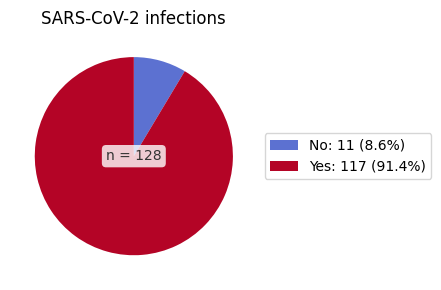

In [1096]:
QUESTION_COL = "Did you ever have Covid-19"

# Define categories: label + color
CATEGORIES = [
    ("No", "#5c71d1"),  # blue
    ("Yes", "#b40426")  # red
]

cat_order  = [label for label, _ in CATEGORIES]
map_dict   = {label: label for label, _ in CATEGORIES}  
pie_colors = dict(CATEGORIES)

# Plot
out = plot_single_question(
    df=Survey_endo_only,
    question_col=QUESTION_COL,
    multi_label=False,
    allowed_answers=cat_order,
    map_dict=map_dict,
    include_other=False,
    remove_values=("unsure", "none", "", np.nan),  
    category_order=cat_order,
    chart="pie",
    fig_title="SARS-CoV-2 infections",
    y_label=None,
    pie_colors=pie_colors,
    return_data=True,
    display=True
)

In [346]:
# If yes, how many times did you have Covid-19?

In [347]:
Survey_endo_only["If yes, how many times did you have Covid-19?"].apply(type).value_counts()

If yes, how many times did you have Covid-19?
<class 'float'>    193
<class 'int'>       77
<class 'str'>       40
Name: count, dtype: int64

In [348]:
Survey_endo_only["If yes, how many times did you have Covid-19?"].count()

117

In [349]:
Survey_endo_only["If yes, how many times did you have Covid-19?"].isna().sum()

193

In [350]:
# Check responses
common_items = (
    Survey_endo_only['Did you ever have Covid-19']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 0].head(50))

Did you ever have Covid-19
yes    117
no      11
Name: count, dtype: int64


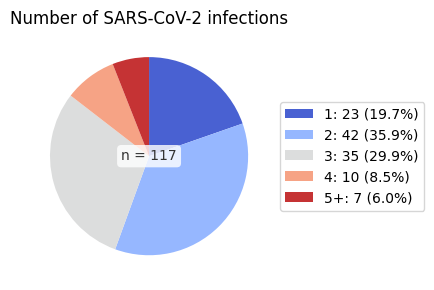

In [1098]:
QUESTION_COL = "If yes, how many times did you have Covid-19?"

# Map categories
WORD_TO_NUM = {
    "one": 1, "once": 1,
    "two": 2, "twice": 2,
    "three": 3, "thrice": 3,
    "four": 4,
    "five": 5,
    "six": 6,
    "seven": 7,
    "eight": 8,
    "nine": 9,
    "ten": 10,
}

# Catch ranges like "2-3", "3/4", "3 to 4"
RANGE_RE = re.compile(r"(\d+)\s*(?:-|\/|to)\s*(\d+)", re.IGNORECASE)

# Catch digits in many forms: "3", "3x", "3 times", "5time", "5x covid"
DIGIT_RE = re.compile(r"\b(\d+)\b|(\d+)\s*[x]|(\d+)\s*times?", re.IGNORECASE)

def extract_count(value):
    """
    Extract an integer count from free text using this precedence:
      1) Numeric ranges (take the max): '2-3', '3/4', '3 to 4'
      2) Any numeric forms: '3', '3x', '4 times', '5time'
      3) Word numbers: 'once', 'twice', 'three', 'five (5)'
    Returns np.nan if nothing meaningful is found.
    """
    if pd.isna(value):
        return np.nan

    s = str(value).strip().lower()

    # Try ranges first: take the max as conservative count
    rng = RANGE_RE.search(s)
    if rng:
        try:
            low = int(rng.group(1))
            high = int(rng.group(2))
            return max(low, high)
        except Exception:
            pass

    # Try digit-based patterns
    matches = DIGIT_RE.findall(s)
    if matches:
        nums = []
        for tup in matches:
            for g in tup:
                if g:
                    try:
                        nums.append(int(g))
                    except Exception:
                        pass
        if nums:
            return max(nums)

    # Try word-number mapping (also handles 'five (5)' by the digit path above)
    for word, val in WORD_TO_NUM.items():
        if word in s:
            return val

    # If nothing found
    return np.nan


def bucket_times(n):
    """
    Map integer counts to ordered buckets: '1','2','3','4','5+'.
    Returns None for NaN.
    """
    if pd.isna(n):
        return None
    n = int(n)
    if n <= 1:
        return "1"
    elif n == 2:
        return "2"
    elif n == 3:
        return "3"
    elif n == 4:
        return "4"
    else:
        return "5+"

Survey_endo_only = Survey_endo_only.copy()

# Extract numeric count
Survey_endo_only.loc[:, "Covid_times_count"] = (
    Survey_endo_only[QUESTION_COL].apply(extract_count)
)

# Bucket into ["1","2","3","4","5+"]
Survey_endo_only.loc[:, "Covid_times_category"] = (
    Survey_endo_only["Covid_times_count"].apply(bucket_times)
)

COVID_COL = "Covid_times_category"

# Define categories and mapping for your plotting function
cat_order = ["1", "2", "3", "4", "5+"]   
map_dict  = {c: c for c in cat_order}                       # identity mapping

# Plot
out = plot_single_question(
    df=Survey_endo_only,
    question_col=COVID_COL,
    multi_label=False,
    allowed_answers=["1", "2", "3", "4", "5+"],
    map_dict=map_dict,
    category_order=cat_order,
    include_other=False,
    chart="pie",
    fig_title="Number of SARS-CoV-2 infections",
    y_label=None,
    pie_cmap="coolwarm",
    pie_cmap_reverse=False,
    return_data=True,
    display=True
)

In [352]:
# Did you receive the covid-19 vaccine?

In [353]:
Survey_endo_only["Did you receive the covid-19 vaccine?"].apply(type).value_counts()

Did you receive the covid-19 vaccine?
<class 'float'>    183
<class 'str'>      127
Name: count, dtype: int64

In [354]:
Survey_endo_only["Did you receive the covid-19 vaccine?"].count()

127

In [355]:
Survey_endo_only["Did you receive the covid-19 vaccine?"].isna().sum()

183

In [356]:
# Check responses
common_items = (
    Survey_endo_only['Did you receive the covid-19 vaccine?']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 0].head(50))

Did you receive the covid-19 vaccine?
yes    125
no       2
Name: count, dtype: int64


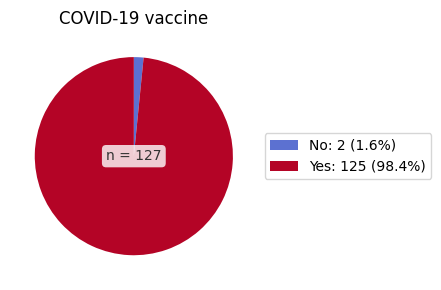

In [357]:
QUESTION_COL = "Did you receive the covid-19 vaccine?"

# Define once: label + color
CATEGORIES = [
    ("No", "#5c71d1"),  # blue
    ("Yes", "#b40426")  # red
]

# Derive everything from the single source
cat_order  = [label for label, _ in CATEGORIES]
map_dict   = {label: label for label, _ in CATEGORIES}  # identity map (normalize only to these)
pie_colors = dict(CATEGORIES)

# Plot
out = plot_single_question(
    df=Survey_endo_only,
    question_col=QUESTION_COL,
    multi_label=False,
    allowed_answers=cat_order,
    map_dict=map_dict,
    include_other=False,
    remove_values=("unsure", "none", "", np.nan),  # or remove_values=()
    sort_by=None,
    category_order=cat_order,
    chart="pie",
    fig_title="COVID-19 vaccine",
    y_label=None,
    pie_colors=pie_colors,
    return_data=True,
    display=True
)

In [358]:
# Did you notice any change in your endometriosis symptoms after either Covid-19 or after the vaccine

In [359]:
Survey_endo_only["Did you notice any change in your endometriosis symptoms after either Covid-19 or after the vaccine"].apply(type).value_counts()

Did you notice any change in your endometriosis symptoms after either Covid-19 or after the vaccine
<class 'float'>    184
<class 'str'>      126
Name: count, dtype: int64

In [360]:
Survey_endo_only["Did you notice any change in your endometriosis symptoms after either Covid-19 or after the vaccine"].count()

126

In [361]:
Survey_endo_only["Did you notice any change in your endometriosis symptoms after either Covid-19 or after the vaccine"].isna().sum()

184

In [362]:
# Check responses
common_items = (
    Survey_endo_only['Did you notice any change in your endometriosis symptoms after either Covid-19 or after the vaccine']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 0].head(50))

Did you notice any change in your endometriosis symptoms after either Covid-19 or after the vaccine
no                                                   117
i did not notice any change after the vaccine         76
yes                                                   53
i did not notice any change after having covid-19     41
my symptoms worsened after the vaccine                30
my symptoms worsened after having covid-19            23
Name: count, dtype: int64


## Symptoms after the SARS-CoV-2 infection and COVID-19 vaccination

C:\Users\rfahey\AppData\Local\Temp\ipykernel_16684\4248177088.py:99: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([fix(t.get_text()) for t in ax.get_xticklabels()])
C:\Users\rfahey\AppData\Local\Temp\ipykernel_16684\4248177088.py:100: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([fix(t.get_text()) for t in ax.get_yticklabels()])


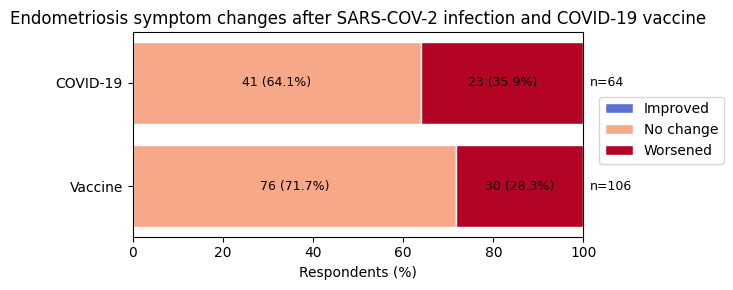

In [1101]:
# Plot changes after SARS-CoV-2 infection and COVID-19 vaccination

col = "Did you notice any change in your endometriosis symptoms after either Covid-19 or after the vaccine"

# Keep only respondents who answered anything 
base = Survey_endo_only[[col]].dropna().assign(respondent=lambda d: d.index)

# Explode multi-select answers
exp = (
    base.assign(option=base[col].astype(str).str.split(r"[;,]\s*"))
        .explode("option")
)
exp["option"] = exp["option"].str.strip()
exp = exp[exp["option"] != ""]

# Map exact answers into Source × Direction
patt_map = [
    (re.compile(r"improv.*after.*vaccine", re.I),   ("Vaccine", "Improved")),
    (re.compile(r"worsen.*after.*vaccine", re.I),   ("Vaccine", "Worsened")),
    (re.compile(r"no.*change.*after.*vaccine", re.I), ("Vaccine", "No change")),

    (re.compile(r"improv.*after.*covid", re.I),     ("COVID-19", "Improved")),
    (re.compile(r"worsen.*after.*covid", re.I),     ("COVID-19", "Worsened")),
    (re.compile(r"no.*change.*after.*covid", re.I),   ("COVID-19", "No change")),
]

def map_option(opt):
    for patt, val in patt_map:
        if patt.search(opt):
            return val
    return (None, None)

exp[["Source","Direction"]] = exp["option"].apply(lambda x: pd.Series(map_option(x)))
exp = exp.dropna(subset=["Source","Direction"])

# Ensure only one direction per respondent×source 
clean = exp.drop_duplicates(["respondent","Source"], keep="first")

# Denominators (who answered for each source)
sources = ["Vaccine","COVID-19"]
directions = ["Improved","No change","Worsened"]
denoms = clean.groupby("Source")["respondent"].nunique().reindex(sources).fillna(0).astype(int)

# Counts per category per source
counts = (
    clean.groupby(["Source","Direction"])["respondent"]
         .nunique()
         .unstack(fill_value=0)
         .reindex(index=sources, columns=directions, fill_value=0)
)

# Percentages (100% stacked) 
perc = counts.div(denoms.replace(0, pd.NA), axis=0) * 100
perc = perc.fillna(0)

# PLOT (horizontal 100% stacked)

palette = {"Improved":"#5c71d1", "No change":"#f7a889", "Worsened":"#b40426"}

fig, ax = plt.subplots(figsize=(7, 3))

left = None
for cat in directions:
    vals = perc[cat].values
    ax.barh(perc.index, vals, left=left, label=cat,
            color=palette[cat], edgecolor="white")
    left = vals if left is None else (left + vals)

ax.set_xlim(0, 100)
ax.set_xlabel("Respondents (%)")
ax.set_title("Endometriosis symptom changes after SARS-COV-2 infection and COVID-19 vaccine")
ax.tick_params(axis='y', labelsize=10)

# Labels inside bars 
for j, source in enumerate(perc.index):
    prev = 0
    for cat in directions:
        w = float(perc.loc[source, cat])
        if w > 0:
            x = prev + w/2
            n = int(counts.loc[source, cat])
            ax.text(x, j, f"{n} ({w:.1f}%)", va="center", ha="center", fontsize=9)
            prev += w

# Denominators on the right 
for j, source in enumerate(perc.index):
    ax.text(101.5, j, f"n={denoms[source]}",
            va="center", fontsize=9)

ax.legend(bbox_to_anchor=(1.02,0.72), loc="upper left", frameon=True)

# Fix missing glyphs due to non-breaking hyphen 
def _fix_text_glyphs(ax):
    def fix(s): 
        return s.replace('\u2011', '-').replace('\u2013', '-').replace('\u2014', '-') if isinstance(s, str) else s
    ax.set_title(fix(ax.get_title()))
    ax.set_xlabel(fix(ax.get_xlabel()))
    ax.set_ylabel(fix(ax.get_ylabel()))
    ax.set_xticklabels([fix(t.get_text()) for t in ax.get_xticklabels()])
    ax.set_yticklabels([fix(t.get_text()) for t in ax.get_yticklabels()])

_fix_text_glyphs(ax)
ax.grid(False)
plt.tight_layout()
plt.show()

In [365]:
# Is there anything else in relation to your endometriosis and Covid-19 that you would like to mention?
# for manual checking

## Immunity

## Allergy

In [368]:
# Are you allergic to anything?

In [369]:
Survey_endo_only["Are you allergic to anything?"].apply(type).value_counts()

Are you allergic to anything?
<class 'str'>      308
<class 'float'>      2
Name: count, dtype: int64

In [370]:
Survey_endo_only["Are you allergic to anything?"].count()

308

In [371]:
Survey_endo_only["Are you allergic to anything?"].isna().sum()

2

In [372]:
# Check responses
common_items = (
    Survey_endo_only['Are you allergic to anything?']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 0].head(50))

Are you allergic to anything?
no     174
yes    134
Name: count, dtype: int64


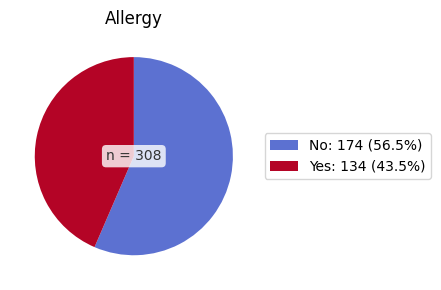

In [373]:
QUESTION_COL = "Are you allergic to anything?"

# Define categories: label + color
CATEGORIES = [
    ("No", "#5c71d1"),  # blue
    ("Yes", "#b40426")  # red
]

cat_order  = [label for label, _ in CATEGORIES]
map_dict   = {label: label for label, _ in CATEGORIES}  
pie_colors = dict(CATEGORIES)

# Plot
out = plot_single_question(
    df=Survey_endo_only,
    question_col=QUESTION_COL,
    multi_label=False,
    allowed_answers=cat_order,
    map_dict=map_dict,
    include_other=False,
    remove_values=("unsure", "none", "", np.nan),  
    sort_by=None,
    category_order=cat_order,
    chart="pie",
    fig_title="Allergy",
    y_label=None,
    pie_colors=pie_colors,
    return_data=True,
    display=True
)

In [374]:
# If yes, please list even the most unusual allergies

In [375]:
# Check for any other itemas I may include 
common_items = (
    Survey_endo_only['If yes, please list even the most unusual allergies']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 1].head(50))

If yes, please list even the most unusual allergies
pollen            17
dust              14
penicillin        12
cats               9
hayfever           7
grass              6
gluten             5
latex              5
dogs               4
tramadol           3
lobster            3
kiwis              3
lactose            3
horses             2
hay fever          2
plasters           2
grass pollen       2
trimethoprim       2
nsaids             2
hair dye           2
aloe vera          2
plums              2
kiwi               2
dairy              2
nickel             2
mosquito bites     2
shellfish          2
dander             2
bee stings         2
erythromycin       2
feathers           2
Name: count, dtype: int64


## Autoimmunity

In [377]:
# Have you been diagnosed with any autoimmune conditions or autoimmune antibodies?

In [378]:
Survey_endo_only["Have you been diagnosed with any autoimmune conditions or autoimmune antibodies?"].apply(type).value_counts()

Have you been diagnosed with any autoimmune conditions or autoimmune antibodies?
<class 'str'>      308
<class 'float'>      2
Name: count, dtype: int64

In [379]:
Survey_endo_only["Have you been diagnosed with any autoimmune conditions or autoimmune antibodies?"].count()

308

In [380]:
Survey_endo_only["Have you been diagnosed with any autoimmune conditions or autoimmune antibodies?"].isna().sum()

2

In [381]:
# Check responses
common_items = (
    Survey_endo_only['Have you been diagnosed with any autoimmune conditions or autoimmune antibodies?']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 0].head(50))

Have you been diagnosed with any autoimmune conditions or autoimmune antibodies?
no                                             237
yes                                             38
unsure                                          19
fibromyalgia                                     3
hypothyroidism                                   2
pots                                             1
underactive thyroid but i got of medication      1
regulated it through diet                        1
lifestyle medicine                               1
chronic inflammatory adhesions                   1
recurring miscarriage hypothyroidism             1
alopecia areata                                  1
under investigation for rheumatoid arthitis      1
investigations ongoing                           1
yes positive ana test but no autoimmune          1
no but i'm 90% sure i have psoriasis             1
may have crohns under investigstion              1
Name: count, dtype: int64


In [382]:
# some unsure, the other test either lists another condition or says under investigation, some conflicting saying yes but no- too disparate to regex it- focus on yes and no

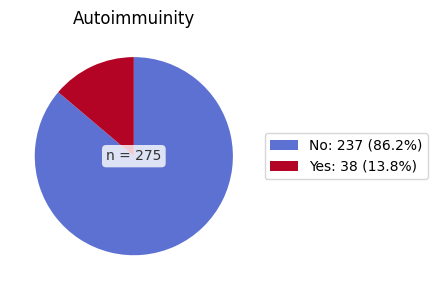

In [383]:
QUESTION_COL = "Have you been diagnosed with any autoimmune conditions or autoimmune antibodies?"

# Define categories: label + color
CATEGORIES = [
    ("No", "#5c71d1"),  # blue
    ("Yes", "#b40426")  # red
]

cat_order  = [label for label, _ in CATEGORIES]
map_dict   = {label: label for label, _ in CATEGORIES}  
pie_colors = dict(CATEGORIES)

# Plot
out = plot_single_question(
    df=Survey_endo_only,
    question_col=QUESTION_COL,
    multi_label=False,
    allowed_answers=cat_order,
    map_dict=map_dict,
    include_other=False,
    remove_values=("unsure", "none", "", np.nan),  
    sort_by=None,
    category_order=cat_order,
    chart="pie",
    fig_title="Autoimmuinity",
    y_label=None,
    pie_colors=pie_colors,
    return_data=True,
    display=True
)

## Chronic diseases

In [385]:
# Have you been diagnosed with any chronic illnesses other than endometriosis?

In [386]:
Survey_endo_only["Have you been diagnosed with any chronic illnesses other than endometriosis?"].apply(type).value_counts()

Have you been diagnosed with any chronic illnesses other than endometriosis?
<class 'str'>      308
<class 'float'>      2
Name: count, dtype: int64

In [387]:
Survey_endo_only["Have you been diagnosed with any chronic illnesses other than endometriosis?"].count()

308

In [388]:
Survey_endo_only["Have you been diagnosed with any chronic illnesses other than endometriosis?"].isna().sum()

2

In [389]:
# Check responses
common_items = (
    Survey_endo_only['Have you been diagnosed with any chronic illnesses other than endometriosis?']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 0].head(50))

Have you been diagnosed with any chronic illnesses other than endometriosis?
no        189
yes       108
unsure     11
Name: count, dtype: int64


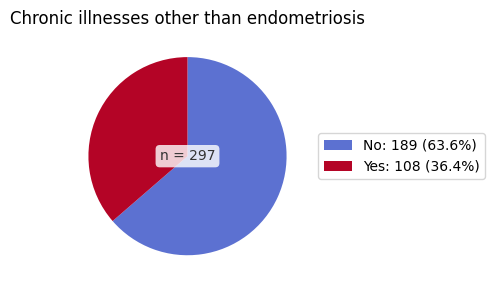

In [390]:
QUESTION_COL = "Have you been diagnosed with any chronic illnesses other than endometriosis?"

# Define categories: label + color
CATEGORIES = [
    ("No", "#5c71d1"),  # blue
    ("Yes", "#b40426")  # red
]

cat_order  = [label for label, _ in CATEGORIES]
map_dict   = {label: label for label, _ in CATEGORIES}  
pie_colors = dict(CATEGORIES)

# Plot
out = plot_single_question(
    df=Survey_endo_only,
    question_col=QUESTION_COL,
    multi_label=False,
    allowed_answers=cat_order,
    map_dict=map_dict,
    include_other=False,
    remove_values=("unsure", "none", "", np.nan),  
    sort_by=None,
    category_order=cat_order,
    chart="pie",
    fig_title="Chronic illnesses other than endometriosis",
    y_label=None,
    pie_colors=pie_colors,
    return_data=True,
    display=True
)

In [391]:
# If yes to either of the two above questions, please list these conditions if you can

In [392]:
# Check for any other items I may include 
common_items = (
    Survey_endo_only['If yes to either of the two above questions, please list these conditions if you can']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 1].head(50))

If yes to either of the two above questions, please list these conditions if you can
asthma                   19
adenomyosis              13
pcos                     11
ibs                      10
fibromyalgia              6
hypothyroidism            5
psoriasis                 5
pots                      4
gerd                      4
diverticulitis            3
interstitial cystitis     2
graves disease            2
eds                       2
chronic migraines         2
hypermobility             2
ra                        2
arthritis                 2
chronic fatigue           2
glandular fever           2
migraines                 2
allergic asthma           2
Name: count, dtype: int64


In [393]:
# Have you been diagnosed with any autoimmune conditions or autoimmune antibodies?

In [394]:
Survey_endo_only["Have you been diagnosed with any autoimmune conditions or autoimmune antibodies?"].apply(type).value_counts()

Have you been diagnosed with any autoimmune conditions or autoimmune antibodies?
<class 'str'>      308
<class 'float'>      2
Name: count, dtype: int64

In [395]:
Survey_endo_only["Have you been diagnosed with any autoimmune conditions or autoimmune antibodies?"].count()

308

In [396]:
Survey_endo_only["Have you been diagnosed with any autoimmune conditions or autoimmune antibodies?"].isna().sum()

2

In [397]:
# Check for any other itemas I may include 
common_items = (
    Survey_endo_only['Have you been diagnosed with any autoimmune conditions or autoimmune antibodies?']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)
print(common_items[common_items > 0].head(50))

Have you been diagnosed with any autoimmune conditions or autoimmune antibodies?
no                                             237
yes                                             38
unsure                                          19
fibromyalgia                                     3
hypothyroidism                                   2
pots                                             1
underactive thyroid but i got of medication      1
regulated it through diet                        1
lifestyle medicine                               1
chronic inflammatory adhesions                   1
recurring miscarriage hypothyroidism             1
alopecia areata                                  1
under investigation for rheumatoid arthitis      1
investigations ongoing                           1
yes positive ana test but no autoimmune          1
no but i'm 90% sure i have psoriasis             1
may have crohns under investigstion              1
Name: count, dtype: int64


In [398]:
# Do the list from the two above columns together

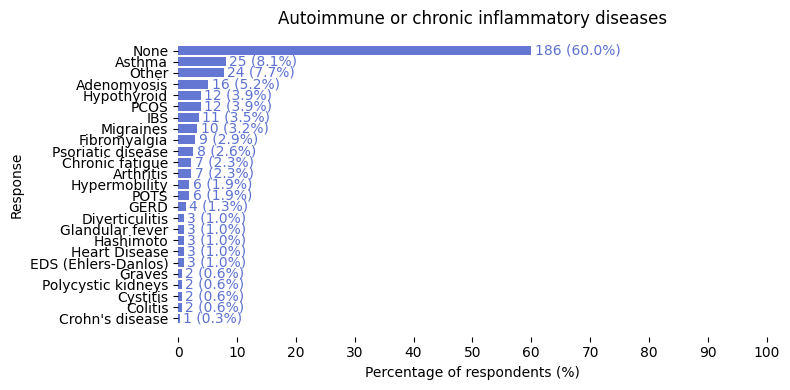

In [399]:
# Chronic and autoimmune conditions together
# joint column analyses
COL1 = "If yes to either of the two above questions, please list these conditions if you can"
COL2 = "Have you been diagnosed with any autoimmune conditions or autoimmune antibodies?"

# Sets to interpret "no content" / admin answers (all lower-case strings)
IGNORE2 = {"yes", "no", "unsure", "n/a", "na", ""}  # for column 2 admin answers
NONE_WORDS = {"none", "no other", "nil", "no", "n/a", "na", ""}  # general empty/none words

def normalize(x):
    """Return a lower-cased string with NaN/None mapped to empty string."""
    if x is None:
        return ""
    # Catch floats that are NaN
    if isinstance(x, float) and math.isnan(x):
        return ""
    s = str(x).strip()
    # Also treat literal 'nan' strings as empty
    if s.casefold() in {"nan"}:
        return ""
    return s.casefold()

def map_immune_multilabel(raw):
    """Map raw free-text to a list of normalized condition labels."""
    # Normalize early
    s = "" if raw is None else str(raw).strip()
    sn = s.casefold()

    # normalize no responses and blanks to None 
    if sn in {"", "no", "none", "no other", "unsure", "yes", "y", "n", "n/a", "na", "nan"}:
        return ["None"]

    # Patterns
    patterns = {
        "MS (Multiple Sclerosis)": ["ms", "multiple sclerosis", "mulitple sclerosos", "m.s."],
        "Arthritis": ["rheumatoid arthritis", "arthritis", "osteoarthritis", "arthrtis", "arthiritis"],
        "Heart Disease": ["heart disease", "cardiac disease", "cardiovascular disease","heart condition", "coronary disease","heart"],
        "Type 1 Diabetes": ["type 1 diabetes", "t1d", "t1dm", "type i diabetes"],
        "Lupus": ["lupus", "sle", "systemic lupus"],
        "Psoriatic disease": ["psoriasis", "psorasis", "psor"],
        "Crohn's disease": ["Crohn's disease","Crohns disease","crohn's disease"],
        "Colitis": ["ulcerative colitis", "uc", "ulcerative", "colitis"],
        "Fibromyalgia": ["fibromyalgia", "fibromialgia"],
        "Diverticulitis": ["diverticulitis", "divertic", "diverticulosis"],
        "POTS": ["pots", "postural tachycardia", "postural orthostatic"],
        "GERD": ["gerd", "reflux", "acid reflux", "gastroesophageal reflux"],
        "EDS (Ehlers-Danlos)": ["eds", "ehlers danlos", "ehlers-danlos", "ehlers", "danlos","heds"],
        "Migraines": ["migraine", "migraines", "migrenes"],
        "Glandular fever": ["glandular fever", "mono", "mononucleosis"],
        "Hypermobility": ["hypermobility", "hypermobile", "jhs", "joint hypermobility"],
        "Chronic fatigue": ["fatigue", "chronic fatigue", "cfs", "chronic fatigue syndrome","me/cfs", "m.e."],
        "Cystitis": ["cystitis"],
        "Polycystic kidneys": ["Polycystic kidney"],
        "Hashimoto": ["hashimoto", "hashimotos", "hashimoto's"],
        "Graves": ["graves", "graves disease"],
        "Hypothyroid": ["hypothyroid", "hypothyroidism", "underactive thyroid","low thyroid", "under active thyroid"],
        "Asthma": ["asthma", "asmtha"],
        "PCOS": ["pcos", "polycystic ovary", "polycystic ovarian"],
        "IBS": ["ibs", "irritable bowel"],
        "Adenomyosis": ["adenomyosis", "adeno"],
        "None": ["unknown", "none", "not", "no", "n/a", "nil", "none reported"]
    }

    categories_found = []

    # Use word boundaries for short acronyms to avoid false positives
    boundary_tokens = {"ms", "ra", "uc", "eds", "sle", "t1d"}
    for label, plist in patterns.items():
        for p in plist:
            p_norm = p.casefold()
            if p_norm in boundary_tokens:
                if re.search(rf"\b{re.escape(p_norm)}\b", sn):
                    categories_found.append(label)
                    break
            else:
                if p_norm in sn:
                    categories_found.append(label)
                    break

    if not categories_found:
        return ["Other"]
    return categories_found

def combine_two_condition_columns(row):
    """Merge categories from both columns and remove duplicates, 
       ignoring admin responses in column 2 and returning 'None' when appropriate."""
    raw1_norm = normalize(row[COL1])
    raw2_norm = normalize(row[COL2])

    # If both columns have no useful text, return ["None"]
    raw1_is_none = (raw1_norm in NONE_WORDS)
    raw2_is_none_or_ignore = (raw2_norm in IGNORE2 or raw2_norm in NONE_WORDS)
    if raw1_is_none and raw2_is_none_or_ignore:
        return ["None"]

    # Map column 1 normally
    cats1 = map_immune_multilabel(row[COL1])

    # Only map column 2 if it contains meaningful text (not yes/no/unsure/etc.)
    if raw2_norm in IGNORE2 or raw2_norm in NONE_WORDS:
        cats2 = []
    else:
        cats2 = map_immune_multilabel(row[COL2])

    # Combine & dedupe
    combined = list(dict.fromkeys(cats1 + cats2))

    # Prefer recognized categories; drop 'None'/'Other' if real categories exist
    real = [c for c in combined if c not in ("None", "Other")]
    if real:
        return real
    if "None" in combined:
        return ["None"]
    if "Other" in combined:
        return ["Other"]
    return ["None"]  # very defensive fallback

# Build merged list column
Survey_endo_only["combined_autoimmune"] = (
    Survey_endo_only.apply(combine_two_condition_columns, axis=1)
)

# Convert lists → comma-separated strings for plotting
Survey_endo_only["combined_autoimmune_str"] = (
    Survey_endo_only["combined_autoimmune"]
    .apply(lambda x: ", ".join(x) if isinstance(x, list) else x)
)

# Allowed categories for the plot
ALLOWED = [
    "MS (Multiple Sclerosis)", "Arthritis", "Heart Disease", "Type 1 Diabetes",
    "Lupus", "Psoriatic disease", "Crohn's disease", "Colitis",
    "Fibromyalgia", "Diverticulitis", "POTS", "GERD",
    "EDS (Ehlers-Danlos)", "Migraines", "Glandular fever", "Hypermobility",
    "Chronic fatigue", "Cystitis", "Hashimoto", "Graves", "Hypothyroid",
    "Asthma", "PCOS", "IBS", "Adenomyosis", "Other", "None"
]

# Splitter that always returns a list
splitter = lambda s: (["None"] if pd.isna(s) else [t.strip() for t in str(s).split(",") if t.strip()])

# Plot
out = plot_single_question(
    df=Survey_endo_only,
    question_col="combined_autoimmune_str",
    category_func=splitter,           # split the comma-separated string
    multi_label=True,
    allowed_answers=ALLOWED,          # tell the function the valid labels
    na_to_category="None",
    remove_values=(),
    rescale_to_100=True,
    sort_by="count_desc",
    chart="barh",
    fig_title="Autoimmune or chronic inflammatory diseases",
    y_label="Response",
    figsize=(8,4), 
)

In [400]:
# Do you have any elevated inflammatory markers? Or any other abnormal results from immune tests?(Please give whatever information you have)

In [401]:
# Check for any other itemas I may include 
common_items = (
    Survey_endo_only['Do you have any elevated inflammatory markers? Or any other abnormal results from immune tests?(Please give whatever information you have)']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 1].head(50))

Do you have any elevated inflammatory markers? Or any other abnormal results from immune tests?(Please give whatever information you have)
no                               27
yes                               6
unsure                            5
elevated inflammatory markers     2
crp                               2
i don’t know                      2
n/a                               2
never been tested                 2
Name: count, dtype: int64


In [402]:
# Are you aware of any abnormal results in any medical tests you have had done?

In [403]:
# Check for any other itemas I may include 
common_items = (
    Survey_endo_only['Are you aware of any abnormal results in any medical tests you have had done?']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 1].head(50))

Are you aware of any abnormal results in any medical tests you have had done?
no                    52
yes                    6
low b12                5
low iron               4
low vitamin d          3
as above               3
elevated prolactin     2
high haemoglobin       2
low blood pressure     2
vitamin d              2
Name: count, dtype: int64


In [404]:
# Inflammation
# Define your columns
col1 = 'Are you aware of any abnormal results in any medical tests you have had done?'
col2 = 'Do you have any elevated inflammatory markers? Or any other abnormal results from immune tests?(Please give whatever information you have)'  

# Define the pattern you want to search for
# For the marker "CA125", this regex will match case-insensitively and is robust to optional spaces (e.g., "CA 125")
pattern = r'\binflamm'
#r'\bCA\s*125\b'

# Create a boolean mask for rows where either column contains the pattern
mask = (
    Survey_endo_only[col1].str.contains(pattern, case=False, na=False, regex=True) |
    Survey_endo_only[col2].str.contains(pattern, case=False, na=False, regex=True)
)

# Count distinct rows that match in either column (counted once even if both match)
matching_rows = mask.sum()

print(matching_rows)

13


In [405]:
# CA125
# Define your columns
col1 = 'Are you aware of any abnormal results in any medical tests you have had done?'
col2 = 'Do you have any elevated inflammatory markers? Or any other abnormal results from immune tests?(Please give whatever information you have)'  

# Define the pattern you want to search for
# For the marker "CA125", this regex will match case-insensitively and is robust to optional spaces (e.g., "CA 125")
pattern = r'\bCA\s*125\b'

# Create a boolean mask for rows where either column contains the pattern
mask = (
    Survey_endo_only[col1].str.contains(pattern, case=False, na=False, regex=True) |
    Survey_endo_only[col2].str.contains(pattern, case=False, na=False, regex=True)
)

# Count distinct rows that match in either column (counted once even if both match)
matching_rows = mask.sum()

print(matching_rows)

15


In [406]:
# CRP
col1 = 'Do you have any elevated inflammatory markers? Or any other abnormal results from immune tests?(Please give whatever information you have)' 
col2 = 'Are you aware of any abnormal results in any medical tests you have had done?'

pattern = r'\bCRP'

# Create a boolean mask for rows where either column contains the pattern
mask = (
    Survey_endo_only[col1].str.contains(pattern, case=False, na=False, regex=True) |
    Survey_endo_only[col2].str.contains(pattern, case=False, na=False, regex=True)
)

# Count distinct rows that match in either column (counted once even if both match)
matching_rows = mask.sum()

print(matching_rows)

18


In [407]:
# Prolactin
col1 = 'Do you have any elevated inflammatory markers? Or any other abnormal results from immune tests?(Please give whatever information you have)' 
col2 = 'Are you aware of any abnormal results in any medical tests you have had done?'

pattern = r'prolactin'

# Create a boolean mask for rows where either column contains the pattern
mask = (
    Survey_endo_only[col1].str.contains(pattern, case=False, na=False, regex=True) |
    Survey_endo_only[col2].str.contains(pattern, case=False, na=False, regex=True)
)

# Count distinct rows that match in either column (counted once even if both match)
matching_rows = mask.sum()

print(matching_rows)

11


In [408]:
# Iron
col1 = 'Do you have any elevated inflammatory markers? Or any other abnormal results from immune tests?(Please give whatever information you have)' 
col2 = 'Are you aware of any abnormal results in any medical tests you have had done?'

pattern = r'\biron'

# Create a boolean mask for rows where either column contains the pattern
mask = (
    Survey_endo_only[col1].str.contains(pattern, case=False, na=False, regex=True) |
    Survey_endo_only[col2].str.contains(pattern, case=False, na=False, regex=True)
)

# Count distinct rows that match in either column (counted once even if both match)
matching_rows = mask.sum()

print(matching_rows)

11


In [409]:
# B12
col1 = 'Do you have any elevated inflammatory markers? Or any other abnormal results from immune tests?(Please give whatever information you have)' 
col2 = 'Are you aware of any abnormal results in any medical tests you have had done?'

pattern = r'\bb12'

# Create a boolean mask for rows where either column contains the pattern
mask = (
    Survey_endo_only[col1].str.contains(pattern, case=False, na=False, regex=True) |
    Survey_endo_only[col2].str.contains(pattern, case=False, na=False, regex=True)
)

# Count distinct rows that match in either column (counted once even if both match)
matching_rows = mask.sum()

print(matching_rows)

7


## Blood type

In [411]:
# What is your blood type?

In [412]:
Survey_endo_only["What is your blood type?"].apply(type).value_counts()

What is your blood type?
<class 'str'>      296
<class 'float'>     14
Name: count, dtype: int64

In [413]:
Survey_endo_only["What is your blood type?"].count()

296

In [414]:
Survey_endo_only["What is your blood type?"].isna().sum()

14

In [415]:
# Check responses
common_items = (
    Survey_endo_only['What is your blood type?']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 0].head(50))

What is your blood type?
unsure    157
o+         55
o-         30
a+         23
b+          9
a-          9
b-          5
ab+         4
ab-         4
Name: count, dtype: int64


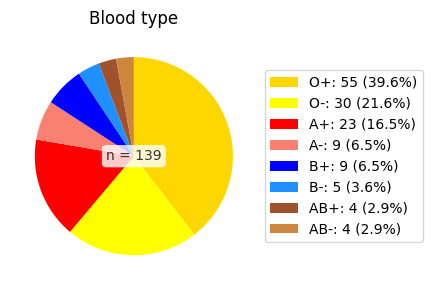

In [416]:
# Blood group- all details
QUESTION_COL = "What is your blood type?"

# Define once: label + color
CATEGORIES = [
    ("O+", "gold"),  
    ("O-", "yellow"),
    ("A+", "red"),  
    ("A-", "salmon"),  
    ("B+", "blue"),  
    ("B-", "dodgerblue"),  
    ("AB+", "sienna"),  
    ("AB-", "peru"),  
  
]

# Derive everything from the single source
cat_order  = [label for label, _ in CATEGORIES]
map_dict   = {label: label for label, _ in CATEGORIES}  # identity map (normalize only to these)
pie_colors = dict(CATEGORIES)

# Plot
out = plot_single_question(
    df=Survey_endo_only,
    question_col=QUESTION_COL,
    multi_label=False,
    allowed_answers=cat_order,
    map_dict=map_dict,
    include_other=False,
    remove_values=("unsure", "none", "", np.nan),  # or remove_values=()
    sort_by=None,
    category_order=cat_order,
    chart="pie",
    fig_title="Blood type",
    y_label=None,
    pie_colors=pie_colors,
    return_data=True,
    display=True
)

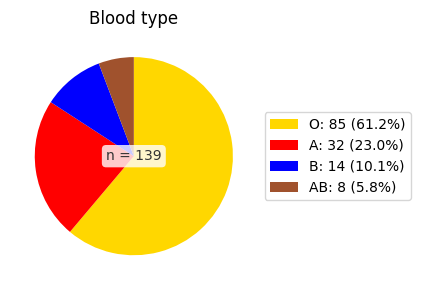

In [417]:
# Blood group- focus on main groups and ignore + and -
QUESTION_COL = "What is your blood type?"

# Define  groups
def map_to_abo(value: str):
    v = str(value).strip()
    if v == "" or v.casefold() == "unsure":
        return None
    v = v.upper().replace(" ", "")
    if v in {"A+", "A-"} or v == "A":
        return "A"
    if v in {"B+", "B-"} or v == "B":
        return "B"
    if v in {"AB+", "AB-"} or v == "AB":
        return "AB"
    if v in {"O+", "O-"} or v == "O":
        return "O"
    return None
    
Survey_endo_only["_abo"] = Survey_endo_only[QUESTION_COL].apply(map_to_abo) #  create pooled ABO column
order = ["O", "A", "B", "AB"]  # Desired order
counts = Survey_endo_only["_abo"].value_counts().reindex(order).dropna() # count pooled groups

# Colors per pooled group
cat_order = {"O": "gold", "A": "red", "B": "blue", "AB": "sienna"}
pie_colors = [cat_order.get(lbl, "#7f7f7f") for lbl in counts.index]


# Plot
out = plot_single_question(
    df=Survey_endo_only,
    question_col="_abo",
    multi_label=False,
    allowed_answers=cat_order,
    map_dict=map_dict,
    category_order=order,
    include_other=False,
    remove_values=("unsure", "none", "", np.nan),  # or remove_values=()
    chart="pie",
    fig_title="Blood type",
    y_label=None,
    pie_colors=pie_colors,
    pie_cmap="coolwarm",
    pie_cmap_reverse=False,
    return_data=True,
    display=True
)

Survey_endo_only.drop(columns=["_abo"], inplace=True)

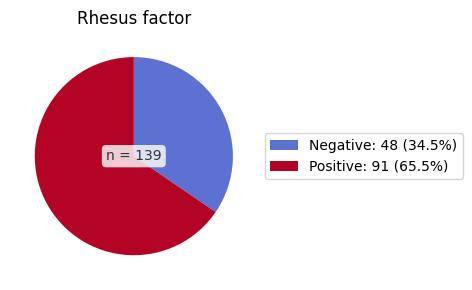

In [418]:
# Now, count all Rhesus positive and negative together

QUESTION_COL = "What is your blood type?"

# Define  groups
def map_to_rhesus(value: str):
    v = str(value).strip()
    if v == "" or v.casefold() == "unsure":
        return None
    v = v.upper().replace(" ", "")
    if v in {"A-", "B-", "AB-", "O-"}:
        return "Negative"
    if v in {"A+", "B+", "AB+", "O+"}:
        return "Positive"
    return None
    
Survey_endo_only["_rhe"] = Survey_endo_only[QUESTION_COL].apply(map_to_rhesus) #  create pooled Rhesus column
order = ["Negative", "Positive"]  # Desired order
counts = Survey_endo_only["_rhe"].value_counts().reindex(order).dropna() # count pooled groups

# Colors per pooled group
cat_order = {"Negative": "#5c71d1", "Positive": "#b40426"}
pie_colors = [cat_order.get(lbl, "#7f7f7f") for lbl in counts.index]


# Plot
out = plot_single_question(
    df=Survey_endo_only,
    question_col="_rhe",
    multi_label=False,
    allowed_answers=cat_order,
    map_dict=map_dict,
    category_order=order,
    include_other=False,
    remove_values=("unsure", "none", "", np.nan),  # or remove_values=()
    chart="pie",
    fig_title="Rhesus factor",
    y_label=None,
    pie_colors=pie_colors,
    pie_cmap="coolwarm",
    pie_cmap_reverse=False,
    return_data=True,
    display=True
)

Survey_endo_only.drop(columns=["_rhe"], inplace=True)

In [419]:
# What is your secretor status

In [420]:
Survey_endo_only["What is your secretor status"].apply(type).value_counts()

What is your secretor status
<class 'float'>    263
<class 'str'>       47
Name: count, dtype: int64

In [421]:
Survey_endo_only["What is your secretor status"].count()

47

In [422]:
Survey_endo_only["What is your secretor status"].isna().sum()

263

In [423]:
# Check responses
common_items = (
    Survey_endo_only['What is your secretor status']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 0].head(50))

What is your secretor status
negative    35
positive    12
Name: count, dtype: int64


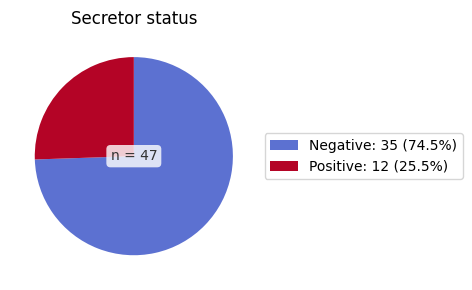

In [424]:
QUESTION_COL = "What is your secretor status"

# Define categories: label + color
CATEGORIES = [
    ("Negative", "#5c71d1"),  # blue
    ("Positive", "#b40426")  # red
]

cat_order  = [label for label, _ in CATEGORIES]
map_dict   = {label: label for label, _ in CATEGORIES}  # identity map (normalize only to these)
pie_colors = dict(CATEGORIES)

# Plot
out = plot_single_question(
    df=Survey_endo_only,
    question_col=QUESTION_COL,
    multi_label=False,
    allowed_answers=cat_order,
    map_dict=map_dict,
    include_other=False,
    remove_values=("unsure", "none", "", np.nan),  # or remove_values=()
    sort_by=None,
    category_order=cat_order,
    chart="pie",
    fig_title="Secretor status",
    y_label=None,
    pie_colors=pie_colors,
    return_data=True,
    display=True
)

## Family history and correlation with patients

## Endometriosis and other gyneacological conditions in family

In [427]:
# Does anyone in your family have endometriosis?

In [428]:
Survey_endo_only["Does anyone in your family have endometriosis?"].apply(type).value_counts()

Does anyone in your family have endometriosis?
<class 'str'>    310
Name: count, dtype: int64

In [429]:
Survey_endo_only["Does anyone in your family have endometriosis?"].count()

310

In [430]:
Survey_endo_only["Does anyone in your family have endometriosis?"].isna().sum()

0

In [431]:
# Check responses
common_items = (
    Survey_endo_only['Does anyone in your family have endometriosis?']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 1].head(50))

Does anyone in your family have endometriosis?
no                                                140
yes                                               131
diagnosed                                          69
suspected endometriosis                            62
but they have another gynaecological condition     59
unsure                                             39
Name: count, dtype: int64


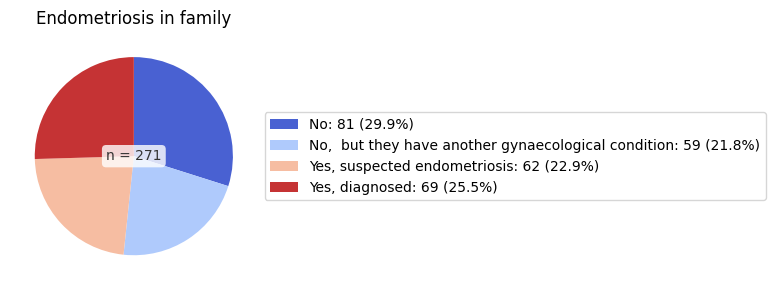

In [432]:
QUESTION_COL = "Does anyone in your family have endometriosis?"

# Define allowed categories 
cat_order = [
    "No",
    "No,  but they have another gynaecological condition",
    "Yes, suspected endometriosis",
    "Yes, diagnosed",
]

map_dict = {c: c for c in cat_order}

# Plot
out = plot_single_question(
    df=Survey_endo_only,
    question_col=QUESTION_COL,
    multi_label=False,
    allowed_answers=cat_order,
    map_dict=map_dict,
    category_order=cat_order,
    include_other=False,
    chart="pie",
    fig_title="Endometriosis in family",
    y_label=None,
    pie_cmap="coolwarm",
    pie_cmap_reverse=False,
    return_data=True,
    display=True
)

In [433]:
# If they have been diagnosed with another gynaecological condition please list it below

In [434]:
Survey_endo_only["If they have been diagnosed with another gynaecological condition please list it below"].apply(type).value_counts()

If they have been diagnosed with another gynaecological condition please list it below
<class 'float'>    194
<class 'str'>      116
Name: count, dtype: int64

In [435]:
Survey_endo_only["If they have been diagnosed with another gynaecological condition please list it below"].count()

116

In [436]:
Survey_endo_only["If they have been diagnosed with another gynaecological condition please list it below"].isna().sum()

194

In [437]:
# Check for any other itemas I may include 
common_items = (
    Survey_endo_only['If they have been diagnosed with another gynaecological condition please list it below']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 1].head(50))

If they have been diagnosed with another gynaecological condition please list it below
pcos                     21
fibroids                 16
adenomyosis              12
no                        7
ovarian cancer            7
ovarian cysts             6
infertility               4
cervical cancer           3
endometriosis             2
mother had fibroids       2
secondary infertility     2
large cysts               2
Name: count, dtype: int64


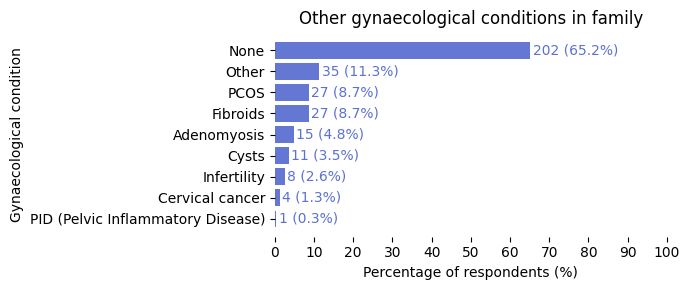

In [438]:
QUESTION_COL = "If they have been diagnosed with another gynaecological condition please list it below"

# Custom category mapper with the priority logic (PCOS > Cysts) ---
def map_gyn_other_multilabel(raw: str):  
    if raw is None or str(raw).strip() == "":
        return ["None"]


    s = str(raw).strip()
    sn = s.casefold()

    # Detect 'None' meanings 
    none_patterns = [
        r'\bnone\b', r'\bno other\b', r'\bno\b', 
        r'\bn/?a\b', r'\bnil\b'
    ]
    if any(re.search(p, sn) for p in none_patterns):
        return ["None"]

    categories_found = []

    # PCOS (separate because it contains "cyst" textually)
    has_pcos = bool(re.search(r'\bpcos\b', sn))

    if has_pcos:
        categories_found.append("PCOS")

    # Cysts (only if PCOS not present) 
    has_cyst = bool(re.search(r'\bcyst(s)?\b', sn))
    if has_cyst and not has_pcos:
        categories_found.append("Cysts")

    # Other categories (can all co-occur) 
    patterns = {
        "PID (Pelvic Inflammatory Disease)": [r'\bpid\b', r'pelvic inflammatory disease'],
        "Cervical cancer": [r'cervical cancer'],
        "Endometrial cancer": [r'endometrial cancer'],
        "Adenomyosis": [r'\badenomyosis\b'],
        "Fibroids": [r'\bfibroid(s)?\b'],
        "Endosalpingiosis": [r'endosalpingiosis'],
        "Pelvic congestion syndrome": [r'pelvic congestion syndrome'],
        "Infertility": [r'\binfertilit(y|ies)\b', r'\bsubfertilit(y|ies)\b'],
        "None": [r'^\s*none\s*$', r'^\s*no other\s*$', r'^\s*no\b(?!.*\bexcept\b)', r'^\s*n/?a\s*$', r'^\s*nil\s*$', "None"]
    }

    for label, patterns_list in patterns.items():
        for p in patterns_list:
            if re.search(p, sn):
                categories_found.append(label)
                break  # avoid duplicate insertion

    # If nothing matched yet → assign "Other" 
    if len(categories_found) == 0:
        return ["Other"]

    return categories_found

# Plot
out = plot_single_question(
    df=Survey_endo_only,
    question_col=QUESTION_COL,
    category_func=map_gyn_other_multilabel,
    multi_label=True,
    na_to_category=None,            # mapper already returns ["None"] for NA/none-like
    remove_values=(),               # count everyone
    rescale_to_100=True,           # bar length = counts; labels include % of respondents
    sort_by="count_desc",             
    chart="barh",
    y_label="Gynaecological condition",
    fig_title="Other gynaecological conditions in family",
    return_data=True,
    display=True
)

In [439]:
# Correlation- patient vs family gyneacological conditions
# "Please list any other gynaecological conditions you have been diagnosed with "
# "If they have been diagnosed with another gynaecological condition please list it below"

# Correlations family vs patients- other gyn conditions

In [441]:
# Correlation of other gyneacological conditions- family vs patients - the counts are not correct and I dont knwo why!!!
# the above is correct throuhg and I am using the same code!!

In [442]:
COL_A = "Please list any other gynaecological conditions you have been diagnosed with "
COL_B = "If they have been diagnosed with another gynaecological condition please list it below"

# Custom category mapper with priority logic (PCOS > Cysts) ---
def map_gyn_other_multilabel(raw: str):
    if raw is None or str(raw).strip() == "":
        return ["None"]

    s = "" if raw is None else str(raw).strip()
    sn = s.casefold()
    # Normalize admin/blank responses to "None"
    if sn in {"", "no", "none", "no other", "unsure", "yes", "y", "n", "n/a", "na", "nan"}:
        return ["None"]
    
    categories_found = []

    # PCOS (separate because it contains "cyst" textually) 
    has_pcos = bool(re.search(r'\bpcos\b', sn))
    if has_pcos:
        categories_found.append("PCOS")

    #  Cysts (only if PCOS not present) 
    has_cyst = bool(re.search(r'\bcyst(s)?\b', sn))
    if has_cyst and not has_pcos:
        categories_found.append("Cysts")

    patterns = {
        "PID": [r'\bpid\b', r'pelvic inflammatory disease'],
        "Cervical cancer": [r'cervical cancer'],
        "Endometrial cancer": [r'endometrial cancer'],
        "Adenomyosis": [r'\badenomyosis\b'],
        "Fibroids": [r'\bfibroid(s)?\b'],
        "Endosalpingiosis": [r'endosalpingiosis'],
        "Pelvic congestion syndrome": [r'pelvic congestion syndrome'],
        "Infertility": [r'\binfertilit(y|ies)\b', r'\bsubfertilit(y|ies)\b'],
        "None": [r'^\s*none\s*$', r'^\s*no other\s*$', r'^\s*no\b(?!.*\bexcept\b)', r'^\s*n/?a\s*$', r'^\s*nil\s*$', "None"]
    }

    
    for label, patterns_list in patterns.items():
        for p in patterns_list:
            if re.search(p, sn):
                categories_found.append(label)
                break  # avoid duplicate insertion

    #  If nothing matched yet → assign "Other" 
    if not categories_found:
        return ["Other"]
   
    return categories_found


Contingency table (counts):
                            Adenomyosis  Cervical cancer  Cysts  Endometrial cancer  Endosalpingiosis  Fibroids  Infertility  PCOS  Pelvic congestion syndrome  PID  Other  None
Adenomyosis                           5                0      0                   0                 0         3            2     5                           0    0      4    30
Cervical cancer                       0                0      0                   0                 0         0            0     0                           0    0      0     0
Cysts                                 0                0      0                   0                 0         0            0     1                           0    0      2     7
Endometrial cancer                    1                0      0                   0                 0         0            0     1                           0    0      0     0
Endosalpingiosis                      0                0      0                   0    

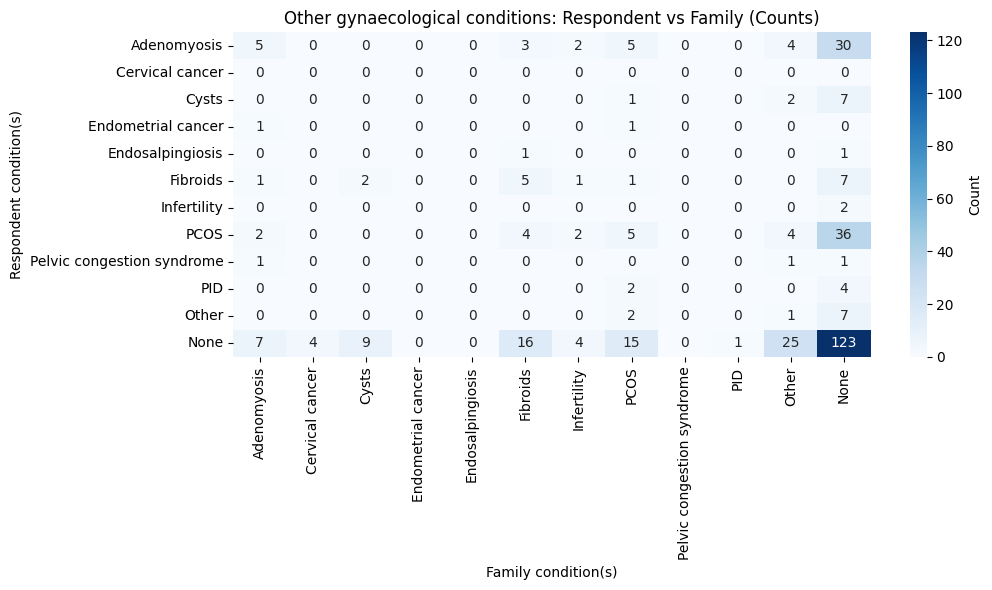

In [443]:
# Short maps (keep original labels for now)
left_short_map = None   # or provide dict to shorten labels
right_short_map = None  # same

# Preferred display order (edit as you like)
ordered_categories = [    
    "Adenomyosis",
    "Cervical cancer",
    "Cysts",
    "Endometrial cancer",
    "Endosalpingiosis",
    "Fibroids",
    "Infertility",
    "PCOS",
    "Pelvic congestion syndrome",
    "PID",
    "Other",
    "None",
]

COL_A = "Please list any other gynaecological conditions you have been diagnosed with "
COL_B = "If they have been diagnosed with another gynaecological condition please list it below"

res_gyn = two_way_assoc_with_heatmaps(
    df=Survey_endo_only,
    left_col=COL_A,
    right_col=COL_B,
    left_map_func=map_gyn_other_multilabel,
    right_map_func=map_gyn_other_multilabel,
    left_short_map=left_short_map,    # identity
    right_short_map=right_short_map,  # identity
    row_order=ordered_categories,     # rows (COL_A)
    col_order=ordered_categories,     # cols (COL_B)
    title_prefix="Other gynaecological conditions: Respondent vs Family",
    left_axis_label="Respondent condition(s)",
    right_axis_label="Family condition(s)",
    percent_cmap="Blues",
    or_cmap="coolwarm",
    alpha=0.05,
    show_plots=True,
    multi_label_left=True,
    multi_label_right=True, 
    rows_from="left",


)

Contingency table (counts):
      No  Yes
Yes   80   36
No   123   71


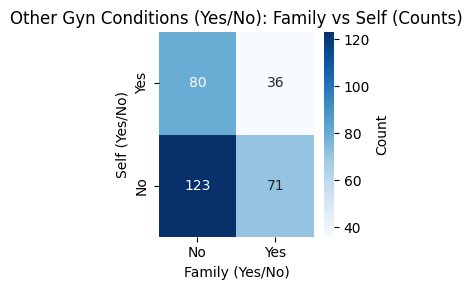

In [444]:
# Map to yes and no categories

# -----------------------
# YES / NO mapping
# -----------------------
def to_yes_no(cats):
    if not isinstance(cats, list):
        return "No"
    return "No" if cats == ["None"] else "Yes"


# -----------------------
# Build binary columns
# -----------------------
Survey_endo_only["self_gyn_bin"] = (
    Survey_endo_only[COL_A]
    .apply(map_gyn_other_multilabel)
    .apply(to_yes_no)
)

Survey_endo_only["family_gyn_bin"] = (
    Survey_endo_only[COL_B]
    .apply(map_gyn_other_multilabel)
    .apply(to_yes_no)
)

# Clean (avoid hidden string issues)
Survey_endo_only["self_gyn_bin"] = Survey_endo_only["self_gyn_bin"].astype(str).str.strip()
Survey_endo_only["family_gyn_bin"] = Survey_endo_only["family_gyn_bin"].astype(str).str.strip()


# -----------------------
# Order (same style as your previous analysis)
# -----------------------
row_order = ["No", "Yes"]
col_order = ["Yes", "No"]


# -----------------------
# Run analysis
# -----------------------
res_gyn_yesno = two_way_assoc_with_heatmaps(
    df=Survey_endo_only,
    left_col="family_gyn_bin",
    right_col="self_gyn_bin",
    left_map_func=lambda x: x,
    right_map_func=lambda x: x,
    row_order=row_order,
    col_order=col_order,
    title_prefix="Other Gyn Conditions (Yes/No): Family vs Self",
    left_axis_label="Family (Yes/No)",
    right_axis_label="Self (Yes/No)",
    percent_cmap="Blues",
    or_cmap="coolwarm",
    alpha=0.05,
    show_plots=True,
    multi_label_left=False,
    multi_label_right=False,
    rows_from="right",
    percent_figsize=(3, 3),
 
)




## Autoimmune and chronic inflammatory conditions

In [446]:
# Is there any history of autoimmune disease or chronic inflammatory disease in your family

In [447]:
Survey_endo_only["Is there any history of autoimmune disease or chronic inflammatory disease in your family"].apply(type).value_counts()

Is there any history of autoimmune disease or chronic inflammatory disease in your family
<class 'str'>      190
<class 'float'>    120
Name: count, dtype: int64

In [448]:
Survey_endo_only["Is there any history of autoimmune disease or chronic inflammatory disease in your family"].count()

190

In [449]:
Survey_endo_only["Is there any history of autoimmune disease or chronic inflammatory disease in your family"].isna().sum()

120

In [450]:
# Check responses
common_items = (
    Survey_endo_only['Is there any history of autoimmune disease or chronic inflammatory disease in your family']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 1].head(50))

Is there any history of autoimmune disease or chronic inflammatory disease in your family
heart disease                71
ra (rheumatoid arthritis)    65
type 1 diabetes              53
ms (multiple sclerosis)      25
crohn's disease              24
lupus                        10
ulcerative colitis            4
no                            3
fibromyalgia                  3
hashimoto                     3
diverticulitis                2
hypothyroidism                2
psoriasis                     2
polymyalgia                   2
Name: count, dtype: int64


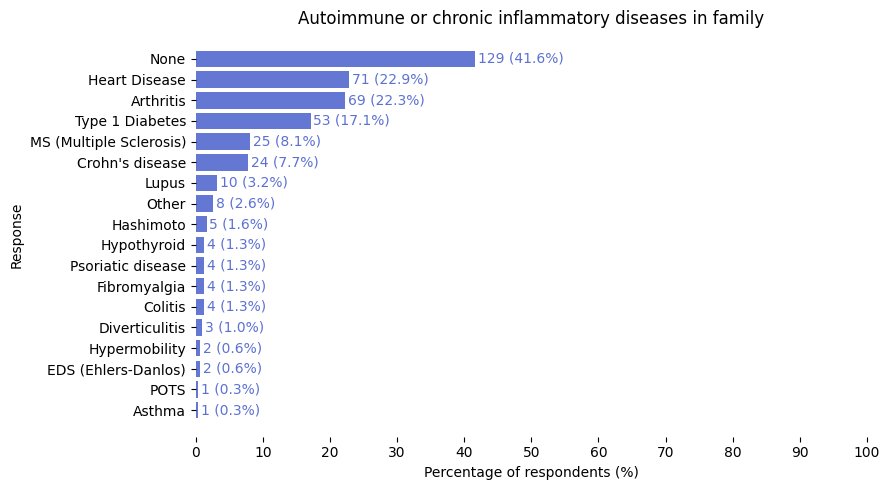

In [451]:
QUESTION_COL = "Is there any history of autoimmune disease or chronic inflammatory disease in your family"

# Custom category mapper with your priority logic 
def map_immune_multilabel(raw: str):
    if raw is None:
        return ["None"]

    s = str(raw).strip()
    sn = s.casefold()

    # Detect 'None' meanings 
    none_patterns = [
        r'\bnone\b', r'\bno other\b', r'\bno\b', 
        r'\bn/?a\b', r'\bnil\b'
    ]
    if any(re.search(p, sn) for p in none_patterns):
        return ["None"]

    categories_found = []

    # Other categories (can all co-occur) 
    patterns = {
        "MS (Multiple Sclerosis)": ["ms", "multiple sclerosis", "mulitple sclerosos", "m.s."],
        "Arthritis": ["rheumatoid arthritis", "arthritis", "osteoarthritis", "arthrtis", "arthiritis"],
        "Heart Disease": ["heart disease", "cardiac disease", "cardiovascular disease","heart condition", "coronary disease","heart"],
        "Type 1 Diabetes": ["type 1 diabetes", "t1d", "t1dm", "type i diabetes"],
        "Lupus": ["lupus", "sle", "systemic lupus"],
        "Psoriatic disease": ["psoriasis", "psorasis", "psor"],
        "Crohn's disease": ["Crohn's disease","Crohns disease","crohn's disease"],
        "Colitis": ["ulcerative colitis", "uc", "ulcerative", "colitis"],
        "Fibromyalgia": ["fibromyalgia", "fibromialgia"],
        "Diverticulitis": ["diverticulitis", "divertic", "diverticulosis"],
        "POTS": ["pots", "postural tachycardia", "postural orthostatic"],
        "GERD": ["gerd", "reflux", "acid reflux", "gastroesophageal reflux"],
        "EDS (Ehlers-Danlos)": ["eds", "ehlers danlos", "ehlers-danlos", "ehlers", "danlos","heds"],
        "Migraines": ["migraine", "migraines", "migrenes"],
        "Glandular fever": ["glandular fever", "mono", "mononucleosis"],
        "Hypermobility": ["hypermobility", "hypermobile", "jhs", "joint hypermobility"],
        "Chronic fatigue": ["fatigue", "chronic fatigue", "cfs", "chronic fatigue syndrome","me/cfs", "m.e."],
        "Cystitis": ["cystitis"],
        "Polycystic kidneys": ["Polycystic kidney"],
        "Hashimoto": ["hashimoto", "hashimotos", "hashimoto's"],
        "Graves": ["graves", "graves disease"],
        "Hypothyroid": ["hypothyroid", "hypothyroidism", "underactive thyroid","low thyroid","under active thyroid"],
        "Asthma": ["asthma", "asmtha"],
        "PCOS": ["pcos", "polycystic ovary", "polycystic ovarian"],
        "IBS": ["ibs", "irritable bowel"],
        "Adenomyosis": ["adenomyosis", "adeno"],
        "None": ["unknown", "none", "not", "no", "n/a", "nil", "none reported"]
    }

    
    for label, patterns_list in patterns.items():
        for p in patterns_list:
            if re.search(p, sn):
                categories_found.append(label)
                break  # avoid duplicate insertion

    # If nothing matched yet → assign "Other" 
    if len(categories_found) == 0:
        return ["Other"]

    return categories_found


# Plot
out = plot_single_question(
    df=Survey_endo_only,
    question_col=QUESTION_COL,
    category_func=map_immune_multilabel,
    multi_label=True, 
    na_to_category="None",
    remove_values=(),             # count everyone
    rescale_to_100=True,         # % of respondents
    sort_by="count_desc", 
    chart="barh",
    fig_title="Autoimmune or chronic inflammatory diseases in family",
    y_label="Response",
    figsize=(9,5), 
)

In [452]:
# How are they related to you

In [453]:
Survey_endo_only["How are they related to you"].apply(type).value_counts()

How are they related to you
<class 'str'>      222
<class 'float'>     88
Name: count, dtype: int64

In [454]:
Survey_endo_only["How are they related to you"].count()

222

In [455]:
Survey_endo_only["How are they related to you"].isna().sum()

88

In [456]:
# Check for any other itemas I may include 
common_items = (
    Survey_endo_only['How are they related to you']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 0].head(50))

How are they related to you
mother                                         90
aunt/uncle                                     79
grandparent                                    69
father                                         53
sibling                                        40
cousin                                         37
son                                             2
type 1 diabetes strong on my father’s side.     1
nothing                                         1
twin sister too                                 1
nephew. food allergies & type 1 diabetes        1
great grandmother                               1
niece with type1 diabetes                       1
mat aunt had it confirmed                       1
sister suspects possible endo diagnosis         1
n/a                                             1
self                                            1
myself plus mothers side                        1
i have ra                                       1
Name: count, dtype: in

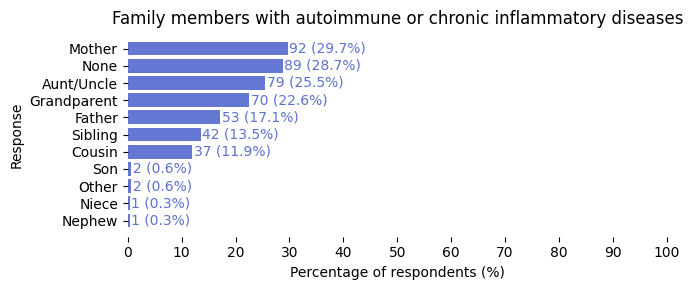

In [457]:
QUESTION_COL = "How are they related to you"

# Custom category mapper with your priority logic 
def map_relate_multilabel(raw: str):
    if raw is None:
        return ["None"]

    s = str(raw).strip()
    sn = s.casefold()

    # Detect 'None' meanings 
    none_patterns = [
        r'\bnone\b', r'\bno other\b', r'\bno\b', 
        r'\bn/?a\b', r'\bnil\b'
    ]
    if any(re.search(p, sn) for p in none_patterns):
        return ["None"]

    categories_found = []

    # Other categories (can all co-occur) 
    patterns = {
        "Mother": ["mother"],
        "Father": ["father"],
        "Grandparent": ["grandparent","grandfather","grandmother" ],
        "Sibling": ["sibling", "sister","brother"],
        "Son": ["son"],
        "Daughter": ["daughter"],
        "Aunt/Uncle": ["aunt/uncle"],
        "Cousin": ["cousin"],
        "Niece": ["niece"],
        "Nephew": ["nephew"],
    }
 
    for label, patterns_list in patterns.items():
        for p in patterns_list:
            if re.search(p, sn):
                categories_found.append(label)
                break  # avoid duplicate insertion

    #  If nothing matched yet → assign "Other" 
    if len(categories_found) == 0:
        return ["Other"]

    return categories_found


# Plot
out = plot_single_question(
    df=Survey_endo_only,
    question_col=QUESTION_COL,
    category_func=map_relate_multilabel,
    multi_label=True, 
    na_to_category="None",
    remove_values=(),             # count everyone
    rescale_to_100=True,         # % of respondents
    sort_by="count_desc", 
    chart="barh",
    fig_title="Family members with autoimmune or chronic inflammatory diseases",
    y_label="Response",
    )

# Correlation family vs patients- other chronic inflammatory or autoimmune conditions

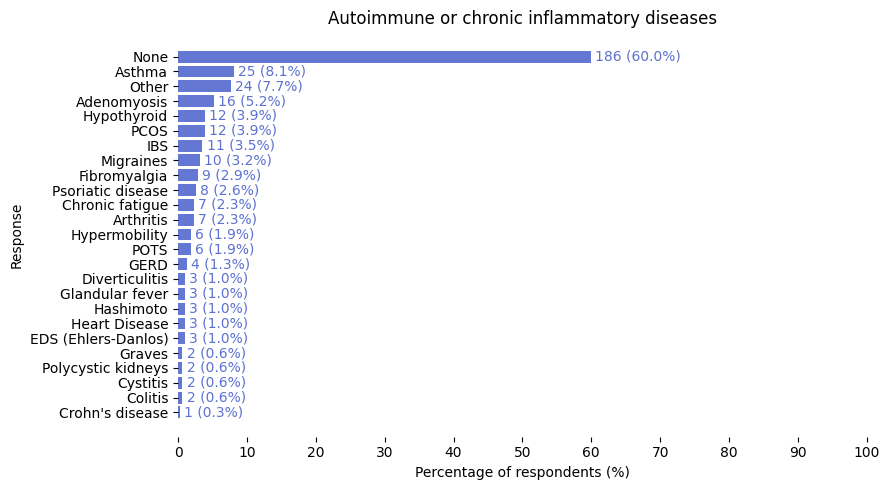

In [459]:
# Chronic and autoimmune conditions together
# joint column analyses

# Columns
COL1 = "If yes to either of the two above questions, please list these conditions if you can"
COL2 = "Have you been diagnosed with any autoimmune conditions or autoimmune antibodies?"

# Sets to interpret "no content" / admin answers (all lower-case strings)
IGNORE2 = {"yes", "no", "unsure", "n/a", "na", ""}  # for column 2 admin answers
NONE_WORDS = {"none", "no other", "nil", "no", "n/a", "na", ""}  # general empty/none words

def normalize(x):
    """Return a lower-cased string with NaN/None mapped to empty string."""
    if x is None:
        return ""
    # Catch floats that are NaN
    if isinstance(x, float) and math.isnan(x):
        return ""
    s = str(x).strip()
    # Also treat literal 'nan' strings as empty
    if s.casefold() in {"nan"}:
        return ""
    return s.casefold()

def map_immune_multilabel(raw):
    """Map raw free-text to a list of normalized condition labels."""
    # Normalize early
    s = "" if raw is None else str(raw).strip()
    sn = s.casefold()

    # Normalize admin responses and blanks to None 
    if sn in {"", "no", "none", "no other", "unsure", "yes", "y", "n", "n/a", "na", "nan"}:
        return ["None"]

    #  Patterns 
    patterns = {
        "MS (Multiple Sclerosis)": ["ms", "multiple sclerosis", "mulitple sclerosos", "m.s."],
        "Arthritis": ["rheumatoid arthritis", "arthritis", "osteoarthritis", "arthrtis", "arthiritis"],
        "Heart Disease": ["heart disease", "cardiac disease", "cardiovascular disease","heart condition", "coronary disease","heart"],
        "Type 1 Diabetes": ["type 1 diabetes", "t1d", "t1dm", "type i diabetes"],
        "Lupus": ["lupus", "sle", "systemic lupus"],
        "Psoriatic disease": ["psoriasis", "psorasis", "psor"],
        "Crohn's disease": ["Crohn's disease","Crohns disease","crohn's disease"],
        "Colitis": ["ulcerative colitis", "uc", "ulcerative", "colitis"],
        "Fibromyalgia": ["fibromyalgia", "fibromialgia"],
        "Diverticulitis": ["diverticulitis", "divertic", "diverticulosis"],
        "POTS": ["pots", "postural tachycardia", "postural orthostatic"],
        "GERD": ["gerd", "reflux", "acid reflux", "gastroesophageal reflux"],
        "EDS (Ehlers-Danlos)": ["eds", "ehlers danlos", "ehlers-danlos", "ehlers", "danlos","heds"],
        "Migraines": ["migraine", "migraines", "migrenes"],
        "Glandular fever": ["glandular fever", "mono", "mononucleosis"],
        "Hypermobility": ["hypermobility", "hypermobile", "jhs", "joint hypermobility"],
        "Chronic fatigue": ["fatigue", "chronic fatigue", "cfs", "chronic fatigue syndrome","me/cfs", "m.e."],
        "Cystitis": ["cystitis"],
        "Polycystic kidneys": ["Polycystic kidney"],
        "Hashimoto": ["hashimoto", "hashimotos", "hashimoto's"],
        "Graves": ["graves", "graves disease"],
        "Hypothyroid": ["hypothyroid", "hypothyroidism", "underactive thyroid","low thyroid", "under active thyroid"],
        "Asthma": ["asthma", "asmtha"],
        "PCOS": ["pcos", "polycystic ovary", "polycystic ovarian"],
        "IBS": ["ibs", "irritable bowel"],
        "Adenomyosis": ["adenomyosis", "adeno"],
        "None": ["unknown", "none", "not", "no", "n/a", "nil", "none reported"]
    }

    categories_found = []

    # Use word boundaries for short acronyms to avoid false positives
    boundary_tokens = {"ms", "ra", "uc", "eds", "sle", "t1d"}
    for label, plist in patterns.items():
        for p in plist:
            p_norm = p.casefold()
            if p_norm in boundary_tokens:
                if re.search(rf"\b{re.escape(p_norm)}\b", sn):
                    categories_found.append(label)
                    break
            else:
                if p_norm in sn:
                    categories_found.append(label)
                    break

    if not categories_found:
        return ["Other"]
    return categories_found

def combine_two_condition_columns(row):
    """Merge categories from both columns and remove duplicates, 
       ignoring admin responses in column 2 and returning 'None' when appropriate."""
    raw1_norm = normalize(row[COL1])
    raw2_norm = normalize(row[COL2])

    # If both columns have no useful text, return ["None"]
    raw1_is_none = (raw1_norm in NONE_WORDS)
    raw2_is_none_or_ignore = (raw2_norm in IGNORE2 or raw2_norm in NONE_WORDS)
    if raw1_is_none and raw2_is_none_or_ignore:
        return ["None"]

    # Map column 1 normally
    cats1 = map_immune_multilabel(row[COL1])

    # Only map column 2 if it contains meaningful text (not yes/no/unsure/etc.)
    if raw2_norm in IGNORE2 or raw2_norm in NONE_WORDS:
        cats2 = []
    else:
        cats2 = map_immune_multilabel(row[COL2])

    # Combine & dedupe
    combined = list(dict.fromkeys(cats1 + cats2))

    # Prefer recognized categories; drop 'None'/'Other' if real categories exist
    real = [c for c in combined if c not in ("None", "Other")]
    if real:
        return real
    if "None" in combined:
        return ["None"]
    if "Other" in combined:
        return ["Other"]
    return ["None"]  # very defensive fallback

# Build merged list column
Survey_endo_only["combined_autoimmune"] = (
    Survey_endo_only.apply(combine_two_condition_columns, axis=1)
)

# Convert lists → comma-separated strings for plotting
Survey_endo_only["combined_autoimmune_str"] = (
    Survey_endo_only["combined_autoimmune"]
    .apply(lambda x: ", ".join(x) if isinstance(x, list) else x)
)

# Allowed categories for the plot
ALLOWED = [
    "MS (Multiple Sclerosis)", "Arthritis", "Heart Disease", "Type 1 Diabetes",
    "Lupus", "Psoriatic disease", "Crohn's disease", "Colitis",
    "Fibromyalgia", "Diverticulitis", "POTS", "GERD",
    "EDS (Ehlers-Danlos)", "Migraines", "Glandular fever", "Hypermobility",
    "Chronic fatigue", "Cystitis", "Hashimoto", "Graves", "Hypothyroid",
    "Asthma", "PCOS", "IBS", "Adenomyosis", "Other", "None"
]

# Splitter that always returns a list
splitter = lambda s: (["None"] if pd.isna(s) else [t.strip() for t in str(s).split(",") if t.strip()])

# Plot
out = plot_single_question(
    df=Survey_endo_only,
    question_col="combined_autoimmune_str",
    category_func=splitter,           # split the comma-separated string
    multi_label=True,
    allowed_answers=ALLOWED,          # tell the function the valid labels
    na_to_category="None",
    remove_values=(),
    rescale_to_100=True,
    sort_by="count_desc",
    chart="barh",
    fig_title="Autoimmune or chronic inflammatory diseases",
    y_label="Response",
    figsize=(9,5), 
)

# Correlation of autoimmune or chronic inflammatory diseases- patients vs family

In [461]:
# Correlation of autoimmune and chronic inflammatory conditions- family vs patients

Contingency table (counts):
                   Adenomyosis  Arthritis  Asthma  CFS/ME  Colitis  Crohn's disease  Cystitis  Diverticulitis  EDS  Fibromyalgia  GERD  Glandular fever  Graves  Hashimoto  Heart Disease  Hypermobility  Hypothyroid  IBS  Lupus  Migraines  MS  PCOS  PKD  POTS  Psoriatic disease  T1D  Other  None
Adenomyosis                  0          5       0       0        0                5         0               1    0             0     0                0       0          1              6              0            0    0      1          0   1     0    0     0                  2    5      0     3
Arthritis                    0          6       0       0        0                1         0               0    0             1     0                0       0          0              2              0            0    0      1          0   1     0    0     0                  1    0      0     0
Asthma                       0          7       1       0        0                2    

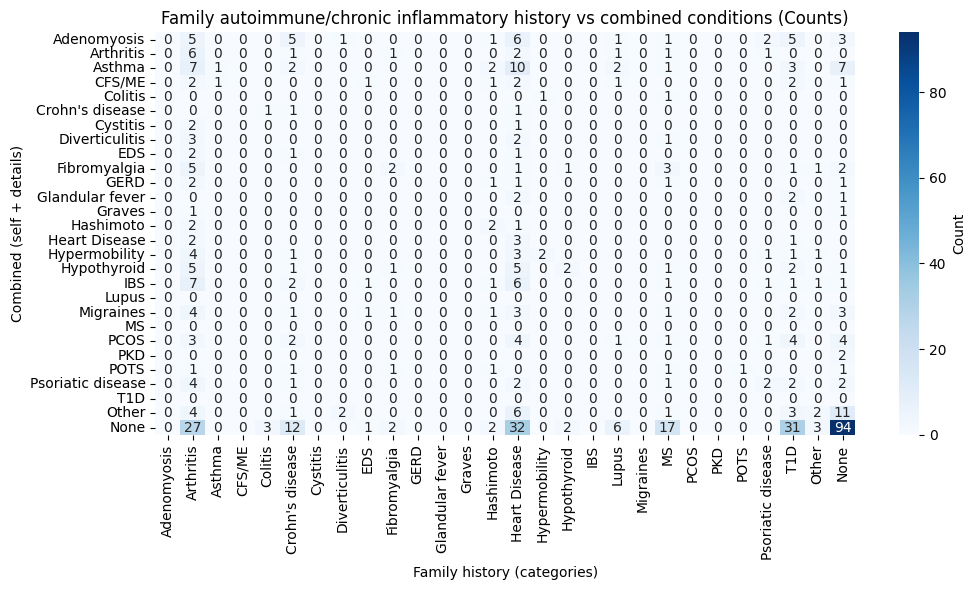

In [462]:
QUESTION_COLA = "Is there any history of autoimmune disease or chronic inflammatory disease in your family"
COL1 = "If yes to either of the two above questions, please list these conditions if you can"
COL2 = "Have you been diagnosed with any autoimmune conditions or autoimmune antibodies?"

# Sets to interpret "no content" / admin answers (all lower-case strings)
IGNORE2 = {"yes", "no", "unsure", "n/a", "na", ""}  # for COL2 admin/yes-no answers
NONE_WORDS = {"none", "no other", "nil", "no", "n/a", "na", ""}  # general empty/none words

def normalize(x):
    """Lower-cases, trims, and maps NaN/None to empty string."""
    if x is None:
        return ""
    if isinstance(x, float) and math.isnan(x):
        return ""
    s = str(x).strip()
    if s.casefold() in {"nan"}:
        return ""
    return s.casefold()

def map_autoimmune_multilabel(raw):
    """
    Map raw free-text to a list of normalized condition labels.
    Returns ["None"] for blanks/admin (yes/no/unsure).
    Uses word boundaries for short acronyms to avoid false positives.
    """
    s = "" if raw is None else str(raw).strip()
    sn = s.casefold()

    # Normalize admin/blank responses to "None"
    if sn in {"", "no", "none", "no other", "unsure", "yes", "y", "n", "n/a", "na", "nan"}:
        return ["None"]

    # Patterns (labels are the canonical category names you’ll see in tables/plots)
    patterns = {
        "MS (Multiple Sclerosis)": ["ms", "multiple sclerosis", "m.s."],
        "Arthritis": ["rheumatoid arthritis", "arthritis", "osteoarthritis", "arthrtis", "arthiritis"],
        "Heart Disease": ["heart disease", "cardiac disease", "cardiovascular disease", "heart condition", "coronary disease", "heart"],
        "Type 1 Diabetes": ["type 1 diabetes", "t1d", "t1dm", "type i diabetes"],
        "Lupus": ["lupus", "sle", "systemic lupus"],
        "Psoriatic disease": ["psoriasis", "psorasis", "psor"],
        "Crohn's disease": ["crohn's disease", "crohns disease", "crohn’s disease", "crohn"],
        "Colitis": ["ulcerative colitis", "uc", "ulcerative", "colitis"],
        "Fibromyalgia": ["fibromyalgia", "fibromialgia"],
        "Diverticulitis": ["diverticulitis", "divertic", "diverticulosis"],
        "POTS": ["pots", "postural tachycardia", "postural orthostatic"],
        "GERD": ["gerd", "reflux", "acid reflux", "gastroesophageal reflux"],
        "EDS (Ehlers-Danlos)": ["eds", "ehlers danlos", "ehlers-danlos", "ehlers", "danlos", "heds"],
        "Migraines": ["migraine", "migraines", "migrenes"],
        "Glandular fever": ["glandular fever", "mono", "mononucleosis"],
        "Hypermobility": ["hypermobility", "hypermobile", "jhs", "joint hypermobility"],
        "Chronic fatigue": ["fatigue", "chronic fatigue", "cfs", "chronic fatigue syndrome", "me/cfs", "m.e."],
        "Cystitis": ["cystitis"],
        "Polycystic kidneys": ["polycystic kidney", "polycystic kidneys"],
        "Hashimoto": ["hashimoto", "hashimotos", "hashimoto's"],
        "Graves": ["graves", "graves disease"],
        "Hypothyroid": ["hypothyroid", "hypothyroidism", "underactive thyroid", "low thyroid", "under active thyroid"],
        "Asthma": ["asthma", "asmtha"],
        "PCOS": ["pcos", "polycystic ovary", "polycystic ovarian"],
        "IBS": ["ibs", "irritable bowel"],
        "Adenomyosis": ["adenomyosis", "adeno"],
        "None": ["unknown", "none", "not", "no", "n/a", "nil", "none reported"]
    }

    categories_found = []

    # Use word boundaries for short acronyms/tokens
    boundary_tokens = {"ms", "ra", "uc", "eds", "sle", "t1d"}
    for label, plist in patterns.items():
        for p in plist:
            p_norm = p.casefold()
            if p_norm in boundary_tokens:
                if re.search(rf"\b{re.escape(p_norm)}\b", sn):
                    categories_found.append(label)
                    break
            else:
                if p_norm in sn:
                    categories_found.append(label)
                    break

    if not categories_found:
        return ["Other"]
    # Deduplicate, preserve order
    seen, out = set(), []
    for x in categories_found:
        if x not in seen:
            seen.add(x)
            out.append(x)
    return out

def combine_autoimmune_cols(row):
    """
    Merge categories from COL1 and COL2 and remove duplicates,
    ignoring admin/yes-no responses in COL2 and returning 'None' when appropriate.
    """
    raw1_norm = normalize(row[COL1])
    raw2_norm = normalize(row[COL2])

    # If both columns have no useful text, return ["None"]
    raw1_is_none = (raw1_norm in NONE_WORDS)
    raw2_is_none_or_ignore = (raw2_norm in IGNORE2 or raw2_norm in NONE_WORDS)
    if raw1_is_none and raw2_is_none_or_ignore:
        return ["None"]

    # Map column 1 normally
    cats1 = map_autoimmune_multilabel(row[COL1])

    # Only map column 2 if it contains meaningful text (not yes/no/unsure/etc.)
    if raw2_norm in IGNORE2 or raw2_norm in NONE_WORDS:
        cats2 = []
    else:
        cats2 = map_autoimmune_multilabel(row[COL2])

    # Combine & dedupe
    combined = list(dict.fromkeys(cats1 + cats2))

    # Prefer recognized categories; drop 'None'/'Other' if real categories exist
    real = [c for c in combined if c not in ("None", "Other")]
    if real:
        return real
    if "None" in combined:
        return ["None"]
    if "Other" in combined:
        return ["Other"]
    return ["None"]

# Build merged right-hand list column ---
Survey_endo_only = Survey_endo_only.copy()
Survey_endo_only["combined_autoimmune"] = Survey_endo_only.apply(combine_autoimmune_cols, axis=1)

# Compact labels for plots/tables 
SHORT_MAP = {
    "MS (Multiple Sclerosis)": "MS",
    "Type 1 Diabetes": "T1D",
    "EDS (Ehlers-Danlos)": "EDS",
    "Chronic fatigue": "CFS/ME",
    "Polycystic kidneys": "PKD",
}

# Build the preferred order of categories for rows/cols (edit as desired)
ORDER_LONG = [
    "Adenomyosis", "Arthritis", "Asthma", "Chronic fatigue", "Colitis", "Crohn's disease", 
    "Cystitis", "Diverticulitis", "EDS (Ehlers-Danlos)", "Fibromyalgia", "GERD",
    "Glandular fever", "Graves", "Hashimoto", "Heart Disease", "Hypermobility", "Hypothyroid",
    "IBS", "Lupus", "Migraines", "MS (Multiple Sclerosis)", "PCOS", "Polycystic kidneys", "POTS",
    "Psoriatic disease", "Type 1 Diabetes", "Other", "None"
]
# Map order through SHORT_MAP if provided
if SHORT_MAP:
    ORDER_SHORT = [SHORT_MAP.get(x, x) for x in ORDER_LONG]
else:
    ORDER_SHORT = ORDER_LONG

# Plot
res_autoimmune = two_way_assoc_with_heatmaps(
    df=Survey_endo_only,
    left_col=QUESTION_COLA,                # family history free-text
    right_col="combined_autoimmune",       # merged categories from COL1+COL2
    left_map_func=map_autoimmune_multilabel,
    right_map_func=lambda x: x,            # already a list of categories
    left_short_map=SHORT_MAP,              # compact labels (optional)
    right_short_map=SHORT_MAP,             # compact labels (optional)
    row_order=ORDER_SHORT,                 # display order
    col_order=ORDER_SHORT,                 # display order
    title_prefix="Family autoimmune/chronic inflammatory history vs combined conditions",
    left_axis_label="Family history (categories)",
    right_axis_label="Combined (self + details)",
    percent_cmap="Blues",
    or_cmap="coolwarm",
    alpha=0.05,
    show_plots=True,
    multi_label_left=True,                 # left is multi-label after mapping
    multi_label_right=True,                 # right is already multi-label
    rows_from="right", 

)

Contingency table (counts):
     No  Yes
Yes  33   91
No   94   92


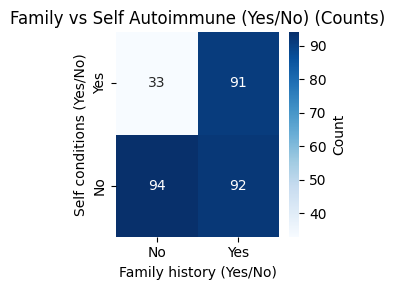

In [463]:
# Map to yes and no

def to_yes_no_from_combined(cats):
    """
    Preserve original classification:
    - 'None' → No
    - anything else (including 'Other') → Yes
    """
    if not isinstance(cats, list):
        return "No"
    
    # EXACT preservation from above
    if cats == ["None"]:
        return "No"
    
    return "Yes"


Survey_endo_only["self_autoimmune_bin"] = (
    Survey_endo_only["combined_autoimmune"]
    .apply(to_yes_no_from_combined)
)

Survey_endo_only["family_autoimmune_mapped"] = (
    Survey_endo_only[QUESTION_COLA]
    .apply(map_autoimmune_multilabel)
)

Survey_endo_only["family_autoimmune_bin"] = (
    Survey_endo_only["family_autoimmune_mapped"]
    .apply(lambda cats: "No" if cats == ["None"] else "Yes")
)

# Preferred order
row_order = ["No", "Yes"]   # rows = Self (to keep consistency with your previous orientation)
col_order = ["Yes", "No"]   # cols = Family


res_yesno = two_way_assoc_with_heatmaps(
    df=Survey_endo_only,
    left_col="family_autoimmune_bin",
    right_col="self_autoimmune_bin",
    left_map_func=lambda x: x,      # already Yes/No
    right_map_func=lambda x: x,     # already Yes/No
    row_order=row_order,
    col_order=col_order,
    title_prefix="Family vs Self Autoimmune (Yes/No)",
    left_axis_label="Family history (Yes/No)",
    right_axis_label="Self conditions (Yes/No)",
    percent_cmap="Blues",
    or_cmap="coolwarm",
    alpha=0.05,
    show_plots=True,
    multi_label_left=False,
    multi_label_right=False,
    rows_from="right",
    percent_figsize=(3, 3),
 
)

## Cancer

In [465]:
# Is there any history of cancer in your family? 

In [466]:
Survey_endo_only["Is there any history of cancer in your family?"].apply(type).value_counts()

Is there any history of cancer in your family?
<class 'str'>      307
<class 'float'>      3
Name: count, dtype: int64

In [467]:
Survey_endo_only["Is there any history of cancer in your family?"].count()

307

In [468]:
Survey_endo_only["Is there any history of cancer in your family?"].isna().sum()

3

In [469]:
# Check for any other itemas I may include 
common_items = (
    Survey_endo_only['Is there any history of cancer in your family?']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 0].head(50))

Is there any history of cancer in your family?
yes                                                                                                          227
no                                                                                                            70
unknown                                                                                                        1
lukemia                                                                                                        1
grandmother had brain tumor at 50                                                                              1
n/a                                                                                                            1
my grandmother on my father's side had breast cancer. my grandmother on mother's side had stomach cancer.      1
grand father                                                                                                   1
father                                           

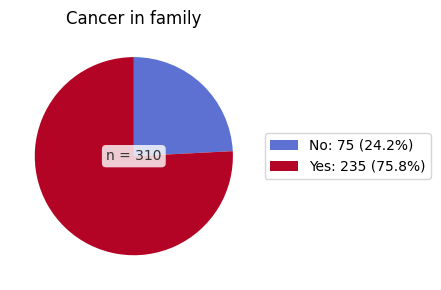

In [470]:
QUESTION_COL = "Is there any history of cancer in your family?"

# Define categories: label + color
CATEGORIES = [
    ("No",  "#5c71d1"),  # blue
    ("Yes", "#b40426")   # red
]
cat_order  = [label for label, _ in CATEGORIES]
pie_colors = dict(CATEGORIES)

# Normalizer: map raw text -> "Yes"/"No" 
def map_yes_no(raw):
    """
    Rule:
      - No  := unknown, none, nothing, na/n/a, no, nil, empty/whitespace
      - Yes := anything else
    """
    if raw is None:
        return "No"

    s = str(raw).strip()
    if s == "":
        return "No"

    sn = s.casefold()

    # Patterns that count as "No"
    no_patterns = [
        r"\bno\b",
        r"\bnone\b",
        r"\bnil\b",
        r"\bn/?a\b",           # na, n/a
        r"\bnot\s*sure\b",
        r"\bunsure\b",
        r"\bunknown\b",
        r"\bnothing\b",
        r"\bno\s+history\b",
        r"\bno\s+family\s+history\b",
    ]

    if any(re.search(p, sn) for p in no_patterns):
        return "No"

    # Otherwise -> Yes
    return "Yes"

# Plot
out = plot_single_question(
    df=Survey_endo_only,
    question_col=QUESTION_COL,
    multi_label=False,
    allowed_answers=cat_order,      # enforce Yes/No only
    category_func=map_yes_no,       # <— use the normalizer
    include_other=False,            # nothing outside Yes/No
    remove_values=(),               # keep all; mapper handles empties/NA as "No"
    sort_by=None,
    category_order=cat_order,
    chart="pie",
    fig_title="Cancer in family",
    y_label=None,
    pie_colors=pie_colors,
    return_data=True,
    display=True
)


## Allergy in family

In [472]:
# Is there anyone with any allergies in your family?

In [473]:
Survey_endo_only["Is there anyone with any allergies in your family?"].apply(type).value_counts()

Is there anyone with any allergies in your family?
<class 'str'>      307
<class 'float'>      3
Name: count, dtype: int64

In [474]:
Survey_endo_only["Is there anyone with any allergies in your family?"].count()

307

In [475]:
Survey_endo_only["Is there anyone with any allergies in your family?"].isna().sum()

3

In [476]:
# Check for any other itemas I may include 
common_items = (
    Survey_endo_only['Is there anyone with any allergies in your family?']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 0].head(50))

Is there anyone with any allergies in your family?
no                     150
yes                    149
unknown                  1
spring eruption          1
asthma hayfever          1
brother - hay fever      1
penicillin               1
n/a                      1
ibuprofen                1
unsure                   1
Name: count, dtype: int64


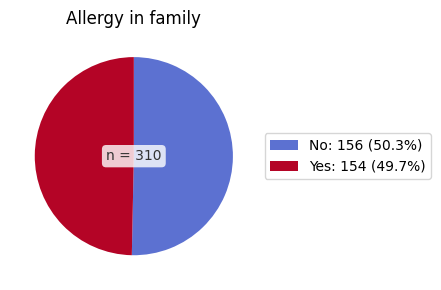

In [477]:
QUESTION_COL = "Is there anyone with any allergies in your family?"

# Define categories: label + color
CATEGORIES = [
    ("No",  "#5c71d1"),  # blue
    ("Yes", "#b40426")   # red
]

cat_order  = [label for label, _ in CATEGORIES]
pie_colors = dict(CATEGORIES)

# Normalizer: map raw text -> "Yes"/"No" 
def map_yes_no(raw):
    """
    Rule:
      - No  := unknown, none, nothing, na/n/a, no, nil, empty/whitespace
      - Yes := anything else
    """
    if raw is None:
        return "No"

    s = str(raw).strip()
    if s == "":
        return "No"

    sn = s.casefold()

    # Patterns that count as "No"
    no_patterns = [
        r"\bno\b",
        r"\bnone\b",
        r"\bnil\b",
        r"\bn/?a\b",           # na, n/a
        r"\bnot\s*sure\b",
        r"\bunsure\b",
        r"\bunknown\b",
        r"\bnothing\b",
        r"\bno\s+history\b",
        r"\bno\s+family\s+history\b",
    ]

    if any(re.search(p, sn) for p in no_patterns):
        return "No"

    # Otherwise -> Yes
    return "Yes"

# Plot
out = plot_single_question(
    df=Survey_endo_only,
    question_col=QUESTION_COL,
    multi_label=False,
    allowed_answers=cat_order,      # enforce Yes/No only
    category_func=map_yes_no,       # <— use the normalizer
    include_other=False,            # nothing outside Yes/No
    remove_values=(),               # keep all; mapper handles empties/NA as "No"
    sort_by=None,
    category_order=cat_order,
    chart="pie",
    fig_title="Allergy in family",
    y_label=None,
    pie_colors=pie_colors,
    return_data=True,
    display=True
)

In [478]:
# If yes, how are they related to you?

In [479]:
Survey_endo_only["If yes, how are they related to you?"].apply(type).value_counts()

If yes, how are they related to you?
<class 'str'>      178
<class 'float'>    132
Name: count, dtype: int64

In [480]:
Survey_endo_only["If yes, how are they related to you?"].count()

178

In [481]:
Survey_endo_only["If yes, how are they related to you?"].isna().sum()

132

In [482]:
# Check for any other itemas I may include 
common_items = (
    Survey_endo_only['If yes, how are they related to you?']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 1].head(50))

If yes, how are they related to you?
sibling        81
mother         67
father         49
grandparent    45
aunt/uncle     35
cousin         22
child          12
myself          3
me              2
Name: count, dtype: int64


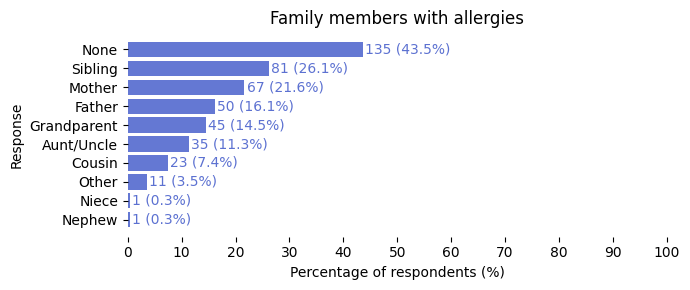

In [483]:
QUESTION_COL = "If yes, how are they related to you?"

# Custom category mapper
def map_relate_multilabel(raw: str):
    if raw is None:
        return ["None"]

    s = str(raw).strip()
    sn = s.casefold()

    # Detect 'None' meanings 
    none_patterns = [
        r'\bnone\b', r'\bno other\b', r'\bno\b', 
        r'\bn/?a\b', r'\bnil\b'
    ]
    if any(re.search(p, sn) for p in none_patterns):
        return ["None"]

    categories_found = []

    # Other categories (can all co-occur)
    patterns = {
        "Mother": ["mother"],
        "Father": ["father"],
        "Grandparent": ["grandparent","grandfather","grandmother" ],
        "Sibling": ["sibling", "sister","brother"],
        "Son": ["son"],
        "Daughter": ["daughter"],
        "Aunt/Uncle": ["aunt/uncle"],
        "Cousin": ["cousin"],
        "Niece": ["niece"],
        "Nephew": ["nephew"],
    }
 
    for label, patterns_list in patterns.items():
        for p in patterns_list:
            if re.search(p, sn):
                categories_found.append(label)
                break  # avoid duplicate insertion

    # If nothing matched yet → assign "Other" 
    if len(categories_found) == 0:
        return ["Other"]

    return categories_found


# Plot
out = plot_single_question(
    df=Survey_endo_only,
    question_col=QUESTION_COL,
    category_func=map_relate_multilabel,
    multi_label=True, 
    na_to_category="None",
    remove_values=(),             # count everyone
    rescale_to_100=True,         # % of respondents
    sort_by="count_desc", 
    chart="barh",
    fig_title="Family members with allergies",
    y_label="Response",
    )

# Correlation family vs patients- allergy

Contingency table (counts):
      No  Yes
Yes   54   78
No   100   76


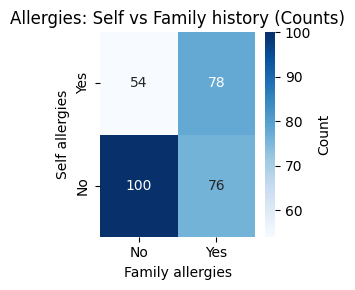

In [485]:
# Specify columns to correlate
COL_A = "Is there anyone with any allergies in your family?"
COL_B = "Are you allergic to anything?"

# Mapping categories (same as individually)
# Family history (rule: "No" for none/na/unsure/empty; "Yes" otherwise)
import re
import numpy as np

def map_yes_no_family(raw):
    """
    Family allergies mapping:
      - 'Yes' -> Yes
      - Explicit negatives (no/none/nil/nothing/na/n/a/no family history) -> No
      - Empty/whitespace -> No
      - 'unknown' / 'unsure' / 'not sure' -> np.nan (drop)
      - Any other text -> Yes
    """

    # Missing Python None or NaN → treat as No (empty)
    if raw is None or (isinstance(raw, float) and pd.isna(raw)):
        return "No"

    s = str(raw).strip()
    if s == "":
        return "No"   # empty = No

    sn = s.casefold()

    # NEGATIVE patterns → No
    no_patterns = [
        r"\bno\b",
        r"\bnone\b",
        r"\bnil\b",
        r"\bn/?a\b",                      # na or n/a
        r"\bnothing\b",
        r"\bno\s+history\b",
        r"\bno\s+family\s+history\b",
    ]
    if any(re.search(p, sn) for p in no_patterns):
        return "No"

    # UNSURE/UNKNOWN → DROP
    if sn in {"unknown", "unsure", "not sure"}:
        return np.nan
        
    # ANY other meaningful text → Yes
    return "Yes"

# Self (map explicit yes/no; treat blanks/NA/unsure as No unless a "yes" token appears)
def map_yes_no_self(raw):
    """
    Self allergies:
      - 'Yes' → Yes
      - 'No'  → No
      - empty/NA/unsure/other garbage → No
    """

    if raw is None or (isinstance(raw, float) and pd.isna(raw)):
        return "No"

    s = str(raw).strip().casefold()
    if s == "":
        return "No"

    if s == "yes":
        return "Yes"

    if s == "no":
        return "No"

    # Everything else = No
    return "No"
    
# Short maps (identity here)
short_map_yesno = {"No": "No", "Yes": "Yes"}

# Preferred order
row_order = ["Yes", "No"]   # rows = Self (to keep consistency with your previous orientation)
col_order = ["No", "Yes"]   # cols = Family

# Plot
res_allergy = two_way_assoc_with_heatmaps(
    df=Survey_endo_only,
    left_col=COL_B,                     # Self (rows)
    right_col=COL_A,                    # Family (columns)
    left_map_func=map_yes_no_self,      # self mapper
    right_map_func=map_yes_no_family,   # family mapper
    left_short_map=short_map_yesno,
    right_short_map=short_map_yesno,
    row_order=row_order,
    col_order=col_order,
    title_prefix="Allergies: Self vs Family history",
    left_axis_label="Self allergies",
    right_axis_label="Family allergies",
    percent_cmap="Blues",
    or_cmap="coolwarm",
    alpha=0.05,
    show_plots=True,
    multi_label_left=False,
    multi_label_right=False,
    rows_from="left",  
    percent_figsize=(3, 3),

)

## Smoking in family

In [487]:
# Are or have your parents or grandparents ever been smokers?

In [488]:
Survey_endo_only["Are or have your parents or grandparents ever been smokers?"].apply(type).value_counts()

Are or have your parents or grandparents ever been smokers?
<class 'str'>      309
<class 'float'>      1
Name: count, dtype: int64

In [489]:
Survey_endo_only["Are or have your parents or grandparents ever been smokers?"].count()

309

In [490]:
Survey_endo_only["Are or have your parents or grandparents ever been smokers?"].isna().sum()

1

In [491]:
# Check responses
common_items = (
    Survey_endo_only['Are or have your parents or grandparents ever been smokers?']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 0].head(50))

Are or have your parents or grandparents ever been smokers?
yes       255
no         46
unsure      8
Name: count, dtype: int64


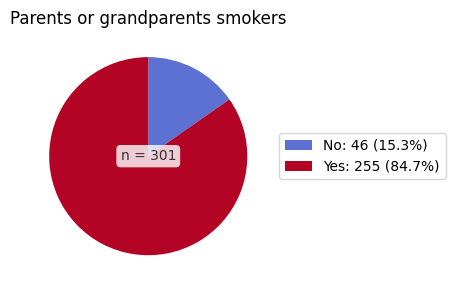

In [492]:
QUESTION_COL = "Are or have your parents or grandparents ever been smokers?"

# Define categories: label + color
CATEGORIES = [
    ("No", "#5c71d1"),  # blue
    ("Yes", "#b40426")  # red
]

cat_order  = [label for label, _ in CATEGORIES]
map_dict   = {label: label for label, _ in CATEGORIES}  
pie_colors = dict(CATEGORIES)

# Plot
out = plot_single_question(
    df=Survey_endo_only,
    question_col=QUESTION_COL,
    multi_label=False,
    allowed_answers=cat_order,
    map_dict=map_dict,
    include_other=False,
    remove_values=("unsure", "none", "", np.nan),  # or remove_values=()
    sort_by=None,
    category_order=cat_order,
    chart="pie",
    fig_title="Parents or grandparents smokers",
    y_label=None,
    pie_colors=pie_colors,
    return_data=True,
    display=True
)

## Obesity in family

In [494]:
# Are or have your parents or grandparents ever suffered from obesity?

In [495]:
Survey_endo_only["Are or have your parents or grandparents ever suffered from obesity?"].apply(type).value_counts()

Are or have your parents or grandparents ever suffered from obesity?
<class 'str'>    310
Name: count, dtype: int64

In [496]:
Survey_endo_only["Are or have your parents or grandparents ever suffered from obesity?"].count()

310

In [497]:
Survey_endo_only["Are or have your parents or grandparents ever suffered from obesity?"].isna().sum()

0

In [498]:
# Check responses
common_items = (
    Survey_endo_only['Are or have your parents or grandparents ever suffered from obesity?']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 0].head(50))

Are or have your parents or grandparents ever suffered from obesity?
no        181
yes       116
unsure     13
Name: count, dtype: int64


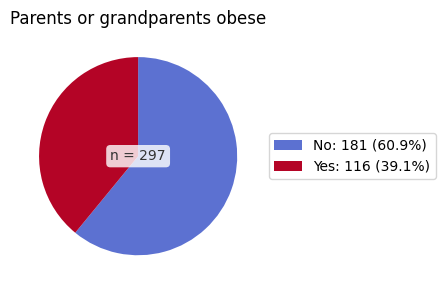

In [499]:
QUESTION_COL = "Are or have your parents or grandparents ever suffered from obesity?"

# Define categories: label + color
CATEGORIES = [
    ("No", "#5c71d1"),  # blue
    ("Yes", "#b40426")  # red
]

cat_order  = [label for label, _ in CATEGORIES]
map_dict   = {label: label for label, _ in CATEGORIES}  
pie_colors = dict(CATEGORIES)

# Plot
out = plot_single_question(
    df=Survey_endo_only,
    question_col=QUESTION_COL,
    multi_label=False,
    allowed_answers=cat_order,
    map_dict=map_dict,
    include_other=False,
    remove_values=("unsure", "none", "", np.nan),  
    sort_by=None,
    category_order=cat_order,
    chart="pie",
    fig_title="Parents or grandparents obese",
    y_label=None,
    pie_colors=pie_colors,
    return_data=True,
    display=True
)

# Correlation family vs patients- weight issues

Contingency table (counts):
      No  Yes
Yes   71   82
No   110   34


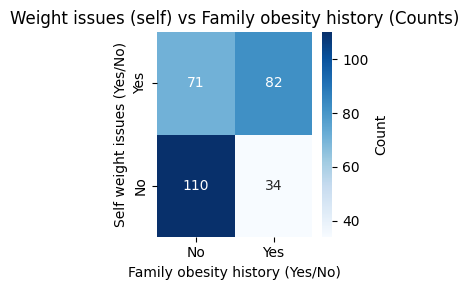

In [501]:
# Columns to correlate
COL_A = "Are or have your parents or grandparents ever suffered from obesity?"
COL_B = "Are you or have you ever suffered from issues with your weight?"

# Define categories to map
categories_map_yes_no = {
    "Yes": [
        "Yes, I am/have been overweight",
        "Yes"
    ],
    "No": [
        "Yes, I am/have been underweight",
        "No, I am usually around a healthy weight",
        "No"
    ]
}

YES_VALUES_B = set(categories_map_yes_no["Yes"])
NO_VALUES_B  = set(categories_map_yes_no["No"])

def map_weight_issues_to_yesno(raw):
    """
    Map B (self weight issues) to 'Yes'/'No' using your categories_map_yes_no.
    - Recognizes raw 3-category labels and 'Yes'/'No'
    - Any other value (incl. blanks/NA) -> NaN (so it gets dropped)
    """
    if raw is None or (isinstance(raw, float) and pd.isna(raw)):
        return np.nan
    s = str(raw).strip()
    if s in YES_VALUES_B:
        return "Yes"
    if s in NO_VALUES_B:
        return "No"

    # Also catch clean 'yes'/'no' just in case
    sn = s.casefold()
    if sn == "yes":
        return "Yes"
    if sn == "no":
        return "No"

    # Everything else (e.g., empty, NA-like) -> drop
    return np.nan

def map_family_obesity_yesno(raw):
    """
    Map A (parents/grandparents obesity history) to Yes/No.
    - 'Yes' -> 'Yes'
    - 'No'  -> 'No'
    - 'Unsure' (or blanks/NA) -> NaN (excluded)
    """
    if raw is None or (isinstance(raw, float) and pd.isna(raw)):
        return np.nan
    sn = str(raw).strip().casefold()
    if sn == "yes":
        return "Yes"
    if sn == "no":
        return "No"
    # Treat 'unsure' (and anything else) as missing -> drop
    if sn in {"unsure", "not sure", "unknown", "n/a", "na", ""}:
        return np.nan
    return np.nan

#  Short labels & display order (identity + consistent order)
row_order = ["Yes", "No"]   # rows = Self (to keep consistency with your previous orientation)
col_order = ["No", "Yes"]   # cols = Family

# Plot
res_obesity_vs_weight = two_way_assoc_with_heatmaps(
    df=Survey_endo_only,
    left_col=COL_B,                        # Self (rows)
    right_col=COL_A,                       # Family (columns)
    left_map_func=map_weight_issues_to_yesno,
    right_map_func=map_family_obesity_yesno,
    left_short_map=short_map_yesno,
    right_short_map=short_map_yesno,
    row_order=row_order,
    col_order=col_order,
    title_prefix="Weight issues (self) vs Family obesity history",
    left_axis_label="Self weight issues (Yes/No)",
    right_axis_label="Family obesity history (Yes/No)",
    percent_cmap="Blues",
    or_cmap="coolwarm",
    alpha=0.05,
    show_plots=True,
    multi_label_left=False,
    multi_label_right=False,
    rows_from="left",                      # keep orientation consistent (Self on rows)
    percent_figsize=(3, 3),
  
)

## Mental problems in family

In [503]:
# Are of have your parents or grandparents ever suffered from mental health problems?

In [504]:
Survey_endo_only["Are of have your parents or grandparents ever suffered from mental health problems?"].apply(type).value_counts()

Are of have your parents or grandparents ever suffered from mental health problems?
<class 'str'>      309
<class 'float'>      1
Name: count, dtype: int64

In [505]:
Survey_endo_only["Are of have your parents or grandparents ever suffered from mental health problems?"].count()

309

In [506]:
Survey_endo_only["Are of have your parents or grandparents ever suffered from mental health problems?"].isna().sum()

1

In [507]:
# Check responses
common_items = (
    Survey_endo_only['Are of have your parents or grandparents ever suffered from mental health problems?']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 0].head(50))

Are of have your parents or grandparents ever suffered from mental health problems?
yes       143
no        105
unsure     61
Name: count, dtype: int64


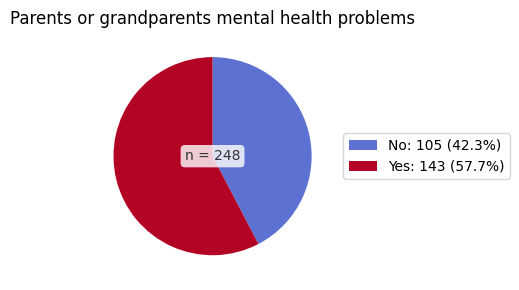

In [508]:
QUESTION_COL = "Are of have your parents or grandparents ever suffered from mental health problems?"

# Define categories: label + color
CATEGORIES = [
    ("No", "#5c71d1"),  # blue
    ("Yes", "#b40426")  # red
]

cat_order  = [label for label, _ in CATEGORIES]
map_dict   = {label: label for label, _ in CATEGORIES}  
pie_colors = dict(CATEGORIES)

# Plot
out = plot_single_question(
    df=Survey_endo_only,
    question_col=QUESTION_COL,
    multi_label=False,
    allowed_answers=cat_order,
    map_dict=map_dict,
    include_other=False,
    remove_values=("unsure", "none", "", np.nan),  
    sort_by=None,
    category_order=cat_order,
    chart="pie",
    fig_title="Parents or grandparents mental health problems",
    y_label=None,
    pie_colors=pie_colors,
    return_data=True,
    display=True
)

# Correlation family vs patients- mental health

Contingency table (counts):
     No  Yes
Yes  65  125
No   40   18


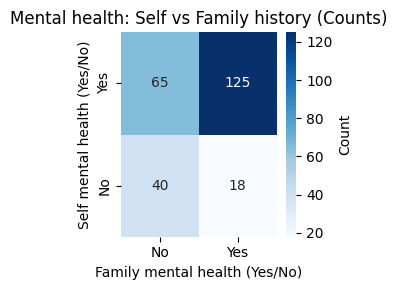

In [510]:
# Select columns to correlate
COL_A = "Are of have your parents or grandparents ever suffered from mental health problems?"
COL_B = "Do/have you ever suffered from mental health problems?"

# Family: Yes/No only; exclude unsure/NaN/blank
def map_family_mh_yesno(raw):
    """
    Map family mental health (A) to Yes/No.
    - 'Yes' -> 'Yes'
    - 'No'  -> 'No'
    - 'Unsure' or blanks/NA/other -> np.nan (dropped)
    """
    if raw is None or (isinstance(raw, float) and pd.isna(raw)):
        return np.nan
    sn = str(raw).strip().casefold()
    if sn == "yes":
        return "Yes"
    if sn == "no":
        return "No"
    # Treat unsure/unknown/na/blank/etc. as missing -> drop
    if sn in {"unsure", "not sure", "unknown", "n/a", "na", ""}:
        return np.nan
    return np.nan

# Self: exact 'No' list (case-insensitive), 'Yes' for any other non-missing text, missing excluded
patient_no_values = {
    "No, I have not suffered from any mental health disorders",
    "None",
    "not",
    "N/A",
}


def map_self_mh_yesno(raw):
    """
    Map answers to Yes/No:
    - Missing/blank -> "No"
    - Specific exceptions -> "Yes"
    - Otherwise: if contains whole-word 'no' or 'not' -> "No"
    - Everything else -> "Yes"
    """

    # Missing / blank -> No
    if raw is None or (isinstance(raw, float) and pd.isna(raw)):
        return "No"

    s = str(raw).strip()
    if s == "":
        return "No"

    sn = s.lower()

    # ✅ Explicit YES exceptions (your two problematic rows)
    yes_exceptions = [
        "depression, anxiety, not diagnosed",
        "anxiety, ptsd (post-traumatic stress disorder), i am not medicated",
    ]
    for ex in yes_exceptions:
        if ex in sn:
            return "Yes"

    # Regex: match 'no' OR 'not' as whole words -> No
    if re.search(r"\b(no|not)\b", sn):
        return "No"

    # Everything else -> Yes
    return "Yes"


row_order = ["Yes", "No"]   # rows = Self (to keep consistency with your previous orientation)
col_order = ["No", "Yes"]   # cols = Family

res_mh_self_vs_family = two_way_assoc_with_heatmaps(
    df=Survey_endo_only,
    left_col=COL_B,                       # Self (rows)
    right_col=COL_A,                      # Family (columns)
    left_map_func=map_self_mh_yesno,
    right_map_func=map_family_mh_yesno,
    left_short_map=short_map_yesno,
    right_short_map=short_map_yesno,
    row_order=row_order,
    col_order=col_order,
    title_prefix="Mental health: Self vs Family history",
    left_axis_label="Self mental health (Yes/No)",
    right_axis_label="Family mental health (Yes/No)",
    percent_cmap="Blues",
    or_cmap="coolwarm",
    alpha=0.05,
    show_plots=True,
    multi_label_left=False,
    multi_label_right=False,
    rows_from="left",                     # Self on rows, Family on columns
    percent_figsize=(3, 3),
  
)




## Medication

In [512]:
# Did you ever take hormonal medication before the onset of your endometriosis symptoms?

In [513]:
Survey_endo_only["Did you ever take hormonal medication before the onset of your endometriosis symptoms?"].apply(type).value_counts()

Did you ever take hormonal medication before the onset of your endometriosis symptoms?
<class 'str'>    310
Name: count, dtype: int64

In [514]:
Survey_endo_only["Did you ever take hormonal medication before the onset of your endometriosis symptoms?"].count()

310

In [515]:
Survey_endo_only["Did you ever take hormonal medication before the onset of your endometriosis symptoms?"].isna().sum()

0

In [516]:
# Check responses
common_items = (
    Survey_endo_only['Did you ever take hormonal medication before the onset of your endometriosis symptoms?']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 0].head(50))

Did you ever take hormonal medication before the onset of your endometriosis symptoms?
no     193
yes    117
Name: count, dtype: int64


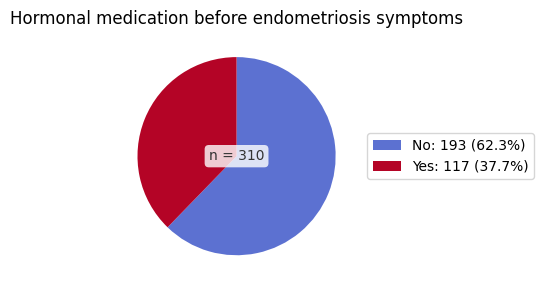

In [517]:
QUESTION_COL = "Did you ever take hormonal medication before the onset of your endometriosis symptoms?"

# Define categories: label + color
CATEGORIES = [
    ("No", "#5c71d1"),  # blue
    ("Yes", "#b40426")  # red
]

cat_order  = [label for label, _ in CATEGORIES]
map_dict   = {label: label for label, _ in CATEGORIES}  # identity map (normalize only to these)
pie_colors = dict(CATEGORIES)

# Plot
out = plot_single_question(
    df=Survey_endo_only,
    question_col=QUESTION_COL,
    multi_label=False,
    allowed_answers=cat_order,
    map_dict=map_dict,
    include_other=False,
    remove_values=("unsure", "none", "", np.nan),  # or remove_values=()
    sort_by=None,
    category_order=cat_order,
    chart="pie",
    fig_title="Hormonal medication before endometriosis symptoms",
    y_label=None,
    pie_colors=pie_colors,
    return_data=True,
    display=True
)

In [518]:
# Are you or have you ever taken any NSAID (Non Steroidal Anti-inflammatory Drugs) such as aspirin or ibuprofen for pain relief?

In [519]:
Survey_endo_only["Are you or have you ever taken any NSAID (Non Steroidal Anti-inflammatory Drugs) such as aspirin or ibuprofen for pain relief?"].apply(type).value_counts()

Are you or have you ever taken any NSAID (Non Steroidal Anti-inflammatory Drugs) such as aspirin or ibuprofen for pain relief?
<class 'str'>      309
<class 'float'>      1
Name: count, dtype: int64

In [520]:
Survey_endo_only["Are you or have you ever taken any NSAID (Non Steroidal Anti-inflammatory Drugs) such as aspirin or ibuprofen for pain relief?"].count()

309

In [521]:
Survey_endo_only["Are you or have you ever taken any NSAID (Non Steroidal Anti-inflammatory Drugs) such as aspirin or ibuprofen for pain relief?"].isna().sum()

1

In [522]:
# Check responses
common_items = (
    Survey_endo_only['Are you or have you ever taken any NSAID (Non Steroidal Anti-inflammatory Drugs) such as aspirin or ibuprofen for pain relief?']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 0].head(50))

Are you or have you ever taken any NSAID (Non Steroidal Anti-inflammatory Drugs) such as aspirin or ibuprofen for pain relief?
yes    287
no      22
Name: count, dtype: int64


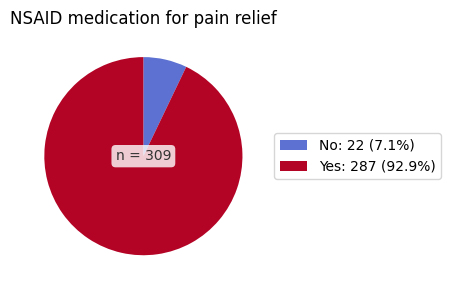

In [523]:
QUESTION_COL = "Are you or have you ever taken any NSAID (Non Steroidal Anti-inflammatory Drugs) such as aspirin or ibuprofen for pain relief?"

# Define category: label + color
CATEGORIES = [
    ("No", "#5c71d1"),  # blue
    ("Yes", "#b40426")  # red
]

cat_order  = [label for label, _ in CATEGORIES]
map_dict   = {label: label for label, _ in CATEGORIES}  # identity map (normalize only to these)
pie_colors = dict(CATEGORIES)

# Plot
out = plot_single_question(
    df=Survey_endo_only,
    question_col=QUESTION_COL,
    multi_label=False,
    allowed_answers=cat_order,
    map_dict=map_dict,
    include_other=False,
    remove_values=("unsure", "none", "", np.nan),  # or remove_values=()
    sort_by=None,
    category_order=cat_order,
    chart="pie",
    fig_title="NSAID medication for pain relief",
    y_label=None,
    pie_colors=pie_colors,
    return_data=True,
    display=True
)

In [524]:
# If yes please list below which medications if you can

In [525]:
# Check for any other itemas I may include 
common_items = (
    Survey_endo_only['If yes please list below which medications if you can']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 0].head(50))

If yes please list below which medications if you can
ibuprofen                                                                   111
ponstan                                                                      53
nurofen                                                                      31
difene                                                                       31
vimovo                                                                       30
naproxen                                                                     25
nurofen plus                                                                 16
paracetamol                                                                  16
neurofen                                                                     12
aspirin                                                                      11
mefac                                                                         8
tylex                                                             

In [526]:
# If yes, at what age did you begin taking these medications?

In [527]:
Survey_endo_only["If yes, at what age did you begin taking these medications?"].apply(type).value_counts()

If yes, at what age did you begin taking these medications?
<class 'int'>      199
<class 'str'>       74
<class 'float'>     37
Name: count, dtype: int64

In [528]:
Survey_endo_only["If yes, at what age did you begin taking these medications?"].count()

273

In [529]:
Survey_endo_only["If yes, at what age did you begin taking these medications?"].isna().sum()

37

In [530]:
# Check responses
common_items = (
    Survey_endo_only['If yes, at what age did you begin taking these medications?']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 1].head(50))

If yes, at what age did you begin taking these medications?
nan          199
20s           10
teens          6
teenager       3
14             2
unsure         2
early 20s      2
15/16          2
30s            2
13/14          2
Name: count, dtype: int64


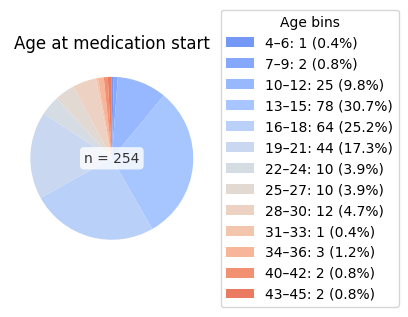

In [531]:
QUESTION_COL = "If yes, at what age did you begin taking these medications?"

bin_tuples = [(0, 3, "0–3")] + [(a, a+2, f"{a}–{a+2}") for a in range(4, 100, 3)]
cat_order_asc = [lab for (_, _, lab) in bin_tuples]

out_age_numeric = plot_single_question(
    df=Survey_endo_only,
    question_col=QUESTION_COL,
    numeric=True,
    number_pattern=r"\d+",
    number_extract="first",
    numeric_range=(1, 129),
    numeric_bins=bin_tuples,
    rescale_to_100=True,
    remove_values=(),
    sort_by=None,
    category_order=cat_order_asc,
    chart="pie",
    fig_title="Age at medication start",
    y_label="Age bins",
    pie_colors=PALETTE_0_48,
    pie_use_base_color=False,
    pie_cmap="coolwarm",
    pie_cmap_reverse=False,
    pie_distinct_subset=False,
    return_data=True,
    display=True
)

## Medical diagnosis - timings, knowledge and treatment

## Timing of diagnosis

In [534]:
# At what age were you diagnosed with endometriosis?

In [535]:
Survey_endo_only["At what age were you diagnosed with endometriosis?"].apply(type).value_counts()

At what age were you diagnosed with endometriosis?
<class 'int'>      294
<class 'str'>       12
<class 'float'>      4
Name: count, dtype: int64

In [536]:
Survey_endo_only["At what age were you diagnosed with endometriosis?"].count()

306

In [537]:
Survey_endo_only["At what age were you diagnosed with endometriosis?"].isna().sum()

4

In [538]:
# Check responses
common_items = (
    Survey_endo_only['If yes, at what age did you begin taking these medications?']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 1].head(50))

If yes, at what age did you begin taking these medications?
nan          199
20s           10
teens          6
teenager       3
14             2
unsure         2
early 20s      2
15/16          2
30s            2
13/14          2
Name: count, dtype: int64


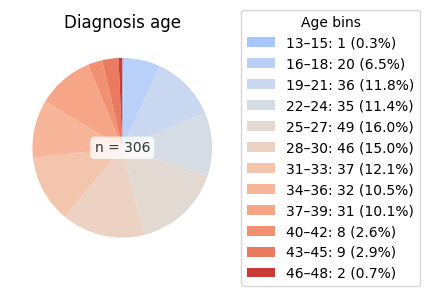

In [539]:
QUESTION_COL = "At what age were you diagnosed with endometriosis?"

bin_tuples = [(0, 3, "0–3")] + [(a, a+2, f"{a}–{a+2}") for a in range(4, 100, 3)]
cat_order_asc = [lab for (_, _, lab) in bin_tuples]

out_age_numeric = plot_single_question(
    df=Survey_endo_only,
    question_col=QUESTION_COL,
    numeric=True,
    number_pattern=r"\d+",
    number_extract="first",
    numeric_range=(1, 129),
    numeric_bins=bin_tuples,
    rescale_to_100=True,
    remove_values=(),
    sort_by=None,
    category_order=cat_order_asc,
    chart="pie",
    fig_title="Diagnosis age",
    y_label="Age bins",
    pie_colors=PALETTE_0_48,
    pie_use_base_color=False,
    pie_cmap="coolwarm",
    pie_cmap_reverse=False,
    pie_distinct_subset=False,
    return_data=True,
    display=True
)

In [540]:
# How long did it take to get a diagnosis from the first time you went to the doctors with symptoms? 

In [541]:
Survey_endo_only["How long did it take to get a diagnosis from the first time you went to the doctors with symptoms? "].apply(type).value_counts()

How long did it take to get a diagnosis from the first time you went to the doctors with symptoms? 
<class 'str'>      309
<class 'float'>      1
Name: count, dtype: int64

In [542]:
Survey_endo_only["How long did it take to get a diagnosis from the first time you went to the doctors with symptoms? "].count()

309

In [543]:
Survey_endo_only["How long did it take to get a diagnosis from the first time you went to the doctors with symptoms? "].isna().sum()

1

In [544]:
# Check responses
common_items = (
    Survey_endo_only['How long did it take to get a diagnosis from the first time you went to the doctors with symptoms? ']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 0].head(50))

How long did it take to get a diagnosis from the first time you went to the doctors with symptoms? 
11+ years                                  101
9-10 years                                  47
7-8 years                                   44
3-4 years                                   36
5-6 years                                   32
1-2 years                                   28
less than 1 year                            20
still waiting for an official diagnosis      1
Name: count, dtype: int64


In [545]:
# 'still waiting for an official diagnosis' should not be here because these are confirmed cases and manually checked this was confirmed by laparoscopy, so the response is invalid and we dont know when the lap was done- do not include below

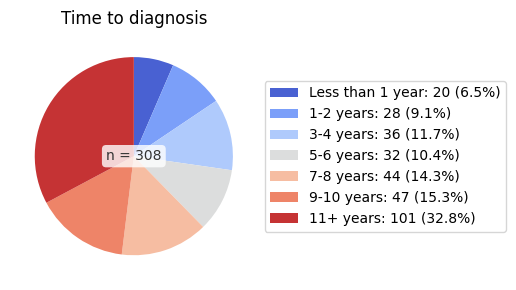

In [546]:
QUESTION_COL = "How long did it take to get a diagnosis from the first time you went to the doctors with symptoms? "

# Define allowed categories 
cat_order = [
    "Less than 1 year",
    "1-2 years",
    "3-4 years",
    "5-6 years",
    "7-8 years",
    "9-10 years",
    "11+ years",
]

map_dict = {c: c for c in cat_order}


# Plot
out = plot_single_question(
    df=Survey_endo_only,
    question_col=QUESTION_COL,
    multi_label=False,
    allowed_answers=cat_order,
    map_dict=map_dict,
    category_order=cat_order,
    include_other=False,
    chart="pie",
    fig_title="Time to diagnosis",
    y_label=None,
    pie_cmap="coolwarm",
    pie_cmap_reverse=False,
    return_data=True,
    display=True
)

## Medical knowledge about endometriosis

In [548]:
# Did you attend an endometriosis specialist or clinic to receive your diagnosis, if so which one?

In [549]:
# Check for any other items I may include 
common_items = (
    Survey_endo_only['Did you attend an endometriosis specialist or clinic to receive your diagnosis, if so which one?']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 1].head(50))

Did you attend an endometriosis specialist or clinic to receive your diagnosis, if so which one?
no                       37
yes                      19
rotunda                   8
the coombe                4
beacon hospital           4
rotunda hospital          3
rotunda private           3
blackrock clinic          2
canada                    2
dr katie field            2
coombe hospital           2
gynae                     2
mr waseem kamran          2
beacon women’s centre     2
connolly hospital         2
no.                       2
holles street             2
beacon                    2
clinic                    2
gynecologist              2
Name: count, dtype: int64


In [550]:
# Did you feel supported by your medical practitioner(s) through the course of your diagnosis?

In [551]:
Survey_endo_only["Did you feel supported by your medical practitioner(s) through the course of your diagnosis?"].apply(type).value_counts()

Did you feel supported by your medical practitioner(s) through the course of your diagnosis?
<class 'float'>    310
Name: count, dtype: int64

In [552]:
Survey_endo_only["Did you feel supported by your medical practitioner(s) through the course of your diagnosis?"].count()

309

In [553]:
Survey_endo_only["Did you feel supported by your medical practitioner(s) through the course of your diagnosis?"].isna().sum()

1

In [554]:
Survey_endo_only["Did you feel supported by your medical practitioner(s) through the course of your diagnosis?"].head()

0    1.0
1    3.0
2    3.0
3    2.0
4    4.0
Name: Did you feel supported by your medical practitioner(s) through the course of your diagnosis?, dtype: float64

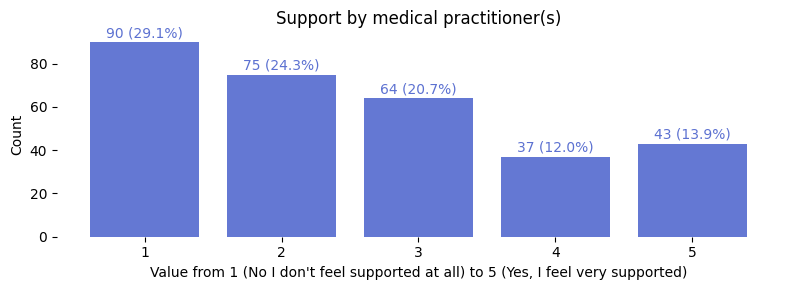

In [555]:
QUESTION_COL = "Did you feel supported by your medical practitioner(s) through the course of your diagnosis?"

# Define categories and order
cat_order = ["1", "2", "3", "4", "5"]
map_dict  = {
    1.0: "1", 2.0: "2", 3.0: "3", 4.0: "4", 5.0: "5",
    1: "1", 2: "2", 3: "3", 4: "4", 5: "5",   # (covers ints too, just in case)
    "1": "1", "2": "2", "3": "3", "4": "4", "5": "5",
}

# Plot
out = plot_single_question(
    df=Survey_endo_only,
    question_col=QUESTION_COL,
    multi_label=False,
    allowed_answers=cat_order,
    map_dict=map_dict,
    category_order=cat_order,
    include_other=False,
    remove_values=("unsure", "maybe", "none", "", np.nan, None),
    numeric=False,
    chart="barv",
    rescale_to_100=False,
    axis_label="Count",
    y_label="Value from 1 (No I don't feel supported at all) to 5 (Yes, I feel very supported)",
    fig_title="Support by medical practitioner(s)",
    return_data=True,
    display=True,
    figsize=(8,3),
)

In [556]:
# Did you feel like your complaints were listened to or did you have to push for a diagnosis?

In [557]:
Survey_endo_only["Did you feel like your complaints were listened to or did you have to push for a diagnosis?"].apply(type).value_counts()

Did you feel like your complaints were listened to or did you have to push for a diagnosis?
<class 'float'>    310
Name: count, dtype: int64

In [558]:
Survey_endo_only["Did you feel like your complaints were listened to or did you have to push for a diagnosis?"].count()

310

In [559]:
Survey_endo_only["Did you feel like your complaints were listened to or did you have to push for a diagnosis?"].isna().sum()

0

In [560]:
Survey_endo_only["Did you feel like your complaints were listened to or did you have to push for a diagnosis?"].head()

0    2.0
1    5.0
2    1.0
3    1.0
4    2.0
Name: Did you feel like your complaints were listened to or did you have to push for a diagnosis?, dtype: float64

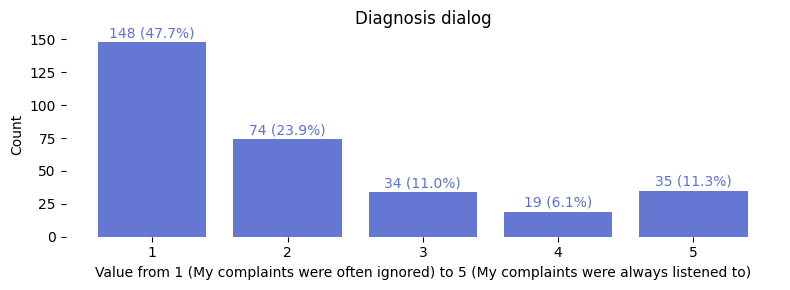

In [561]:
QUESTION_COL = "Did you feel like your complaints were listened to or did you have to push for a diagnosis?"

# Extract numeric value (1–5) 
def extract_value(value):
    if pd.isna(value):
        return None
    m = re.search(r'\d+', str(value))
    if m:
        return int(m.group())
    return None

# Apply to dataframe
Survey_endo_only[QUESTION_COL] = Survey_endo_only[QUESTION_COL].apply(extract_value)

# Define category order 
cat_order = ["1", "2", "3", "4", "5"]

# Mapping: convert int → str for the plotting function
map_dict = {i: str(i) for i in range(1, 6)}

# Plot 
out = plot_single_question(
    df=Survey_endo_only,
    question_col=QUESTION_COL,
    multi_label=False,
    allowed_answers=cat_order,
    map_dict=map_dict,
    category_order=cat_order,
    include_other=False,
    numeric=False,                # use categorical (explicit answers)
    chart="barv",                 
    rescale_to_100=False,                # <<< use COUNTS 
    axis_label="Count",
    fig_title="Diagnosis dialog",
    y_label="Value from 1 (My complaints were often ignored) to 5 (My complaints were always listened to)",
    return_data=True,
    display=True,
    figsize=(8,3),
)

In [562]:
# Do you feel endometriosis is understood by your doctors?

In [563]:
Survey_endo_only["Do you feel endometriosis is understood by your doctors?"].apply(type).value_counts()

Do you feel endometriosis is understood by your doctors?
<class 'float'>    310
Name: count, dtype: int64

In [564]:
Survey_endo_only["Do you feel endometriosis is understood by your doctors?"].count()

309

In [565]:
Survey_endo_only["Do you feel endometriosis is understood by your doctors?"].isna().sum()

1

In [566]:
Survey_endo_only["Do you feel endometriosis is understood by your doctors?"].head()

0    1.0
1    3.0
2    3.0
3    1.0
4    3.0
Name: Do you feel endometriosis is understood by your doctors?, dtype: float64

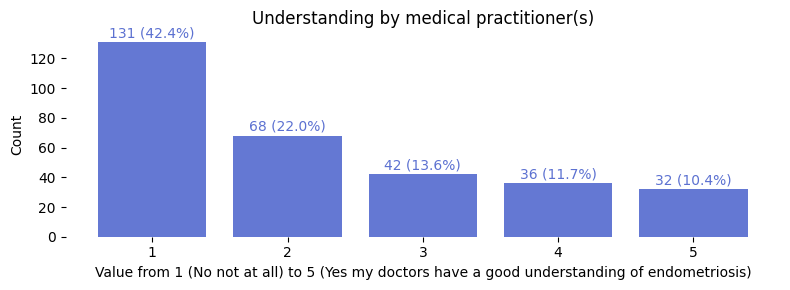

In [567]:
QUESTION_COL = "Do you feel endometriosis is understood by your doctors?"

# Define categories
cat_order = ["1", "2", "3", "4", "5"]
map_dict  = {
    1.0: "1", 2.0: "2", 3.0: "3", 4.0: "4", 5.0: "5",
    1: "1", 2: "2", 3: "3", 4: "4", 5: "5",   # (covers ints too, just in case)
    "1": "1", "2": "2", "3": "3", "4": "4", "5": "5",
}

# Plot
out = plot_single_question(
    df=Survey_endo_only,
    question_col=QUESTION_COL,
    multi_label=False,
    allowed_answers=cat_order,
    map_dict=map_dict,
    category_order=cat_order,
    include_other=False,
    remove_values=("unsure", "maybe", "none", "", np.nan, None),
    numeric=False,
    chart="barv",
    rescale_to_100=False,
    axis_label="Count",
    y_label="Value from 1 (No not at all) to 5 (Yes my doctors have a good understanding of endometriosis)",
    fig_title="Understanding by medical practitioner(s)",
    return_data=True,
    display=True,
    figsize=(8,3),
)

In [568]:
# Do you feel there is a good enough awareness among medical professionals around endometriosis?

In [569]:
Survey_endo_only["Do you feel there is a good enough awareness among medical professionals around endometriosis?"].apply(type).value_counts()

Do you feel there is a good enough awareness among medical professionals around endometriosis?
<class 'int'>    310
Name: count, dtype: int64

In [570]:
Survey_endo_only["Do you feel there is a good enough awareness among medical professionals around endometriosis?"].count()

310

In [571]:
Survey_endo_only["Do you feel there is a good enough awareness among medical professionals around endometriosis?"].isna().sum()

0

In [572]:
Survey_endo_only["Do you feel there is a good enough awareness among medical professionals around endometriosis?"].head()

0    1
1    4
2    1
3    1
4    1
Name: Do you feel there is a good enough awareness among medical professionals around endometriosis?, dtype: int64

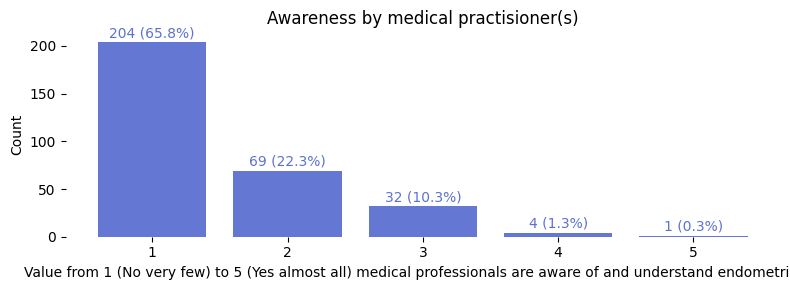

In [573]:
QUESTION_COL = "Do you feel there is a good enough awareness among medical professionals around endometriosis?"

# Extract numeric value 
def extract_value(value):
    if pd.isna(value):
        return None
    m = re.search(r'\d+', str(value))
    if m:
        return int(m.group())
    return None

# Apply to dataframe
Survey_endo_only[QUESTION_COL] = Survey_endo_only[QUESTION_COL].apply(extract_value)

# Define category order 
cat_order = ["1", "2", "3", "4", "5"]

# Mapping: convert int → str for the plotting function
map_dict = {i: str(i) for i in range(1, 6)}

# Plot 
out = plot_single_question(
    df=Survey_endo_only,
    question_col=QUESTION_COL,
    multi_label=False,
    allowed_answers=cat_order,
    map_dict=map_dict,
    category_order=cat_order,
    include_other=False,
    numeric=False,                # use categorical (explicit answers)
    chart="barv",                 
    rescale_to_100=False,                # <<< use COUNTS 
    axis_label="Count",
    fig_title="Awareness by medical practisioner(s)",
    y_label="Value from 1 (No very few) to 5 (Yes almost all) medical professionals are aware of and understand endometriosis)",
    return_data=True,
    display=True,
    figsize=(8,3), 
)

## Treatment

In [575]:
# What measures have you taken to improve your symptoms that you have found to be effective? (diet, hormonal medications, some alternative medicine approaches, etc.)
# this may need manual input

In [576]:
# Check for any other items I may include 
common_items = (
    Survey_endo_only['What measures have you taken to improve your symptoms that you have found to be effective? (diet, hormonal medications, some alternative medicine approaches, etc.)']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 1].head(50))

What measures have you taken to improve your symptoms that you have found to be effective? (diet, hormonal medications, some alternative medicine approaches, etc.)
diet                      70
acupuncture               27
exercise                  24
mirena coil                8
supplements                7
contraceptive pill         6
alcohol                    6
rest                       6
yoga                       5
pain relief                5
heat                       5
surgery                    5
coil                       4
gentle exercise            4
anti inflammatory diet     4
physio                     4
tens machine               4
hormonal medications       4
stress reduction           3
kinesiology                3
hot water bottles          3
painkillers                3
magnesium                  3
sugar                      3
stress                     3
sleep                      3
probiotics                 3
walking                    3
hormonal medication     

In [577]:
# What measures, recommended by doctors or others, have you tried that have negatively affected your symptoms?

In [578]:
# Check for any other itemas I may include 
common_items = (
    Survey_endo_only['What measures, recommended by doctors or others, have you tried that have negatively affected your symptoms?']
    .fillna('')
    .str.split(r'[;,]| and ', expand=False)
    .explode()
    .astype(str)
    .str.strip()
    .str.lower()
    .pipe(lambda s: s[s.str.len() > 0])
    .value_counts()
)

print(common_items[common_items > 1].head(50))

What measures, recommended by doctors or others, have you tried that have negatively affected your symptoms?
the pill                                14
the coil                                 6
mirena coil                              6
hormones                                 5
contraceptive pill                       4
medical menopause                        4
pill                                     3
none                                     3
exercise                                 3
diet                                     3
txa                                      2
progesterone                             2
cerazette                                2
acupuncture                              2
cbt                                      2
hormonal treatments                      2
difene                                   2
combined pill                            2
ivf                                      2
hormone therapy                          2
coil                           

## Correlation of age at symptom and at diagnosis

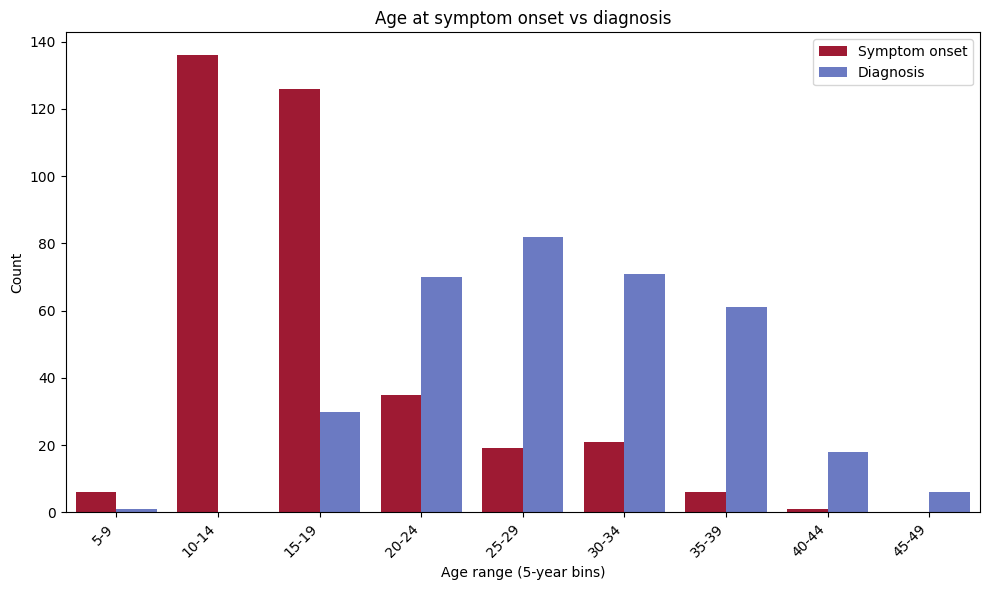

In [580]:
# use the same bins as other ages
# At what age roughly did you notice your symptoms begin?
# At what age were you diagnosed with endometriosis?

SYMPTOM_COL = "At what age roughly did you notice your symptoms begin?"
DIAGNOSIS_COL = "At what age were you diagnosed with endometriosis?"

# Extract FIRST number only
number_pattern = r"\d+"

def extract_first_number(series):
    return series.apply(
        lambda x: float(re.search(number_pattern, str(x)).group())
        if pd.notna(x) and re.search(number_pattern, str(x))
        else np.nan
    )

# Clean age values
age_symptom = extract_first_number(Survey[SYMPTOM_COL])
age_diagnosis = extract_first_number(Survey[DIAGNOSIS_COL])

age_symptom = age_symptom[(age_symptom > 0) & (age_symptom < 130)]
age_diagnosis = age_diagnosis[(age_diagnosis > 0) & (age_diagnosis < 130)]

if age_symptom.empty and age_diagnosis.empty:
    raise ValueError("No valid ages found after cleaning.")

# Build SHARED 5‑year age bins
combined_ages = pd.concat([age_symptom, age_diagnosis])

min_age = int(np.floor(combined_ages.min()))
max_age = int(np.floor(combined_ages.max()))

start_bin = (min_age // 5) * 5
end_bin = ((max_age + 4) // 5) * 5
if end_bin <= start_bin:
    end_bin = start_bin + 5

bins = list(range(start_bin, end_bin + 5, 5))
labels = [f"{bins[i]}-{bins[i+1]-1}" for i in range(len(bins) - 1)]

# Assign age groups
df_symptom = pd.DataFrame({
    "Age group": pd.cut(
        age_symptom,
        bins=bins,
        right=False,
        labels=labels,
        include_lowest=True
    ).astype(str),
    "Question": "Symptom onset"
})

df_diagnosis = pd.DataFrame({
    "Age group": pd.cut(
        age_diagnosis,
        bins=bins,
        right=False,
        labels=labels,
        include_lowest=True
    ).astype(str),
    "Question": "Diagnosis"
})

age_long = pd.concat([df_symptom, df_diagnosis], ignore_index=True)

# Count per age bin and question
count_df = (
    age_long
    .value_counts(["Age group", "Question"])
    .rename("Count")
    .reset_index()
)

# Ensure full bin order
count_df["Age group"] = pd.Categorical(
    count_df["Age group"],
    categories=labels,
    ordered=True
)

# Plot: VERTICAL grouped bar chart
plt.figure(figsize=(10, 6))


palette = {
    "Symptom onset": "#b40426",   # red
    "Diagnosis": "#5c71d1"        # blue
}

sns.barplot(
    data=count_df,
    x="Age group",
    y="Count",
    hue="Question",
    palette=palette,
    orient="v"
)

plt.ylabel("Count")
plt.xlabel("Age range (5-year bins)")
plt.title("Age at symptom onset vs diagnosis")

plt.xticks(rotation=45, ha="right")   # improve label readability
plt.legend(title="")

plt.tight_layout()
plt.show()